In [1]:
# %load_ext autoreload
# %autoreload 2
%time

CPU times: user 2 µs, sys: 1 µs, total: 3 µs
Wall time: 4.05 µs


In [2]:
import sys, os
sys.path.append("../../")  # if needed
import pandas as pd
import data_loading as dl
import numpy as np
import matplotlib.pyplot as plt
from numu_tki.cc0pi_analyzer import apply_ccnp0pi_stv
from cc0pi_cached import load_runs_with_cc0pi_bdt


In [3]:
RUN = ["1"]
blinded = True

rundata, mc_weights, data_pot = load_runs_with_cc0pi_bdt(
    ["1"],
    model_path="/exp/uboone/app/users/rlalnunt/PELEE_BDT/cc0pi_fstrack_pid_softprob.json",
    data="bnb",
    loadshowervariables=False,
    loadnumuvariables=True,
    load_numu_tki=False,
    loadpi0variables=False,
    loadrecoveryvars=False,
    loadsystematics=True,
    blinded=True,
    enable_cache=True,   # turns on the HDF cache
    overwrite=False,      # don’t overwrite cached result
    use_bdt=False
)

Loading run 1
Running the CC0pi-BDT....


In [4]:
mc = rundata["mc"]
#print(mc)
print("mc_is_cc1p0pi_signal" in rundata["mc"].columns)
#print(mc["mc_num_protons"].values)
print(len(mc["mc_is_cc0pi_signal"]))


True
1020773


In [5]:
print("sel_CC1p0pi" in rundata["mc"].columns)

True


### Selection Stats

In [8]:
from microfit import selections as sel
import numpy as np

preselection = "sel_CCNp0pi"
selection    = "sel_CC1p0pi"

pre_q  = sel.preselection_categories[preselection]["query"]
sel_q  = sel.selection_categories[selection]["query"]

# sel_CC1p0pi already includes sel_CCNp0pi
reco_q = sel_q

def wsum(df):
    return df["weights"].sum()

truth_defs = {
    "mc_is_signal":            "mc_is_signal == True",
    "mc_is_cc1p0pi_signal":    "mc_is_cc1p0pi_signal == True",
    "mc_is_cc0pi_wc_signal":   "mc_is_cc0pi_wc_signal == True",
}

N_tot = wsum(mc)
print(f"Total MC (all): {N_tot:.3f}\n")

for label, signal_query in truth_defs.items():
    if label not in mc.columns:
        continue

    sig_all   = mc.query(signal_query, engine="python")
    sel_all   = mc.query(reco_q,      engine="python")
    sel_sig   = mc.query(f"{signal_query} and {reco_q}", engine="python")

    N_sig_all = wsum(sig_all)
    N_sel_all = wsum(sel_all)
    N_sel_sig = wsum(sel_sig)

    eff  = N_sel_sig / N_sig_all if N_sig_all > 0 else np.nan
    pur  = N_sel_sig / N_sel_all if N_sel_all > 0 else np.nan
    rate = N_sel_all / N_tot      if N_tot    > 0 else np.nan

    print(f"=== Truth flag: {label} ===")
    print(f"  Truth signal (no reco cuts):    {N_sig_all:.3f}")
    print(f"  Reco selected:                  {N_sel_all:.3f}")
    print(f"  Selected signal:                {N_sel_sig:.3f}")
    print(f"  Efficiency:                     {eff*100:.2f} %")
    print(f"  Purity:                         {pur*100:.2f} %")
    print(f"  Rate vs all MC:                 {rate*100:.2f} %\n")


Total MC (all): 150147.136

=== Truth flag: mc_is_signal ===
  Truth signal (no reco cuts):    17483.929
  Reco selected:                  2111.524
  Selected signal:                1544.104
  Efficiency:                     8.83 %
  Purity:                         73.13 %
  Rate vs all MC:                 1.41 %

=== Truth flag: mc_is_cc1p0pi_signal ===
  Truth signal (no reco cuts):    11802.345
  Reco selected:                  2111.524
  Selected signal:                1275.208
  Efficiency:                     10.80 %
  Purity:                         60.39 %
  Rate vs all MC:                 1.41 %

=== Truth flag: mc_is_cc0pi_wc_signal ===
  Truth signal (no reco cuts):    22584.109
  Reco selected:                  2111.524
  Selected signal:                1660.110
  Efficiency:                     7.35 %
  Purity:                         78.62 %
  Rate vs all MC:                 1.41 %



In [9]:
cuts = [
    ("presel", "sel_presel"),
    ("has_mu", "sel_has_muon_candidate"),
    ("mu_cont", "sel_muon_contained"),
    ("mu_mom", "sel_muon_passed_mom_cuts"),
    ("mu_qual", "sel_muon_quality_ok"),
    ("has_p", "sel_has_p_candidate"),
    ("leadp_mom", "sel_lead_p_passed_mom_cuts"),
    ("CCNp0pi", "sel_CCNp0pi"),
    ("CC1p0pi", "sel_CC1p0pi"),
]

df = mc.copy()
w0 = df["weights"].sum()

for name, q in cuts:
    df = df.query(q, engine="python")
    w = df["weights"].sum()
    print(name, w, w/w0)


presel 16822.760949313444 0.11204183705763514
has_mu 14878.086359856174 0.09909004429670981
mu_cont 6657.578356938533 0.04434036194855325
mu_mom 6133.180632162292 0.04084780299168523
mu_qual 4700.188070820282 0.0313038809478285
has_p 2941.2940907330308 0.019589411883424793
leadp_mom 2941.2940907330308 0.019589411883424793
CCNp0pi 2941.2940907330308 0.019589411883424793
CC1p0pi 2111.5238326986128 0.01406303102798273


### Scan over delta_pT

In [10]:
cuts = np.linspace(0.0, 2.0, 40)  

base_reco_q = f"({pre_q}) and ({sel_q})"
N_tot = wsum(mc)

truth_label = "mc_is_cc1p0pi_signal"
truth_q     = truth_defs[truth_label]

sig_all = mc.query(truth_q, engine="python")
N_sig_all = wsum(sig_all)

results = []

for dpT_max in cuts:
    dpT_cut_q = f"(delta_pT < {dpT_max})"
    reco_q = f"({base_reco_q}) and ({dpT_cut_q})"

    sel_all = mc.query(reco_q, engine="python")
    sel_sig = mc.query(f"{truth_q} and {reco_q}", engine="python")

    N_sel_all = wsum(sel_all)
    N_sel_sig = wsum(sel_sig)

    eff  = N_sel_sig / N_sig_all if N_sig_all > 0 else np.nan
    pur  = N_sel_sig / N_sel_all if N_sel_all > 0 else np.nan
    rate = N_sel_all / N_tot      if N_tot    > 0 else np.nan

    results.append({
        "delta_pT_max": dpT_max,
        "N_sel_all": N_sel_all,
        "N_sel_sig": N_sel_sig,
        "eff": eff*100.0,
        "pur": pur*100.0,
        "rate": rate*100.0,
    })

import pandas as pd
res_df = pd.DataFrame(results)
print(res_df)


    delta_pT_max    N_sel_all    N_sel_sig        eff        pur      rate
0       0.000000     0.000000     0.000000   0.000000        NaN  0.000000
1       0.051282   112.328148    93.373401   0.791143  83.125559  0.074812
2       0.102564   363.782921   289.836419   2.455753  79.672904  0.242284
3       0.153846   682.819381   527.982415   4.473538  77.323876  0.454767
4       0.205128   982.358766   731.260619   6.195893  74.439262  0.654264
5       0.256410  1227.966474   876.353585   7.425250  71.366247  0.817842
6       0.307692  1408.422002   962.948294   8.158957  68.370722  0.938028
7       0.358974  1569.688827  1038.441050   8.798599  66.155854  1.045434
8       0.410256  1710.978106  1103.911411   9.353323  64.519318  1.139534
9       0.461538  1831.591854  1160.803769   9.835365  63.376771  1.219865
10      0.512821  1919.898464  1200.033552  10.167755  62.505053  1.278678
11      0.564103  1981.914313  1226.262386  10.389989  61.872624  1.319981
12      0.615385  2026.19

In [11]:
import numpy as np
import pandas as pd

cuts = np.linspace(0.0, 2.0, 20)
base_reco_q = f"({pre_q}) and ({sel_q})"

truth_label = "mc_is_cc1p0pi_signal"
truth_q     = truth_defs[truth_label]

N_tot     = wsum(mc)
sig_all   = mc.query(truth_q, engine="python")
N_sig_all = wsum(sig_all)

# --- fixed Ecal binning (constant for all scans) ---
ecal_edges = np.linspace(0.0, 2.0, 21)   # example: 0–2 GeV in 0.1 bins
ecal_centers = 0.5 * (ecal_edges[:-1] + ecal_edges[1:])

rows_global = []
ecal_hists_all = {}   # Ecal histogram for all selected (signal+bg) per cut
ecal_hists_sig = {}   # Ecal histogram for selected *true signal* per cut

for dpT_max in cuts:
    dpT_cut_q = f"(delta_pT < {dpT_max})"
    reco_q    = f"({base_reco_q}) and ({dpT_cut_q})"

    sel_all = mc.query(reco_q, engine="python")
    sel_sig = mc.query(f"{truth_q} and {reco_q}", engine="python")

    N_sel_all = wsum(sel_all)
    N_sel_sig = wsum(sel_sig)

    eff  = N_sel_sig / N_sig_all if N_sig_all > 0 else np.nan
    pur  = N_sel_sig / N_sel_all if N_sel_all > 0 else np.nan
    rate = N_sel_all / N_tot      if N_tot    > 0 else np.nan

    rows_global.append({
        "delta_pT_max": dpT_max,
        "N_sel_all": N_sel_all,
        "N_sel_sig": N_sel_sig,
        "eff_%": eff*100.0,
        "pur_%": pur*100.0,
        "rate_%": rate*100.0,
    })

    # --- Ecal histograms for this dpT cut (1μ1p selection applied) ---
    # all selected events (signal + background)
    hist_all, _ = np.histogram(sel_all["Ecal"], bins=ecal_edges,
                               weights=sel_all["weights"])
    # only selected *true* 1μ1p signal
    hist_sig, _ = np.histogram(sel_sig["Ecal"], bins=ecal_edges,
                               weights=sel_sig["weights"])

    ecal_hists_all[dpT_max] = hist_all
    ecal_hists_sig[dpT_max] = hist_sig

global_df = pd.DataFrame(rows_global)
print(global_df)


    delta_pT_max    N_sel_all    N_sel_sig      eff_%      pur_%    rate_%
0       0.000000     0.000000     0.000000   0.000000        NaN  0.000000
1       0.105263   378.455490   301.554352   2.555038  79.680269  0.252056
2       0.210526  1014.009015   751.770081   6.369667  74.138402  0.675344
3       0.315789  1437.528204   978.988202   8.294862  68.102191  0.957413
4       0.421053  1738.683753  1115.215702   9.449103  64.141377  1.157987
5       0.526316  1937.816159  1208.902123  10.242898  62.384768  1.290611
6       0.631579  2037.871106  1250.401225  10.594515  61.358210  1.357249
7       0.736842  2089.738337  1266.966276  10.734869  60.627986  1.391794
8       0.842105  2103.338549  1271.359799  10.772095  60.444849  1.400852
9       0.947368  2109.356620  1274.532135  10.798974  60.422791  1.404860
10      1.052632  2110.904912  1274.873590  10.801867  60.394648  1.405891
11      1.157895  2111.035098  1274.873590  10.801867  60.390923  1.405978
12      1.263158  2111.21

In [12]:
from microfit import selections as sel
import numpy as np
import pandas as pd

preselection = "sel_CCNp0pi"
selection    = "sel_CC1p0pi"

pre_q  = sel.preselection_categories[preselection]["query"]   # "sel_CCNp0pi"
sel_q  = sel.selection_categories[selection]["query"]         # "sel_CC1p0pi"
base_reco_q = f"({pre_q}) and ({sel_q})"

def wsum(df):
    return df["weights"].sum()

truth_label = "mc_is_cc1p0pi_signal"
truth_defs = {
    "mc_is_cc1p0pi_signal": "mc_is_cc1p0pi_signal == True",
    # others...
}
truth_q = truth_defs[truth_label]

N_tot     = wsum(mc)
sig_all   = mc.query(truth_q, engine="python")
N_sig_all = wsum(sig_all)


In [13]:
def scan_1d_cut(mc, base_reco_q, truth_q, var_name, cut_values):
    N_tot     = wsum(mc)
    sig_all   = mc.query(truth_q, engine="python")
    N_sig_all = wsum(sig_all)

    rows = []
    for cut_val in cut_values:
        var_cut_q = f"({var_name} < {cut_val})"
        reco_q    = f"({base_reco_q}) and ({var_cut_q})"

        sel_all = mc.query(reco_q, engine="python")
        sel_sig = mc.query(f"{truth_q} and {reco_q}", engine="python")

        N_sel_all = wsum(sel_all)
        N_sel_sig = wsum(sel_sig)

        eff  = N_sel_sig / N_sig_all if N_sig_all > 0 else np.nan
        pur  = N_sel_sig / N_sel_all if N_sel_all > 0 else np.nan
        rate = N_sel_all / N_tot      if N_tot    > 0 else np.nan

        rows.append({
            "cut_var": var_name,
            "cut_max": cut_val,
            "N_sel_all": N_sel_all,
            "N_sel_sig": N_sel_sig,
            "eff_%": eff*100.0,
            "pur_%": pur*100.0,
            "rate_%": rate*100.0,
        })
    return pd.DataFrame(rows)


In [14]:
dpT_cuts = np.linspace(0.0, 2.0, 20)
pn_cuts  = np.linspace(0.0, 1.5, 20)   # adjust range as you like

dpT_scan_df = scan_1d_cut(mc, base_reco_q, truth_q, "delta_pT", dpT_cuts)
pn_scan_df  = scan_1d_cut(mc, base_reco_q, truth_q, "pn",       pn_cuts)

print(dpT_scan_df)
print(pn_scan_df)


     cut_var   cut_max    N_sel_all    N_sel_sig      eff_%      pur_%  \
0   delta_pT  0.000000     0.000000     0.000000   0.000000        NaN   
1   delta_pT  0.105263   378.455490   301.554352   2.555038  79.680269   
2   delta_pT  0.210526  1014.009015   751.770081   6.369667  74.138402   
3   delta_pT  0.315789  1437.528204   978.988202   8.294862  68.102191   
4   delta_pT  0.421053  1738.683753  1115.215702   9.449103  64.141377   
5   delta_pT  0.526316  1937.816159  1208.902123  10.242898  62.384768   
6   delta_pT  0.631579  2037.871106  1250.401225  10.594515  61.358210   
7   delta_pT  0.736842  2089.738337  1266.966276  10.734869  60.627986   
8   delta_pT  0.842105  2103.338549  1271.359799  10.772095  60.444849   
9   delta_pT  0.947368  2109.356620  1274.532135  10.798974  60.422791   
10  delta_pT  1.052632  2110.904912  1274.873590  10.801867  60.394648   
11  delta_pT  1.157895  2111.035098  1274.873590  10.801867  60.390923   
12  delta_pT  1.263158  2111.211537  1

In [15]:
dpT_cuts = np.linspace(0.0, 2.0, 10)   # fewer points first, then refine
pn_cuts  = np.linspace(0.0, 1.5, 10)

N_tot     = wsum(mc)
sig_all   = mc.query(truth_q, engine="python")
N_sig_all = wsum(sig_all)

rows_2d = []

for dpT_max in dpT_cuts:
    for pn_max in pn_cuts:
        dpT_cut_q = f"(delta_pT < {dpT_max})"
        pn_cut_q  = f"(pn < {pn_max})"
        reco_q    = f"({base_reco_q}) and ({dpT_cut_q}) and ({pn_cut_q})"

        sel_all = mc.query(reco_q, engine="python")
        sel_sig = mc.query(f"{truth_q} and {reco_q}", engine="python")

        N_sel_all = wsum(sel_all)
        N_sel_sig = wsum(sel_sig)

        eff  = N_sel_sig / N_sig_all if N_sig_all > 0 else np.nan
        pur  = N_sel_sig / N_sel_all if N_sel_all > 0 else np.nan
        rate = N_sel_all / N_tot      if N_tot    > 0 else np.nan

        rows_2d.append({
            "delta_pT_max": dpT_max,
            "pn_max": pn_max,
            "N_sel_all": N_sel_all,
            "N_sel_sig": N_sel_sig,
            "eff_%": eff*100.0,
            "pur_%": pur*100.0,
            "rate_%": rate*100.0,
        })

scan_2d_df = pd.DataFrame(rows_2d)
print(scan_2d_df.head())


   delta_pT_max    pn_max  N_sel_all  N_sel_sig  eff_%  pur_%  rate_%
0           0.0  0.000000        0.0        0.0    0.0    NaN     0.0
1           0.0  0.166667        0.0        0.0    0.0    NaN     0.0
2           0.0  0.333333        0.0        0.0    0.0    NaN     0.0
3           0.0  0.500000        0.0        0.0    0.0    NaN     0.0
4           0.0  0.666667        0.0        0.0    0.0    NaN     0.0


In [16]:
best_pur = scan_2d_df.loc[scan_2d_df["eff_%"].idxmax()]
print("Best purity point:")
print(best_pur)


Best purity point:
delta_pT_max       1.333333
pn_max             1.500000
N_sel_all       2110.359625
N_sel_sig       1274.864601
eff_%             10.801791
pur_%             60.409827
rate_%             1.405528
Name: 69, dtype: float64


In [17]:
sel_mc_1mu1p = mc[mc['sel_CC1p0pi'] == True ] # Truth-Level Study
pre_mc_1mu1p = mc[mc['sel_CCNp0pi'] == True ]

In [18]:
selection    = sel_mc_1mu1p 
preselection = pre_mc_1mu1p 

13182


/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  del sys.path[0]
/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usin

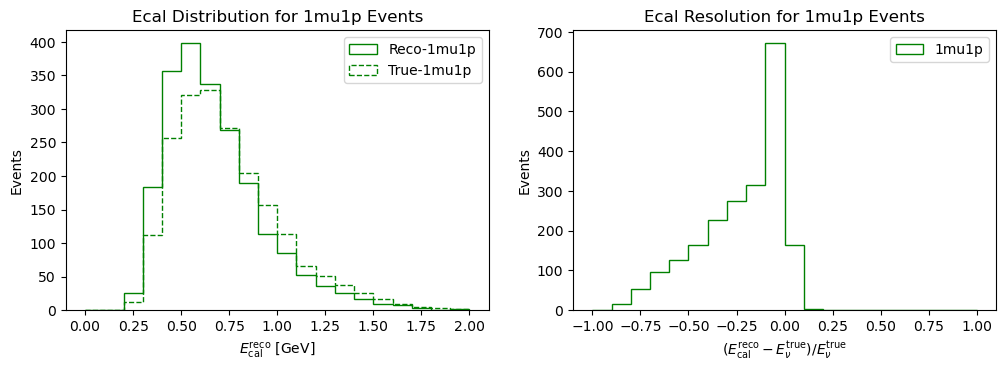

In [20]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)

# Compute reco neutrino energy via Ecal method
reco_ecal_energy   = sel_mc_1mu1p["Ecal"].values
true_ecal_energy   = sel_mc_1mu1p["mc_Ecal"].values
true_nu_energy     = sel_mc_1mu1p["nu_e"].values
# Compute Ecal resolution
ecal_resolution_1mu1p = (reco_ecal_energy - true_nu_energy) / true_nu_energy
print(len(ecal_resolution_1mu1p))

# Add to DataFrame
sel_mc_1mu1p['Ecal_1mu1p'] = ecal_resolution_1mu1p
sel_mc_1mu1p['E_Reco'] = reco_ecal_energy
sel_mc_1mu1p['E_True'] = true_nu_energy

plt.hist(sel_mc_1mu1p['E_Reco'], bins=20, weights=sel_mc_1mu1p['weights'], range=(0, 2),
         histtype='step', linestyle='-', color='Green', label='Reco-1mu1p')
plt.hist(sel_mc_1mu1p['mc_Ecal'], bins=20, weights=sel_mc_1mu1p['weights'], range=(0, 2),
         histtype='step', linestyle='--', color='Green', label='True-1mu1p')
plt.xlabel('$E_{\mathrm{cal}}^{\mathrm{reco}}$ [GeV]')
plt.ylabel('Events')
plt.title('Ecal Distribution for 1mu1p Events')
plt.legend()

plt.subplot(2, 2, 2)
plt.hist(sel_mc_1mu1p['Ecal_1mu1p'], bins=20, weights=sel_mc_1mu1p['weights'], range=(-1, 1),
         histtype='step', linestyle='-', color='Green', label='1mu1p')
plt.xlabel(r"$(E_{\mathrm{cal}}^{\mathrm{reco}} - E_\nu^{\mathrm{true}})/E_\nu^{\mathrm{true}}$")
plt.ylabel('Events')
plt.title('Ecal Resolution for 1mu1p Events')
plt.legend()

## ECAL Systematics

In [21]:
from microfit import selections as sel
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Choose your selection and preselection category
## 1mu1p
selection    =  "sel_CC1p0pi" #"SIGNAL_1MU1P"#"TKI_1mu1p" #"TKI_1mu1p" #"SG_1MU1P" 
preselection = "sel_CCNp0pi" #"SIGNAL_1MUNP"#"SG_1MUNP"NUMU


# Build the full query (e.g. sel_CCNp0pi and sel_CC1p0pi)
query_1mu1p = f"{sel.preselection_categories[preselection]['query']} and {sel.selection_categories[selection]['query']}"
sel_title_1mu1p = sel.selection_categories[selection]['title']

#print(type(query_1e1p))
all_mc      = pd.concat([df for k, df in rundata.items() if k not in ['data', 'ext']])

sel_mc_1mu1p    = all_mc.query(query_1mu1p, engine='python')

In [22]:
print(sel_mc_1mu1p)

         CosmicIPAll3D  mcf_npp  isVtxInFiducial  npi0  knobAxFFCCQEup  \
8            82.607292        0             True     0        1.216392   
42         9999.000000        0             True     0        1.524799   
157        9999.000000        0             True     0        1.187178   
243        9999.000000        0             True     0        1.171366   
275         148.899216        0             True     0        1.120511   
...                ...      ...              ...   ...             ...   
1020331      58.624912        0             True     0        1.078309   
1020530    9999.000000        0             True     0        1.000000   
1020540     103.883125        1             True     0        1.000000   
1020685    9999.000000        0             True     0        1.133450   
1020754    9999.000000        0             True     0        3.225442   

         mcf_pass_cccpi  reco_nu_vtx_sce_z  knobVecFFCCQEdn  mcf_pass_ccnopi  \
8                     0        

In [23]:
print(sel_mc_1mu1p['pn'])

8          0.086175
42         0.388194
157        0.223165
243        0.198158
275        0.336123
             ...   
1020331    0.120207
1020530    0.730830
1020540    0.338846
1020685    0.134899
1020754    0.235564
Name: pn, Length: 13182, dtype: float64


### Calculating the metrics

In [24]:
# # total candidate signal events (all_mc)
# all_sig = (all_mc['sel_CC1p0pi'] == True)
# tot_all_sig = all_mc.loc[all_sig, 'weights'].sum()
# print('Total candidate signal events:', tot_all_sig)

# # apply your full selection (preselection + selection)
# all_predict = all_mc.query(query_1mu1p, engine='python')

# is_sig = (all_predict['sel_CC1p0pi'] == 1)
# tot_sig = all_predict.loc[is_sig, 'weights'].sum()
# tot_bkg = all_predict.loc[~is_sig, 'weights'].sum()
# tot_evt = all_predict['weights'].sum()
# print('After cuts:')
# print('Total signal events:', tot_sig)
# print('Total background events:', tot_bkg)
# print('Total events:', tot_evt)
# print('sig + bkg =', tot_sig + tot_bkg)
# print()

# efficiency = (tot_sig / tot_all_sig) * 100
# purity = (tot_sig / tot_evt) * 100
# print('Efficiency:', efficiency)
# print('Purity:', purity)


In [25]:
# from microfit import selections as sel
# import numpy as np
# import pandas as pd

# selection    = "sel_CC1p0pi"
# preselection = "sel_CCNp0pi"

# pre_q  = sel.preselection_categories[preselection]["query"]
# sel_q  = sel.selection_categories[selection]["query"]
# reco_q = f"({pre_q}) and ({sel_q})"

# all_mc = pd.concat([df for k, df in rundata.items() if k not in ['data', 'ext']])

# def wsum(df):
#     return df["weights"].sum()

# # 1) Truth signal (no reco cuts)

# N_tot     = mc["weights"].sum()
# sig_all   = mc.query(signal_q, engine="python")
# sel_all   = mc.query(reco_q, engine="python")
# sel_sig   = mc.query(f"{signal_q} and {reco_q}", engine="python")

# N_sig_all = wsum(sig_all)
# N_sel_all = wsum(sel_all)
# N_sel_sig = wsum(sel_sig)

# eff  = N_sel_sig / N_sig_all if N_sig_all > 0 else np.nan
# pur  = N_sel_sig / N_sel_all if N_sel_all > 0 else np.nan

# print(f"Truth signal (no reco cuts):    {N_sig_all:.3f}")
# print(f"Reco selected (pre+sel):        {N_sel_all:.3f}")
# print(f"Selected signal (truth+reco):   {N_sel_sig:.3f}")
# print(f"Efficiency: {eff*100:.2f} %")
# print(f"Purity:     {pur*100:.2f} %")


## Calculating the integrated flux

In [26]:
# Zarko Pavlovic, Jun 22 2020
# /pnfs/uboone/persistent/uboonebeam/bnb_gsimple/bnb_gsimple_fluxes_01.09.2019_463_hist/readme.txt

Nominal_UB_XY_Surface = 256.35*233. # cm2
SoftFidSurface = 236. * 210.  # cm2
POTPerSpill = 4997.*5e8

# import uproot

# FluxFile = uproot.open('/pnfs/uboone/persistent/uboonebeam/bnb_gsimple/bnb_gsimple_fluxes_01.09.2019_463_hist/MCC9_FluxHist_volTPCActive.root')#['hEnue_cv']
# HistoFlux = FluxFile['hEnue_cv']
HistoFlux_int = 593641.00 # retrieved from the root file itself by running hEnue_cv->Integral()
#HistoFlux_int = 1.1007862e+08 # for hEnumu_cv

IntegratedFlux = (HistoFlux_int * data_pot / POTPerSpill / Nominal_UB_XY_Surface)
print(IntegratedFlux)

664311487.6259646


In [27]:
from microfit import selections as sel
selection = "sel_CC1p0pi"
preselection = "sel_CCNp0pi"
query = f"{sel.preselection_categories[preselection]['query']} and {sel.selection_categories[selection]['query']}"
print(query)

sel_CCNp0pi == True and sel_CC1p0pi == True


### ECAL Systematics

In [28]:
import pandas as pd
import numpy as np
from microfit.histogram import Binning, RunHistGenerator

stub = pd.DataFrame({
    "Ecal":         pd.Series([], dtype=float),
    "sel_CCNp0pi":  pd.Series([], dtype=bool),
    "sel_CC1p0pi":  pd.Series([], dtype=bool),
})

# rundata_stub = {
#     "data": stub.copy(),
#     "ext":  stub.copy(),
#     "mc":   mc,               #analyzed MC with Ecal & selection flags
# }
empty_like_mc = mc.head(0).copy()

rundata_stub = {
    "dirt": empty_like_mc.copy(),
    "data": empty_like_mc.copy(),  # ok even if blinded; it’s empty
    "ext":  empty_like_mc.copy(),
    "mc":   mc,                    
}

binning_def = ("Ecal", 24, (0.0, 2.0), r"Ecal (GeV)")
binning = Binning.from_config(*binning_def)
binning.label = "BDT_1mu1p"
binning.set_selection(selection, preselection)
binning

signal_generator_1mu1p = RunHistGenerator(
    rundata_stub,
    binning,
    data_pot=data_pot,
    showdata=False,   # optional
)
total_prediction_1mu1p = signal_generator_1mu1p.get_total_prediction(include_multisim_errors=True)


../../microfit/run_plotter.py:132: UserWarning: No signal category found in the MC hists. Not separating signal.
  warnings.warn("No signal category found in the MC hists. Not separating signal.")


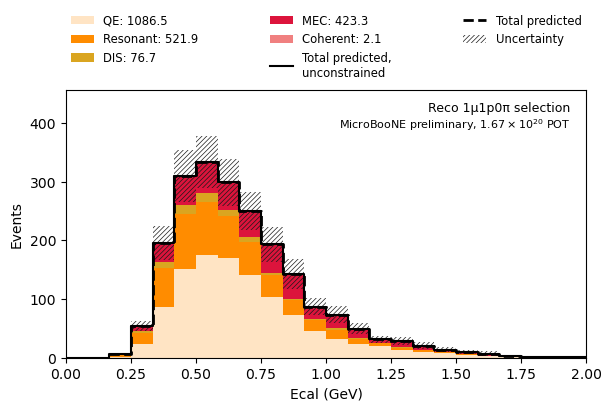

In [29]:
from microfit.run_plotter import RunHistPlotter

plotter = RunHistPlotter(signal_generator_1mu1p)
ax = plotter.plot(
    category_column="interaction",
    include_multisim_errors=True,
    add_ext_error_floor=False,
    show_data_mc_ratio=False,
    show_chi_square=False,
)

## FRACTIONAL UNCERTAINTY

In [29]:
# from microfit import histogram as hist
# from microfit import detsys


# reco_delta_pT   = sel_mc_1mu1p["delta_pT"].values
# sel_mc_1mu1p['delta_pT'] = reco_delta_pT

# for k, df in rundata.items():
#     if df is None:
#         continue
#     # ECal for all events
#     df["ECal_all"] = (
#         sel_mc_1mu1p["Ecal"]
#     )
#     df["delta_pT"] = (
#         sel_mc_1mu1p["delta_pT"]
#     )
#     # ECal only for pT<0.4
#     mask = df["delta_pT"] < 0.4
#     df["ECal_pT04"] = np.nan
#     df.loc[mask, "ECal_pT04"] = df.loc[mask, "ECal_all"]
    
#     mask = df["delta_pT"] < 0.3
#     df["ECal_pT03"] = np.nan
#     df.loc[mask, "ECal_pT03"] = df.loc[mask, "ECal_all"]
    
#     mask = df["delta_pT"] < 0.2
#     df["ECal_pT02"] = np.nan
#     df.loc[mask, "ECal_pT02"] = df.loc[mask, "ECal_all"]
    


# #IntegratedFlux = 1

# #edges = np.linspace(0.0, 1.5, 15) # OG
# edges = np.linspace(0.0, 2.0, 24)
# my_vars = [
#     ("ECal_all",  edges, r"ECal (No cut)"),
#     ("ECal_pT04", edges, r"ECal ($p_T<0.4$)"),
#     ("ECal_pT03", edges, r"ECal ($p_T<0.3$)"),
#     ("ECal_pT02", edges, r"ECal ($p_T<0.2$)"),
# ]

# for var_name, var_edges, var_tex in my_vars:
#     #  Binning from Ecal new df column 
#     binning = hist.Binning(variable=var_name, bin_edges=var_edges, label=var_name, variable_tex=var_tex)
#     print(f"\nUsing variable: {var_name}")
    
#         # ------------------------------------------------------------------
#     # Build a single RunHistGenerator for this binning
#     # ------------------------------------------------------------------
#     run_hist_gen = hist.RunHistGenerator(
#         rundata_stub,
#         binning.copy(),
#         data_pot=data_pot,
#         selection=selection,
#         preselection=preselection,
#         detvar_data=None,          # <-- no detector systematics here
#         uncertainty_defaults=None,
#     )

#     # ------------------------------------------------------------------
#     # Stat-only total prediction (MC + EXT), no multisim or detsys
#     # ------------------------------------------------------------------
#     total_prediction_stat = run_hist_gen.get_total_prediction(
#         include_multisim_errors=False,
#         add_precomputed_detsys=False,
#     )

#     bin_counts = total_prediction_stat.bin_counts
#     print("bin counts:", bin_counts)

#     # Stat covariance is already in the same normalization as bin_counts
#     stat_cov = total_prediction_stat.covariance_matrix
#     stat_error_frac = fractional_error_from_cov(stat_cov, bin_counts)
#     print("stat fractional error:", stat_error_frac)
#     print()

#     # ------------------------------------------------------------------
#     # GENIE multisim + unisim covariance (MC only)
#     #    We use the underlying mc_hist_generator from the same RunHistGenerator
#     # ------------------------------------------------------------------
#     mc_hist_generator = run_hist_gen.mc_hist_generator

#     # GENIE multisim covariance (weightsGenie)
#     genie_cov = mc_hist_generator.calculate_multisim_uncertainties(
#         multisim_weight_column="weightsGenie"
#     )
#     genie_error_frac = fractional_error_from_cov(genie_cov, bin_counts)
#     print("GENIE multisim fractional error:", genie_error_frac)
#     print()

#     # GENIE unisim covariance
#     genie_unisim_cov = mc_hist_generator.calculate_unisim_uncertainties()
#     genie_unisim_error_frac = fractional_error_from_cov(genie_unisim_cov, bin_counts)
#     print("GENIE unisim fractional error:", genie_unisim_error_frac)
#     print()

#     # Combine GENIE multisim + unisim in quadrature
#     genie_total_error_frac = np.sqrt(
#         genie_error_frac**2 + genie_unisim_error_frac**2
#     )
#     print("GENIE total (multisim ⊕ unisim) fractional error:", genie_total_error_frac)
#     print()

#     # Optionally, total (stat ⊕ GENIE) fractional uncertainty
#     total_frac_error = np.sqrt(stat_error_frac**2 + genie_total_error_frac**2)
#     print("Total (stat ⊕ GENIE) fractional error:", total_frac_error)
#     print()

#     # ------------------------------------------------------------------
#     # Fractional uncertainty plot
#     # ------------------------------------------------------------------
#     fig, ax = plt.subplots()

#     ax.stairs(genie_error_frac,          var_edges, label="GENIE multisim", linestyle="dashdot")
#     ax.stairs(genie_unisim_error_frac,   var_edges, label="GENIE unisim",   linestyle="dotted")
#     ax.stairs(genie_total_error_frac,    var_edges, label="GENIE total",    linestyle="solid")
#     ax.stairs(stat_error_frac,           var_edges, label="MC Stat",        linestyle="dashdot")
#     # If you want: ax.stairs(total_frac_error, var_edges, label="Total", linestyle="solid")

#     ax.set_xlabel(var_tex)
#     ax.set_ylabel("Fractional uncertainty")
#     ax.legend(loc="best")
#     ax.set_ylim(0, 0.4)
#     ax.set_xlim(0.20, 1.50)

#     plt.tight_layout()
#     # plt.savefig(f'analysis_plots/errors/noDet_{var_name}_{len(edges)-1}bins.png',
#     #             bbox_inches='tight')
#     plt.show()
#     plt.close()

#     # NOMINAL
#     # Stats error 
#     signal_generator_stat = hist.RunHistGenerator(
#         rundata_stub,
#         binning.copy(),
#         data_pot=data_pot,
#         selection=selection,
#         preselection=preselection,
#         detvar_data=None,                  # <-- no det sys
#         uncertainty_defaults=None,
#         #normalization_uncertainty=None,
#     )
 
#     total_prediction_stat = signal_generator_stat.get_total_prediction(include_multisim_errors=False, add_precomputed_detsys=False)
#     bin_counts = total_prediction_stat.bin_counts # Not Sure about this --> Needs verfication
#     print('bin counts:', bin_counts)
#     flux_norm_total_prediction_stat = total_prediction_stat / IntegratedFlux
#     stat_cov = flux_norm_total_prediction_stat.covariance_matrix
#     stat_error = np.sqrt(np.diagonal(stat_cov)) / bin_counts
#     print('stat error:', stat_error)
#     print()
    
#     # Multisim errors:
#     signal_generator_multisim = hist.RunHistGenerator(
#         rundata_stub,
#         binning.copy(),
#         data_pot=data_pot,
#         selection=selection,
#         preselection=preselection,
#         sideband_generator=None,
#         uncertainty_defaults=None,
#         detvar_data=None,
#         #normalization_uncertainty=None
#     )
    
#     mc_hist_generator = signal_generator_multisim.mc_hist_generator
    
#     # GENIE error
#     genie_cov = (mc_hist_generator.calculate_multisim_uncertainties(multisim_weight_column="weightsGenie")) / IntegratedFlux**2
#     genie_error = np.sqrt(np.diagonal(genie_cov)) / bin_counts
#     print('genie error:', genie_error)
#     print()
    
#     # GENIE Unisim
#     genie_unisim_cov = (mc_hist_generator.calculate_unisim_uncertainties()) / IntegratedFlux**2
#     genie_unisim_error = np.sqrt(np.diagonal(genie_unisim_cov)) / bin_counts
#     print('genie unisim error:', genie_unisim_error)
#     print()
    
    
#     # Fractional uncertainty plot
#     fig, ax = plt.subplots()
#     ax.stairs(genie_error, var_edges, label='GENIE', linestyle='dashdot')
#     ax.stairs(genie_error+genie_unisim_error, var_edges, label='GENIE (multisim + unisim)', linestyle='dashdot')
#     ax.stairs(stat_error, var_edges, label='MC Stat', linestyle='dashdot')
#     ax.set_xlabel(var_tex)
#     ax.set_ylabel('Fractional uncertainty')
#     ax.legend(loc="best")
#     ax.set_ylim(0,.4)
#     ax.set_xlim(0.20,1.50)
#     plt.tight_layout()
#     #plt.savefig(f'analysis_plots/errors/noDet_{var_name}_{len(bin_edges)-1}bins.png', bbox_inches='tight')
#     plt.show()
#     plt.close()

## FIXED FRACTIONAL UNCERTAINTY

/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,co


Using variable: ECal_all
bin counts: [  0.           0.           7.69043224  73.37680342 236.69871797
 336.09313857 340.55814777 290.97878643 238.80564427 182.94653457
 119.9415392   88.80601208  62.42887554  36.91175152  30.77601591
  24.5341831   14.57343009  10.68639082   7.11444418   4.19911668
   1.66498927   0.71318838   0.95334438]
stat fractional error: [0.         0.         0.14542592 0.05572588 0.03036339 0.02563645
 0.02606068 0.02788276 0.033007   0.04237704 0.05148893 0.06078279
 0.0771958  0.08593922 0.10960036 0.12465143 0.14752608 0.16172776
 0.29409954 0.32846254 0.36169073 0.44916801 0.37830778]

GENIE multisim fractional error: [0.         0.         0.13060163 0.10352995 0.1136979  0.1153305
 0.11008893 0.11363472 0.11132129 0.12105594 0.1200175  0.13618798
 0.13606576 0.11183217 0.14610437 0.15995834 0.13141391 0.13757587
 0.17471376 0.33908425 0.13848611 0.2539664  0.14082578]

GENIE unisim fractional error: [0.         0.         0.07360958 0.04546177 0.040511

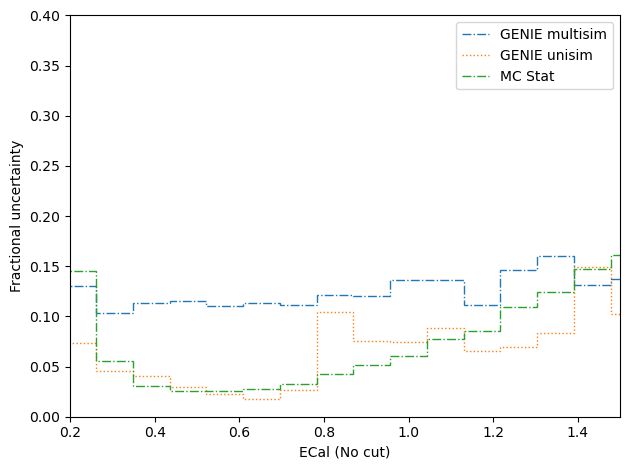


Using variable: ECal_pT04
bin counts: [  0.           0.           7.56024624  62.17995445 192.37204341
 272.54549965 266.46608518 232.83524346 192.5472012  144.37708158
  93.90812582  70.0243325   49.68936644  30.03602305  24.97165699
  18.18600771  11.67409652   7.08714288   6.69165141   1.80251393
   1.4670168    0.71318838   0.69297237]
stat fractional error: [0.         0.         0.14692448 0.05932225 0.03312895 0.02863778
 0.02758715 0.02982519 0.03555175 0.04503588 0.05558649 0.0660946
 0.08474319 0.09241722 0.11330102 0.12846863 0.13659545 0.18578543
 0.31089787 0.27835004 0.39771201 0.44916801 0.44752772]

GENIE multisim fractional error: [0.         0.         0.13115231 0.10154965 0.11097341 0.10986254
 0.10367796 0.10853697 0.10597224 0.11664877 0.10756934 0.12921015
 0.1306395  0.10206839 0.13408501 0.13357863 0.13002348 0.1101386
 0.17882362 0.11853288 0.15037856 0.2539664  0.10733089]

GENIE unisim fractional error: [0.         0.         0.07487712 0.05632654 0.044473

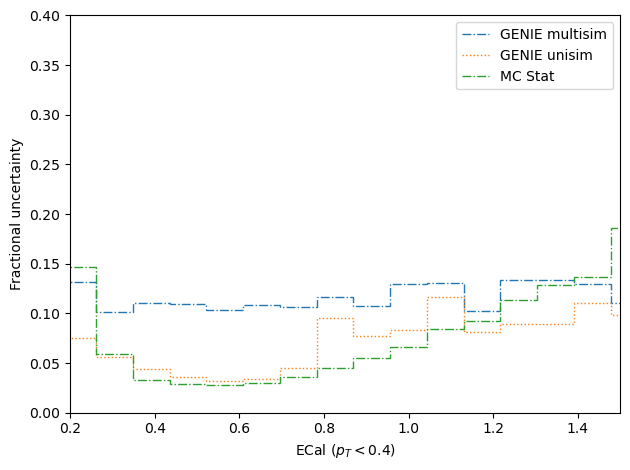


Using variable: ECal_pT03
bin counts: [  0.           0.           6.64497519  51.28392734 152.11523869
 220.74805629 218.64063045 192.04583597 162.98617599 120.60420983
  80.30229045  52.38091175  37.23606831  24.53545629  19.51480365
  15.92568784   9.71378994   5.9817277    5.38976839   1.5345338
   1.01263409   0.71318838   0.69297237]
stat fractional error: [0.         0.         0.15892087 0.06361318 0.03590774 0.03101731
 0.02960821 0.03074956 0.03729041 0.04634219 0.05586871 0.06419565
 0.08310017 0.08343555 0.1192811  0.13374022 0.12615106 0.20791481
 0.34555756 0.30273417 0.36142619 0.44916801 0.44752772]

GENIE multisim fractional error: [0.         0.         0.13200356 0.0965719  0.10425789 0.10691789
 0.10201703 0.10680702 0.10507513 0.11185812 0.10128576 0.11200072
 0.10759265 0.09858473 0.12322043 0.12709601 0.11881331 0.11483086
 0.16993238 0.12733651 0.10698255 0.2539664  0.10733089]

GENIE unisim fractional error: [0.         0.         0.05778694 0.06231286 0.05796

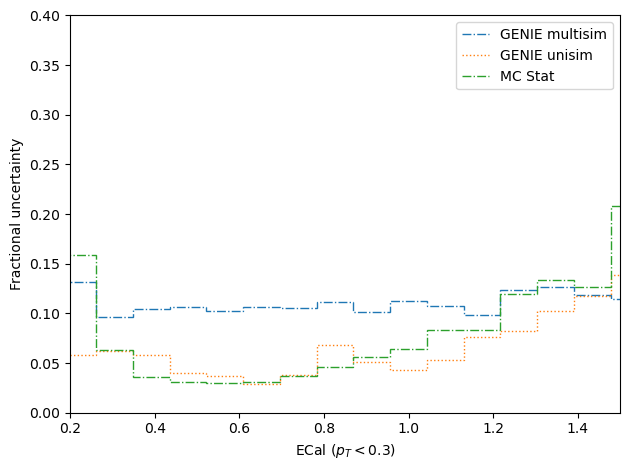


Using variable: ECal_pT02
bin counts: [  0.           0.           4.34163345  32.80097702  99.74777028
 150.64084883 151.94213258 136.72510196 113.93762127  84.76712216
  56.38761166  37.17611825  26.72334805  19.60450137  13.14913379
  10.85205567   5.50395533   5.4300172    4.67627372   0.67417582
   0.54593633   0.41665963   0.28012942]
stat fractional error: [0.         0.         0.18736685 0.07858413 0.04396042 0.03711763
 0.03456185 0.0360304  0.04314352 0.05329288 0.06336059 0.07505518
 0.09786045 0.09224185 0.14609245 0.1620422  0.16036893 0.22329888
 0.39239161 0.44735466 0.50081391 0.57800785 0.70780588]

GENIE multisim fractional error: [0.         0.         0.16630929 0.08497777 0.09639191 0.10188601
 0.10589173 0.10704024 0.10182598 0.1098294  0.1002992  0.10523458
 0.10423824 0.10508391 0.13202176 0.13972803 0.11265037 0.11943322
 0.1883796  0.11494805 0.10486948 0.14368351 0.069089  ]

GENIE unisim fractional error: [0.         0.         0.03000608 0.0601761  0.0635

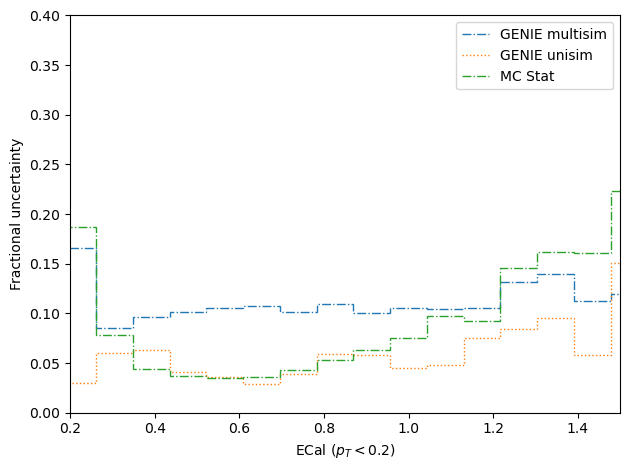

In [31]:
import numpy as np
import matplotlib.pyplot as plt

from microfit import histogram as hist
from microfit import detsys  # unused here, but fine to keep


# --- Helper: fractional error from covariance + central values ---
def fractional_error_from_cov(cov, central):
    """
    cov: (nbins, nbins) covariance matrix
    central: (nbins,) central bin contents (same normalization as cov)
    returns: (nbins,) fractional uncertainties (sigma / central)
    """
    central = np.asarray(central)
    diag = np.diag(cov)
    frac = np.zeros_like(central, dtype=float)

    mask = central > 0
    frac[mask] = np.sqrt(diag[mask]) / central[mask]
    # bins with central == 0 stay 0 (or you could set np.nan if you prefer)
    return frac



reco_delta_pT = sel_mc_1mu1p["delta_pT"].values
sel_mc_1mu1p["delta_pT"] = reco_delta_pT

reco_delta_alphaT = sel_mc_1mu1p["delta_alphaT"].values
sel_mc_1mu1p["delta_alphaT"] = reco_delta_alphaT

reco_delta_phiT = sel_mc_1mu1p["delta_phiT"].values
sel_mc_1mu1p["delta_phiT"] = reco_delta_phiT

#reco_pn = sel_mc_1mu1p["pn"].values
#sel_mc_1mu1p["pn"] = reco_pn

for k, df in rundata.items():
    if df is None:
        continue

    # ECal for all events
    df["ECal_all"] = sel_mc_1mu1p["Ecal"]
    df["delta_pT"] = sel_mc_1mu1p["delta_pT"]
    df["pn"]       = sel_mc_1mu1p["pn"]
    df["delta_alphaT"] = sel_mc_1mu1p["delta_alphaT"]

    # ECal only for pT < 0.4
    mask = df["delta_pT"] < 0.4
    df["ECal_pT04"] = np.nan
    df.loc[mask, "ECal_pT04"] = df.loc[mask, "ECal_all"]

    # ECal only for pT < 0.3
    mask = df["delta_pT"] < 0.3
    df["ECal_pT03"] = np.nan
    df.loc[mask, "ECal_pT03"] = df.loc[mask, "ECal_all"]

    # ECal only for pT < 0.2
    mask = df["delta_pT"] < 0.2 
    df["ECal_pT02"] = np.nan
    df.loc[mask, "ECal_pT02"] = df.loc[mask, "ECal_all"]
    
    mask = (df["delta_pT"] < 1.3) & (df["pn"] < 1.5)
    df["ECal_pTpN"] = np.nan
    df.loc[mask, "ECal_pTpN"] = df.loc[mask, "ECal_all"]


# IntegratedFlux = 1  # not needed for fractional errors

# edges = np.linspace(0.0, 1.5, 15)  # OG
edges = np.linspace(0.0, 2.0, 24)
my_vars = [
    ("ECal_all",  edges, r"ECal (No cut)"),
    ("ECal_pT04", edges, r"ECal ($p_T<0.4$)"),
    ("ECal_pT03", edges, r"ECal ($p_T<0.3$)"),
    ("ECal_pT02", edges, r"ECal ($p_T<0.2$)"),
    #("ECal_pTpN", edges, r"ECal ($p_T<1.3,\ p_n<1.5$)"),
]

for var_name, var_edges, var_tex in my_vars:
    #  Binning from Ecal new df column 
    binning = hist.Binning(
        variable=var_name,
        bin_edges=var_edges,
        label=var_name,
        variable_tex=var_tex,
    )
    print(f"\nUsing variable: {var_name}")
    
    #Build a single RunHistGenerator for this binning
    run_hist_gen = hist.RunHistGenerator(
        rundata_stub,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        detvar_data=None,          # <-- no detector systematics here
        uncertainty_defaults=None,
    )

    # Stat-only total prediction (MC + EXT), no multisim or detsys
    total_prediction_stat = run_hist_gen.get_total_prediction(
        include_multisim_errors=False,
        add_precomputed_detsys=False,
    )

    bin_counts = total_prediction_stat.bin_counts
    print("bin counts:", bin_counts)

    # Stat covariance is already in the same normalization as bin_counts
    stat_cov = total_prediction_stat.covariance_matrix
    stat_error_frac = fractional_error_from_cov(stat_cov, bin_counts)
    print("stat fractional error:", stat_error_frac)
    print()

    # GENIE multisim + unisim covariance (MC only)
    #    We use the underlying mc_hist_generator from the same RunHistGenerator
    mc_hist_generator = run_hist_gen.mc_hist_generator

    # GENIE multisim covariance (weightsGenie)
    genie_cov = mc_hist_generator.calculate_multisim_uncertainties(
        multisim_weight_column="weightsGenie"
    )
    genie_error_frac = fractional_error_from_cov(genie_cov, bin_counts)
    print("GENIE multisim fractional error:", genie_error_frac)
    print()

    # GENIE unisim covariance
    genie_unisim_cov = mc_hist_generator.calculate_unisim_uncertainties()
    genie_unisim_error_frac = fractional_error_from_cov(genie_unisim_cov, bin_counts)
    print("GENIE unisim fractional error:", genie_unisim_error_frac)
    print()

    # Combine GENIE multisim + unisim in quadrature
    genie_total_error_frac = np.sqrt(
        genie_error_frac**2 + genie_unisim_error_frac**2
    )
    print("GENIE total (multisim + unisim) fractional error:", genie_total_error_frac)
    print()

    # Optionally, total (stat + GENIE) fractional uncertainty
    total_frac_error = np.sqrt(stat_error_frac**2 + genie_total_error_frac**2)
    print("Total (stat + GENIE) fractional error:", total_frac_error)
    print()

    # Fractional uncertainty plot
    fig, ax = plt.subplots()

    ax.stairs(genie_error_frac,        var_edges, label="GENIE multisim", linestyle="dashdot")
    ax.stairs(genie_unisim_error_frac, var_edges, label="GENIE unisim",   linestyle="dotted")
    #ax.stairs(genie_total_error_frac,  var_edges, label="GENIE total",    linestyle="solid")
    ax.stairs(stat_error_frac,         var_edges, label="MC Stat",        linestyle="dashdot")
    # If you want: ax.stairs(total_frac_error, var_edges, label="Total", linestyle="solid")

    ax.set_xlabel(var_tex)
    ax.set_ylabel("Fractional uncertainty")
    ax.legend(loc="best")
    ax.set_ylim(0, 0.4)
    ax.set_xlim(0.20, 1.50)

    plt.tight_layout()
    # plt.savefig(f'analysis_plots/errors/noDet_{var_name}_{len(edges)-1}bins.png',
    #             bbox_inches='tight')
    plt.show()
    plt.close()


## ABSOLUTE ERROR

/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # This is added back by InteractiveShellApp.init_path()
/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:14: SettingWithCopyWarning: 
A value is trying to be set on a cop


Using variable: ECal_all
bin counts: [  0.           0.           7.69043224  73.37680342 236.69871797
 336.09313857 340.55814777 290.97878643 238.80564427 182.94653457
 119.9415392   88.80601208  62.42887554  36.91175152  30.77601591
  24.5341831   14.57343009  10.68639082   7.11444418   4.19911668
   1.66498927   0.71318838   0.95334438]
stat abs error: [1.68587394e-07 1.68587394e-07 1.11838822e+00 4.08898673e+00
 7.18697621e+00 8.61623610e+00 8.87517826e+00 8.11329156e+00
 7.88225794e+00 7.75273302e+00 6.17566092e+00 5.39787679e+00
 4.81924721e+00 3.17216714e+00 3.37306239e+00 3.05822095e+00
 2.14996108e+00 1.72828604e+00 2.09235475e+00 1.37925253e+00
 6.02211180e-01 3.20341405e-01 3.60657592e-01]

GENIE multisim abs error: [ 0.          0.          1.00438295  7.59669696 26.91214617 38.76178922
 37.49168201 33.06529157 26.58415171 22.146765   14.39508338 12.09431139
  8.49443242  4.12792131  4.49651039  3.92444722  1.91515142  1.47018955
  1.24299132  1.42385434  0.23057788  0.181

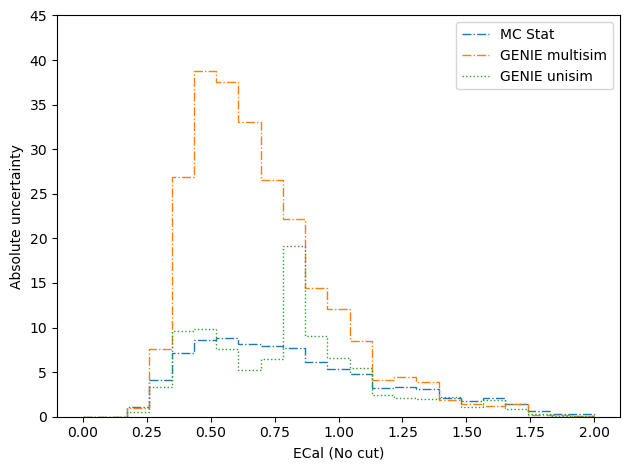


Using variable: ECal_pT04
bin counts: [  0.           0.           7.56024624  62.17995445 192.37204341
 272.54549965 266.46608518 232.83524346 192.5472012  144.37708158
  93.90812582  70.0243325   49.68936644  30.03602305  24.97165699
  18.18600771  11.67409652   7.08714288   6.69165141   1.80251393
   1.4670168    0.71318838   0.69297237]
stat abs error: [1.68587394e-07 1.68587394e-07 1.11078522e+00 3.68865498e+00
 6.37308425e+00 7.80509822e+00 7.35103950e+00 6.94435638e+00
 6.84539024e+00 6.50214869e+00 5.22002270e+00 4.62823010e+00
 4.21083531e+00 2.77584579e+00 2.82931417e+00 2.33633155e+00
 1.59462846e+00 1.31668790e+00 2.08042019e+00 5.01729827e-01
 5.83450201e-01 3.20341405e-01 3.10124343e-01]

GENIE multisim abs error: [ 0.          0.          0.99154372  6.31435244 21.34818195 29.94254211
 27.62666088 25.27123279 20.4046586  16.84140835 10.101635    9.04785448
  6.49139415  3.06572846  3.34832476  2.42926207  1.51790665  0.78056798
  1.19662531  0.21365717  0.22060787  0.18

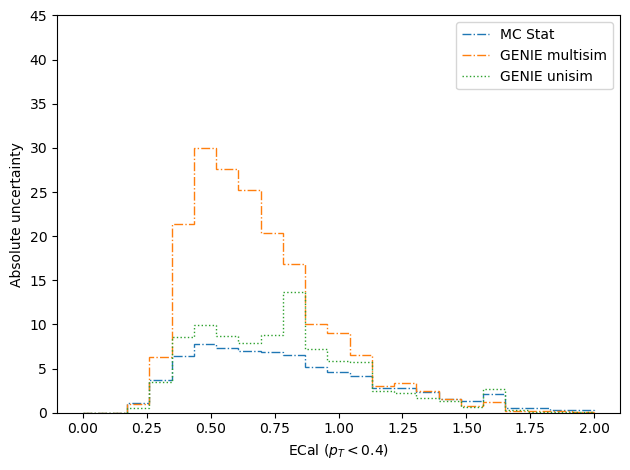


Using variable: ECal_pT03
bin counts: [  0.           0.           6.64497519  51.28392734 152.11523869
 220.74805629 218.64063045 192.04583597 162.98617599 120.60420983
  80.30229045  52.38091175  37.23606831  24.53545629  19.51480365
  15.92568784   9.71378994   5.9817277    5.38976839   1.5345338
   1.01263409   0.71318838   0.69297237]
stat abs error: [1.19209290e-07 1.19209290e-07 1.05602523e+00 3.26233348e+00
 5.46211485e+00 6.84701040e+00 6.47355769e+00 5.90532528e+00
 6.07782172e+00 5.58906365e+00 4.48638537e+00 3.36262672e+00
 3.09432379e+00 2.04712920e+00 2.32774733e+00 2.12990505e+00
 1.22540492e+00 1.24368976e+00 1.86247523e+00 4.64555810e-01
 3.65992482e-01 3.20341405e-01 3.10124343e-01]

GENIE multisim abs error: [ 0.          0.          0.87716038  4.95258639 15.85921444 23.60191653
 22.30506839 20.51184251 17.12579313 13.4905603   8.13347817  5.8666996
  4.00632732  2.41882146  2.40462245  2.02409136  1.15412756  0.68688693
  0.91589619  0.19540219  0.10833417  0.1811

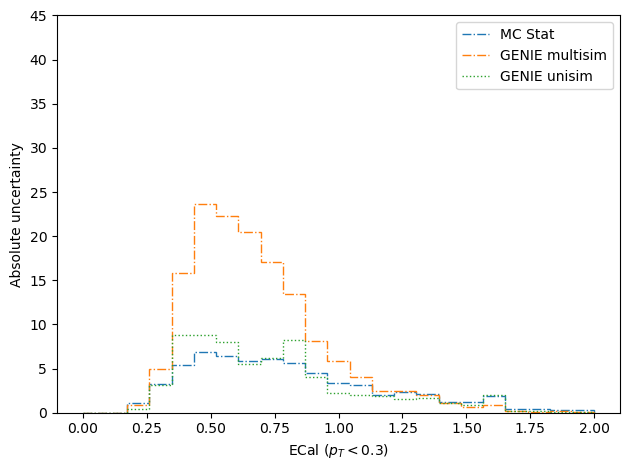


Using variable: ECal_pT02
bin counts: [  0.           0.           4.34163345  32.80097702  99.74777028
 150.64084883 151.94213258 136.72510196 113.93762127  84.76712216
  56.38761166  37.17611825  26.72334805  19.60450137  13.14913379
  10.85205567   5.50395533   5.4300172    4.67627372   0.67417582
   0.54593633   0.41665963   0.28012942]
stat abs error: [8.42936970e-08 8.42936970e-08 8.13478172e-01 2.57763627e+00
 4.38495360e+00 5.59143135e+00 5.25140080e+00 4.92626073e+00
 4.91567020e+00 4.51748444e+00 3.57275223e+00 2.79026042e+00
 2.61515876e+00 1.80835548e+00 1.92098922e+00 1.75849099e+00
 8.82663444e-01 1.21251675e+00 1.83493058e+00 3.01595695e-01
 2.73412508e-01 2.40832538e-01 1.98277249e-01]

GENIE multisim abs error: [ 0.          0.          0.72205396  2.78735372  9.61487798 15.34819575
 16.08941505 14.63508826 11.60181037  9.30992208  5.65563206  3.91221324
  2.78559465  2.06011773  1.73597177  1.51633639  0.62002262  0.64852443
  0.88091458  0.07749519  0.05725206  0.05

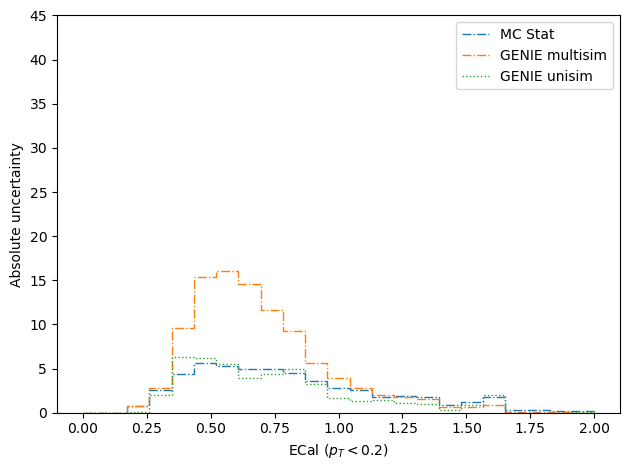

In [34]:
import numpy as np
import matplotlib.pyplot as plt

from microfit import histogram as hist
from microfit import detsys  # unused but fine

reco_delta_pT = sel_mc_1mu1p["delta_pT"].values
sel_mc_1mu1p["delta_pT"] = reco_delta_pT

reco_delta_alphaT = sel_mc_1mu1p["delta_alphaT"].values
sel_mc_1mu1p["delta_alphaT"] = reco_delta_alphaT

reco_delta_phiT = sel_mc_1mu1p["delta_phiT"].values
sel_mc_1mu1p["delta_phiT"] = reco_delta_phiT


for k, df in rundata.items():
    if df is None:
        continue

    # ECal for all events
    df["ECal_all"] = sel_mc_1mu1p["Ecal"]
    df["delta_pT"] = sel_mc_1mu1p["delta_pT"]
    df["delta_alphaT"] = sel_mc_1mu1p["delta_alphaT"]
    df["delta_phiT"] = sel_mc_1mu1p["delta_phiT"]

    # ECal only for pT < 0.4
    mask = df["delta_pT"] < 0.4
    df["ECal_pT04"] = np.nan
    df.loc[mask, "ECal_pT04"] = df.loc[mask, "ECal_all"]

    # ECal only for pT < 0.3
    mask = df["delta_pT"] < 0.3
    df["ECal_pT03"] = np.nan
    df.loc[mask, "ECal_pT03"] = df.loc[mask, "ECal_all"]

    # ECal only for pT < 0.2
    mask = df["delta_pT"] < 0.2
    df["ECal_pT02"] = np.nan
    df.loc[mask, "ECal_pT02"] = df.loc[mask, "ECal_all"]


edges = np.linspace(0.0, 2.0, 24)
my_vars = [
    ("ECal_all",  edges, r"ECal (No cut)"),
    ("ECal_pT04", edges, r"ECal ($p_T<0.4$)"),
    ("ECal_pT03", edges, r"ECal ($p_T<0.3$)"),
    ("ECal_pT02", edges, r"ECal ($p_T<0.2$)"),
]

for var_name, var_edges, var_tex in my_vars:
    #  Binning from Ecal new df column 
    binning = hist.Binning(
        variable=var_name,
        bin_edges=var_edges,
        label=var_name,
        variable_tex=var_tex,
    )
    print(f"\nUsing variable: {var_name}")
    
    #  Build a single RunHistGenerator for this binning
    run_hist_gen = hist.RunHistGenerator(
        rundata_stub,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        detvar_data=None,          # <-- no detector systematics here
        uncertainty_defaults=None,
    )

    # Stat-only total prediction (MC + EXT), no multisim or detsys
    total_prediction_stat = run_hist_gen.get_total_prediction(
        include_multisim_errors=False,
        add_precomputed_detsys=False,
    )

    bin_counts = total_prediction_stat.bin_counts
    print("bin counts:", bin_counts)

    # Stat covariance is already in the same normalization as bin_counts
    stat_cov = total_prediction_stat.covariance_matrix
    stat_sigma = np.sqrt(np.diag(stat_cov))
    print("stat abs error:", stat_sigma)
    print()

    # GENIE multisim + unisim covariance (MC only)
    mc_hist_generator = run_hist_gen.mc_hist_generator

    # GENIE multisim covariance (weightsGenie)
    genie_cov = mc_hist_generator.calculate_multisim_uncertainties(
        multisim_weight_column="weightsGenie"
    )
    genie_sigma = np.sqrt(np.diag(genie_cov))
    print("GENIE multisim abs error:", genie_sigma)
    print()

    # GENIE unisim covariance
    genie_unisim_cov = mc_hist_generator.calculate_unisim_uncertainties()
    genie_unisim_sigma = np.sqrt(np.diag(genie_unisim_cov))
    print("GENIE unisim abs error:", genie_unisim_sigma)
    print()

    # Combine GENIE multisim + unisim in quadrature (per bin)
    genie_total_sigma = np.sqrt(genie_sigma**2 + genie_unisim_sigma**2)
    print("GENIE total (multisim + unisim) abs error:", genie_total_sigma)
    print()

    # Optionally, total (stat + GENIE) absolute uncertainty per bin
    total_sigma = np.sqrt(stat_sigma**2 + genie_total_sigma**2)
    print("Total (stat + GENIE) abs error:", total_sigma)
    print()

    # Absolute uncertainty plot
    fig, ax = plt.subplots()

    ax.stairs(stat_sigma,         var_edges, label="MC Stat",        linestyle="dashdot")
    ax.stairs(genie_sigma,        var_edges, label="GENIE multisim", linestyle="dashdot")
    ax.stairs(genie_unisim_sigma, var_edges, label="GENIE unisim",   linestyle="dotted")
    #ax.stairs(genie_total_sigma,  var_edges, label="GENIE total",    linestyle="solid")
    #ax.stairs(total_sigma,        var_edges, label="Total",          linestyle="solid")

    ax.set_xlabel(var_tex)
    ax.set_ylabel("Absolute uncertainty")
    ax.legend(loc="best")
    ax.set_ylim(0, 45)
    plt.tight_layout()
    plt.show()
    plt.close()


## SUB PROCESS -> ECAL

In [35]:
# from microfit.statistics import covariance 

# # Get total cov + per-knob histograms
# unisim_cov_total, unisim_hist_dict = mc_hist_generator.calculate_unisim_uncertainties(
#     return_histograms=True,
#     skip_covariance=False,   # we still want total
# )

# # Central value histogram for this generator (same selection/binning)
# central_hist = mc_hist_generator._histogram_multi_channel(mc_hist_generator.dataframe)
# cv_counts = central_hist.bin_counts

# unisim_errors_per_knob = {}

# for knob, observations in unisim_hist_dict.items():
#     # observations shape: (n_universes, n_bins)
#     cov_knob = covariance(
#         observations,
#         cv_counts,
#         allow_approximation=True,
#         tolerance=1e-8,
#         debug_name=knob,
#     ) / IntegratedFlux**2
#     err_knob = np.sqrt(np.diag(cov_knob)) / safe_counts
#     unisim_errors_per_knob[knob] = err_knob


In [36]:
# fig, ax = plt.subplots()

# ax.stairs(stat_error, var_edges, label='MC Stat')

# ax.stairs(genie_error, var_edges, label='GENIE multisim')

# #dominant knobs
# for knob in ["knobRPA", "knobCCMEC", "knobAxFFCCQE","knobAxFFCCQE","knobDecayAngMEC","knobThetaDelta2Npi",]:
#     if knob in unisim_errors_per_knob:
#         ax.stairs(unisim_errors_per_knob[knob], var_edges, label=f'{knob}', linestyle='dashdot')

# ax.set_xlabel(var_tex)
# ax.set_ylabel('Fractional uncertainty')
# ax.legend(loc="best")
# ax.set_ylim(0, 0.4)
# ax.set_xlim(0.20, 1.50)
# plt.tight_layout()
# plt.show()
# plt.close()


### Fractional


Using variable: ECal_all
bin counts: [  0.           0.           7.69043224  73.37680342 236.69871797
 336.09313857 340.55814777 290.97878643 238.80564427 182.94653457
 119.9415392   88.80601208  62.42887554  36.91175152  30.77601591
  24.5341831   14.57343009  10.68639082   7.11444418   4.19911668
   1.66498927   0.71318838   0.95334438]
stat error: [       nan        nan 0.14542592 0.05572588 0.03036339 0.02563645
 0.02606068 0.02788276 0.033007   0.04237704 0.05148893 0.06078279
 0.0771958  0.08593922 0.10960036 0.12465143 0.14752608 0.16172776
 0.29409954 0.32846254 0.36169073 0.44916801 0.37830778]

GENIE multisim error: [       nan        nan 0.13060163 0.10352995 0.1136979  0.1153305
 0.11008893 0.11363472 0.11132129 0.12105594 0.1200175  0.13618798
 0.13606576 0.11183217 0.14610437 0.15995834 0.13141391 0.13757587
 0.17471376 0.33908425 0.13848611 0.2539664  0.14082578]

GENIE unisim total error: [       nan        nan 0.07360958 0.04546177 0.04051186 0.02921773
 0.02220359 0

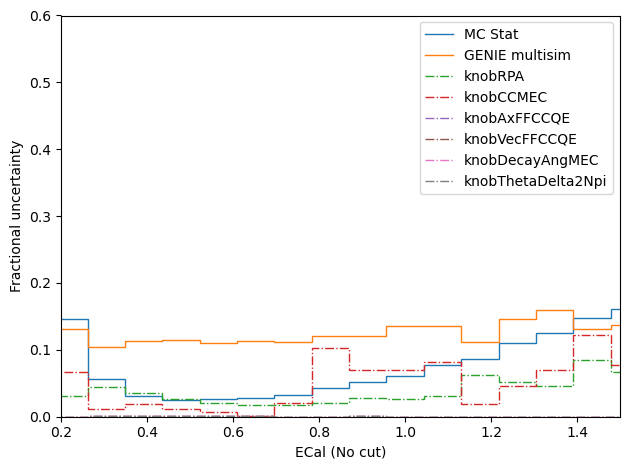


Using variable: ECal_pT04
bin counts: [  0.           0.           7.56024624  62.17995445 192.37204341
 272.54549965 266.46608518 232.83524346 192.5472012  144.37708158
  93.90812582  70.0243325   49.68936644  30.03602305  24.97165699
  18.18600771  11.67409652   7.08714288   6.69165141   1.80251393
   1.4670168    0.71318838   0.69297237]
stat error: [       nan        nan 0.14692448 0.05932225 0.03312895 0.02863778
 0.02758715 0.02982519 0.03555175 0.04503588 0.05558649 0.0660946
 0.08474319 0.09241722 0.11330102 0.12846863 0.13659545 0.18578543
 0.31089787 0.27835004 0.39771201 0.44916801 0.44752772]

GENIE multisim error: [       nan        nan 0.13115231 0.10154965 0.11097341 0.10986254
 0.10367796 0.10853697 0.10597224 0.11664877 0.10756934 0.12921015
 0.1306395  0.10206839 0.13408501 0.13357863 0.13002348 0.1101386
 0.17882362 0.11853288 0.15037856 0.2539664  0.10733089]

GENIE unisim total error: [       nan        nan 0.07487712 0.05632654 0.04447394 0.03630715
 0.0324451  0

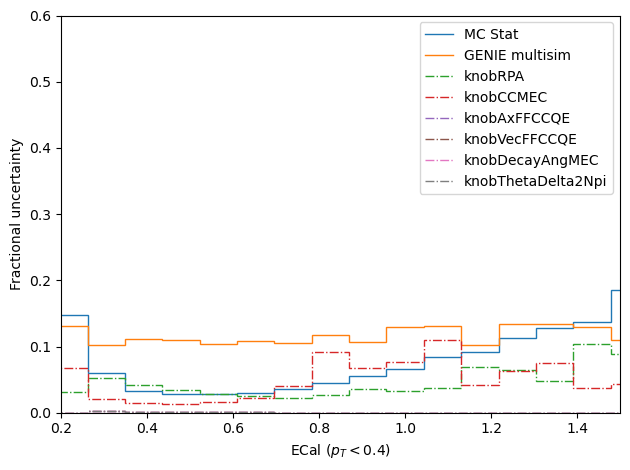


Using variable: ECal_pT03
bin counts: [  0.           0.           6.64497519  51.28392734 152.11523869
 220.74805629 218.64063045 192.04583597 162.98617599 120.60420983
  80.30229045  52.38091175  37.23606831  24.53545629  19.51480365
  15.92568784   9.71378994   5.9817277    5.38976839   1.5345338
   1.01263409   0.71318838   0.69297237]
stat error: [       nan        nan 0.15892087 0.06361318 0.03590774 0.03101731
 0.02960821 0.03074956 0.03729041 0.04634219 0.05586871 0.06419565
 0.08310017 0.08343555 0.1192811  0.13374022 0.12615106 0.20791481
 0.34555756 0.30273417 0.36142619 0.44916801 0.44752772]

GENIE multisim error: [       nan        nan 0.13200356 0.0965719  0.10425789 0.10691789
 0.10201703 0.10680702 0.10507513 0.11185812 0.10128576 0.11200072
 0.10759265 0.09858473 0.12322043 0.12709601 0.11881331 0.11483086
 0.16993238 0.12733651 0.10698255 0.2539664  0.10733089]

GENIE unisim total error: [       nan        nan 0.05778694 0.06231286 0.05796085 0.03988653
 0.0368087  

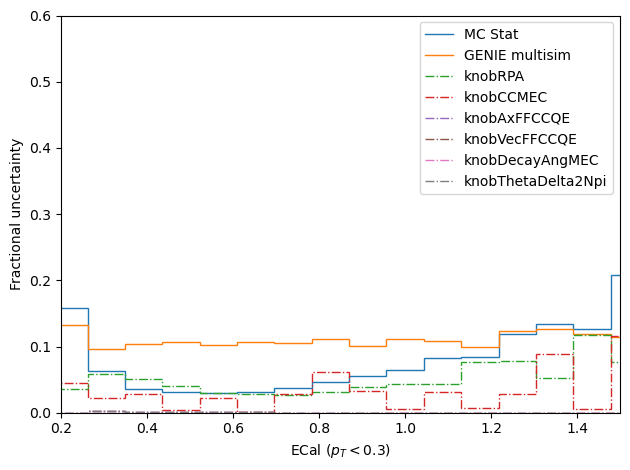


Using variable: ECal_pT02
bin counts: [  0.           0.           4.34163345  32.80097702  99.74777028
 150.64084883 151.94213258 136.72510196 113.93762127  84.76712216
  56.38761166  37.17611825  26.72334805  19.60450137  13.14913379
  10.85205567   5.50395533   5.4300172    4.67627372   0.67417582
   0.54593633   0.41665963   0.28012942]
stat error: [       nan        nan 0.18736685 0.07858413 0.04396042 0.03711763
 0.03456185 0.0360304  0.04314352 0.05329288 0.06336059 0.07505518
 0.09786045 0.09224185 0.14609245 0.1620422  0.16036893 0.22329888
 0.39239161 0.44735466 0.50081391 0.57800785 0.70780588]

GENIE multisim error: [       nan        nan 0.16630929 0.08497777 0.09639191 0.10188601
 0.10589173 0.10704024 0.10182598 0.1098294  0.1002992  0.10523458
 0.10423824 0.10508391 0.13202176 0.13972803 0.11265037 0.11943322
 0.1883796  0.11494805 0.10486948 0.14368351 0.069089  ]

GENIE unisim total error: [       nan        nan 0.03000608 0.0601761  0.06356043 0.04088356
 0.03644159

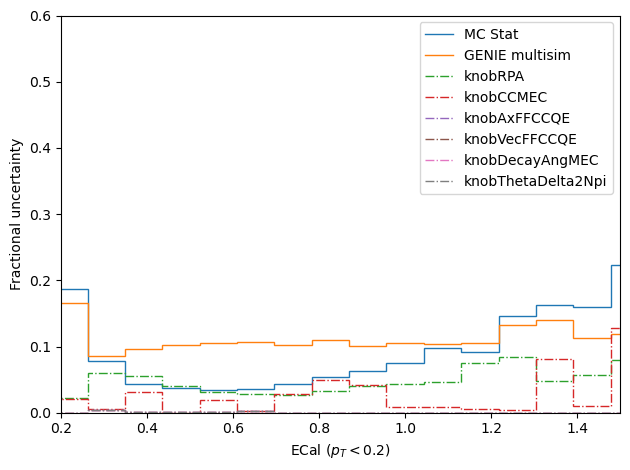

In [37]:
from microfit.statistics import covariance


edges = np.linspace(0.0, 1.0, 12)
# my_vars1 = [
#     ("delta_pT",  edges, r"delta_pT (No cut)"),
    
# ]

for var_name, var_edges, var_tex in my_vars:
    # Binning from Ecal-like df column 
    binning = hist.Binning(
        variable=var_name,
        bin_edges=var_edges,
        label=var_name,
        variable_tex=var_tex,
    )
    print(f"\nUsing variable: {var_name}")

    
    # MC stat only
    signal_generator_stat = hist.RunHistGenerator(
        rundata_stub,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        detvar_data=None,
        uncertainty_defaults=None,
    )

    total_prediction_stat = signal_generator_stat.get_total_prediction(
        include_multisim_errors=False,
        add_precomputed_detsys=False,
    )

    bin_counts = total_prediction_stat.bin_counts
    print("bin counts:", bin_counts)

    # Define this (if we want flux normalization) or set to 1
    IntegratedFlux = 1.0

    flux_norm_total_prediction_stat = total_prediction_stat / IntegratedFlux
    stat_cov = flux_norm_total_prediction_stat.covariance_matrix

    # Protect against division by zero
    safe_counts = bin_counts.astype(float).copy()
    safe_counts[safe_counts == 0] = np.nan

    stat_error = np.sqrt(np.diag(stat_cov)) / safe_counts
    print("stat error:", stat_error)
    print()

    # Multisim: GENIE total
    signal_generator_multisim = hist.RunHistGenerator(
        rundata_stub,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
        detvar_data=None,
    )

    mc_hist_generator = signal_generator_multisim.mc_hist_generator

    genie_cov = (
        mc_hist_generator.calculate_multisim_uncertainties(
            multisim_weight_column="weightsGenie"
        )
        / IntegratedFlux**2
    )
    genie_error = np.sqrt(np.diag(genie_cov)) / safe_counts
    print("GENIE multisim error:", genie_error)
    print()

    
    #Unisim: total + per-knob
    
    unisim_cov_total, unisim_hist_dict = mc_hist_generator.calculate_unisim_uncertainties(
        return_histograms=True,
        skip_covariance=False,   # we also want the total covariance
    )

    # Total GENIE unisim fractional error
    genie_unisim_error_total = np.sqrt(np.diag(unisim_cov_total)) / safe_counts
    print("GENIE unisim total error:", genie_unisim_error_total)
    print()

    # Central value (same binning/selection) used for per-knob covariances
    central_hist = mc_hist_generator._histogram_multi_channel(mc_hist_generator.dataframe)
    cv_counts = central_hist.bin_counts

    unisim_errors_per_knob = {}
    for knob, observations in unisim_hist_dict.items():
        # observations shape: (n_universes, n_bins)
        cov_knob = (
            covariance(
                observations,
                cv_counts,
                allow_approximation=True,
                tolerance=1e-8,
                debug_name=knob,
            )
            / IntegratedFlux**2
        )
        err_knob = np.sqrt(np.diag(cov_knob)) / safe_counts
        unisim_errors_per_knob[knob] = err_knob
        print(f"{knob} unisim error:", err_knob)

    # Plot: stat, GENIE multisim (total), all unisim knobs, unisim total
    fig, ax = plt.subplots()

    ax.stairs(stat_error, var_edges, label="MC Stat")

    ax.stairs(
        genie_error,
        var_edges,
        label="GENIE multisim",
    )

    # Plot every knob in unisim_errors_per_knob
    for knob, err_knob in unisim_errors_per_knob.items():
        ax.stairs(
            err_knob,
            var_edges,
            label=knob,
            linestyle="dashdot",
        )

    # plot the *total* unisim uncertainty
#     ax.stairs(
#         genie_unisim_error_total,
#         var_edges,
#         label="GENIE unisim (total)",
#         linestyle="dashed",
#     )

    ax.set_xlabel(var_tex)
    ax.set_ylabel("Fractional uncertainty")
    ax.legend(loc="best")
    ax.set_ylim(0, 0.6)
    ax.set_xlim(0.20, 1.50)
    #ax.set_xlim(0.0, 1.0) #delta_pT
    plt.tight_layout()
    plt.show()
    plt.close()



Using variable: ECal_all
bin counts: [  0.           0.           7.69043224  73.37680342 236.69871797
 336.09313857 340.55814777 290.97878643 238.80564427 182.94653457
 119.9415392   88.80601208  62.42887554  36.91175152  30.77601591
  24.5341831   14.57343009  10.68639082   7.11444418   4.19911668
   1.66498927   0.71318838   0.95334438]
MC stat fractional error: [       nan        nan 0.14542592 0.05572588 0.03036339 0.02563645
 0.02606068 0.02788276 0.033007   0.04237704 0.05148893 0.06078279
 0.0771958  0.08593922 0.10960036 0.12465143 0.14752608 0.16172776
 0.29409954 0.32846254 0.36169073 0.44916801 0.37830778]
GENIE multisim fractional error: [       nan        nan 0.13060163 0.10352995 0.1136979  0.1153305
 0.11008893 0.11363472 0.11132129 0.12105594 0.1200175  0.13618798
 0.13606576 0.11183217 0.14610437 0.15995834 0.13141391 0.13757587
 0.17471376 0.33908425 0.13848611 0.2539664  0.14082578]
GENIE unisim total fractional error: [       nan        nan 0.07360958 0.04546177 0

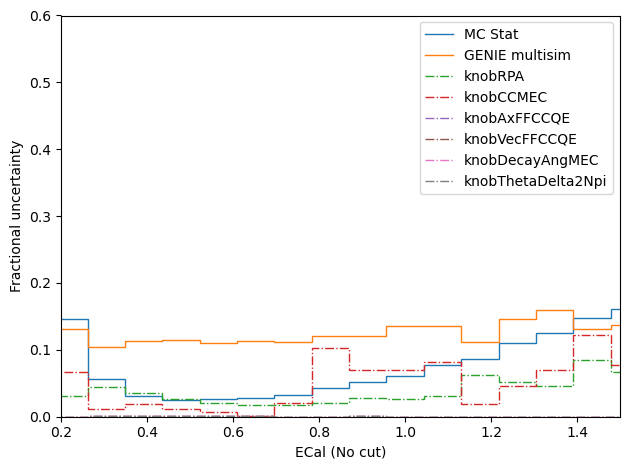


Using variable: ECal_pT04
bin counts: [  0.           0.           7.56024624  62.17995445 192.37204341
 272.54549965 266.46608518 232.83524346 192.5472012  144.37708158
  93.90812582  70.0243325   49.68936644  30.03602305  24.97165699
  18.18600771  11.67409652   7.08714288   6.69165141   1.80251393
   1.4670168    0.71318838   0.69297237]
MC stat fractional error: [       nan        nan 0.14692448 0.05932225 0.03312895 0.02863778
 0.02758715 0.02982519 0.03555175 0.04503588 0.05558649 0.0660946
 0.08474319 0.09241722 0.11330102 0.12846863 0.13659545 0.18578543
 0.31089787 0.27835004 0.39771201 0.44916801 0.44752772]
GENIE multisim fractional error: [       nan        nan 0.13115231 0.10154965 0.11097341 0.10986254
 0.10367796 0.10853697 0.10597224 0.11664877 0.10756934 0.12921015
 0.1306395  0.10206839 0.13408501 0.13357863 0.13002348 0.1101386
 0.17882362 0.11853288 0.15037856 0.2539664  0.10733089]
GENIE unisim total fractional error: [       nan        nan 0.07487712 0.05632654 0

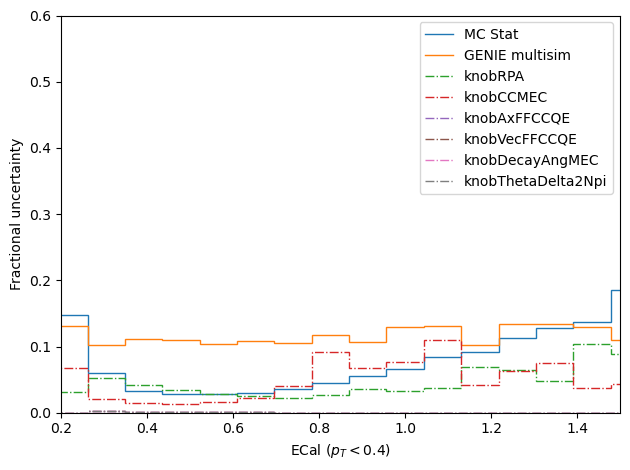


Using variable: ECal_pT03
bin counts: [  0.           0.           6.64497519  51.28392734 152.11523869
 220.74805629 218.64063045 192.04583597 162.98617599 120.60420983
  80.30229045  52.38091175  37.23606831  24.53545629  19.51480365
  15.92568784   9.71378994   5.9817277    5.38976839   1.5345338
   1.01263409   0.71318838   0.69297237]
MC stat fractional error: [       nan        nan 0.15892087 0.06361318 0.03590774 0.03101731
 0.02960821 0.03074956 0.03729041 0.04634219 0.05586871 0.06419565
 0.08310017 0.08343555 0.1192811  0.13374022 0.12615106 0.20791481
 0.34555756 0.30273417 0.36142619 0.44916801 0.44752772]
GENIE multisim fractional error: [       nan        nan 0.13200356 0.0965719  0.10425789 0.10691789
 0.10201703 0.10680702 0.10507513 0.11185812 0.10128576 0.11200072
 0.10759265 0.09858473 0.12322043 0.12709601 0.11881331 0.11483086
 0.16993238 0.12733651 0.10698255 0.2539664  0.10733089]
GENIE unisim total fractional error: [       nan        nan 0.05778694 0.06231286 

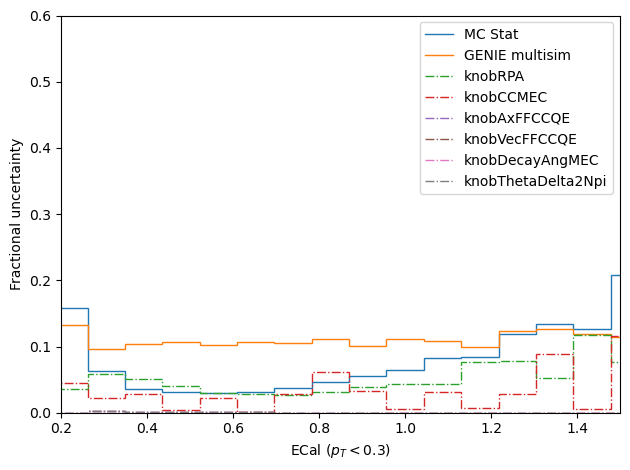


Using variable: ECal_pT02
bin counts: [  0.           0.           4.34163345  32.80097702  99.74777028
 150.64084883 151.94213258 136.72510196 113.93762127  84.76712216
  56.38761166  37.17611825  26.72334805  19.60450137  13.14913379
  10.85205567   5.50395533   5.4300172    4.67627372   0.67417582
   0.54593633   0.41665963   0.28012942]
MC stat fractional error: [       nan        nan 0.18736685 0.07858413 0.04396042 0.03711763
 0.03456185 0.0360304  0.04314352 0.05329288 0.06336059 0.07505518
 0.09786045 0.09224185 0.14609245 0.1620422  0.16036893 0.22329888
 0.39239161 0.44735466 0.50081391 0.57800785 0.70780588]
GENIE multisim fractional error: [       nan        nan 0.16630929 0.08497777 0.09639191 0.10188601
 0.10589173 0.10704024 0.10182598 0.1098294  0.1002992  0.10523458
 0.10423824 0.10508391 0.13202176 0.13972803 0.11265037 0.11943322
 0.1883796  0.11494805 0.10486948 0.14368351 0.069089  ]
GENIE unisim total fractional error: [       nan        nan 0.03000608 0.0601761 

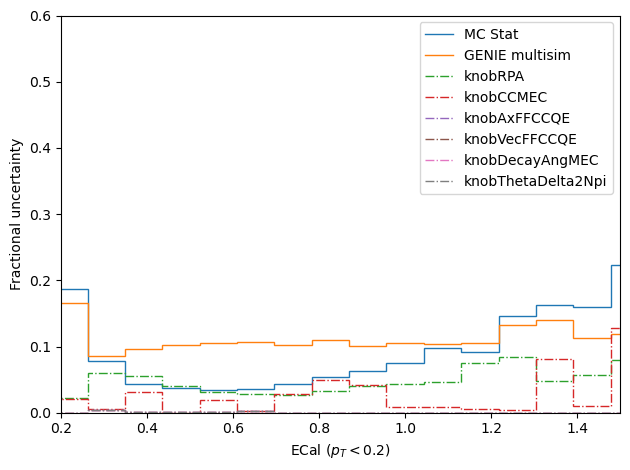

In [35]:
from microfit.statistics import covariance

edges = np.linspace(0.0, 1.0, 12)  # ECal edges 

for var_name, var_edges, var_tex in my_vars:
    binning = hist.Binning(
        variable=var_name,
        bin_edges=var_edges,
        label=var_name,
        variable_tex=var_tex,
    )
    print(f"\nUsing variable: {var_name}")

    # -----------------------
    # 1) Stat-only prediction
    # -----------------------
    signal_generator_stat = hist.RunHistGenerator(
        rundata_stub,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        detvar_data=None,
        uncertainty_defaults=None,
    )

    total_prediction_stat = signal_generator_stat.get_total_prediction(
        include_multisim_errors=False,
        add_precomputed_detsys=False,
    )

    bin_counts = total_prediction_stat.bin_counts
    print("bin counts:", bin_counts)

    IntegratedFlux = 1.0

    flux_norm_total_prediction_stat = total_prediction_stat / IntegratedFlux
    stat_cov = flux_norm_total_prediction_stat.covariance_matrix

    safe_counts = bin_counts.astype(float).copy()
    safe_counts[safe_counts == 0] = np.nan

    stat_error_frac = np.sqrt(np.diag(stat_cov)) / safe_counts
    print("MC stat fractional error:", stat_error_frac)

    # -----------------------
    # 2) Multisim: GENIE
    # -----------------------
    signal_generator_multisim = hist.RunHistGenerator(
        rundata_stub,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
        detvar_data=None,
    )

    mc_hist_generator = signal_generator_multisim.mc_hist_generator

    genie_cov = mc_hist_generator.calculate_multisim_uncertainties(
        multisim_weight_column="weightsGenie"
    ) / IntegratedFlux**2

    genie_error_frac = np.sqrt(np.diag(genie_cov)) / safe_counts
    print("GENIE multisim fractional error:", genie_error_frac)

    # -----------------------
    # 3) Unisim: total + per knob
    # -----------------------
    unisim_cov_total, unisim_hist_dict = mc_hist_generator.calculate_unisim_uncertainties(
        return_histograms=True,
        skip_covariance=False,
    )

    genie_unisim_total_frac = np.sqrt(np.diag(unisim_cov_total)) / safe_counts
    print("GENIE unisim total fractional error:", genie_unisim_total_frac)

    central_hist = mc_hist_generator._histogram_multi_channel(mc_hist_generator.dataframe)
    cv_counts = central_hist.bin_counts

    unisim_errors_per_knob = {}
    for knob, observations in unisim_hist_dict.items():
        cov_knob = covariance(
            observations,
            cv_counts,
            allow_approximation=True,
            tolerance=1e-8,
            debug_name=knob,
        ) / IntegratedFlux**2
        err_knob_frac = np.sqrt(np.diag(cov_knob)) / safe_counts
        unisim_errors_per_knob[knob] = err_knob_frac
        print(f"{knob} unisim fractional error:", err_knob_frac)

    # -----------------------
    # 4) Plot fractional uncertainties
    # -----------------------
    fig, ax = plt.subplots()

    ax.stairs(stat_error_frac, var_edges, label="MC Stat")
    ax.stairs(genie_error_frac, var_edges, label="GENIE multisim")

    # Either all knobs:
    for knob, err_knob_frac in unisim_errors_per_knob.items():
        ax.stairs(err_knob_frac, var_edges, label=knob, linestyle="dashdot")

    # or only dominant ones:
    # for knob in ["knobRPA", "knobCCMEC", "knobAxFFCCQE",
    #              "knobVecFFCCQE", "knobDecayAngMEC", "knobThetaDelta2Npi"]:
    #     if knob in unisim_errors_per_knob:
    #         ax.stairs(unisim_errors_per_knob[knob], var_edges,
    #                   label=knob, linestyle="dashdot")

    # If you want the total unisim as well:
    # ax.stairs(genie_unisim_total_frac, var_edges,
    #           label="GENIE unisim (total)", linestyle="dashed")

    ax.set_xlabel(var_tex)
    ax.set_ylabel("Fractional uncertainty")
    ax.legend(loc="best")
    ax.set_ylim(0, 0.6)
    ax.set_xlim(0.20, 1.50)  # or 0–1 for δpT
    plt.tight_layout()
    plt.show()
    plt.close()


### ABSOLUTE


Using variable: ECal_all
bin counts: [  0.           0.           7.69043224  73.37680342 236.69871797
 336.09313857 340.55814777 290.97878643 238.80564427 182.94653457
 119.9415392   88.80601208  62.42887554  36.91175152  30.77601591
  24.5341831   14.57343009  10.68639082   7.11444418   4.19911668
   1.66498927   0.71318838   0.95334438]
MC stat absolute error: [1.68587394e-07 1.68587394e-07 1.11838822e+00 4.08898673e+00
 7.18697621e+00 8.61623610e+00 8.87517826e+00 8.11329156e+00
 7.88225794e+00 7.75273302e+00 6.17566092e+00 5.39787679e+00
 4.81924721e+00 3.17216714e+00 3.37306239e+00 3.05822095e+00
 2.14996108e+00 1.72828604e+00 2.09235475e+00 1.37925253e+00
 6.02211180e-01 3.20341405e-01 3.60657592e-01]

GENIE multisim absolute error: [ 0.          0.          1.00438295  7.59669696 26.91214617 38.76178922
 37.49168201 33.06529157 26.58415171 22.146765   14.39508338 12.09431139
  8.49443242  4.12792131  4.49651039  3.92444722  1.91515142  1.47018955
  1.24299132  1.42385434  0.23

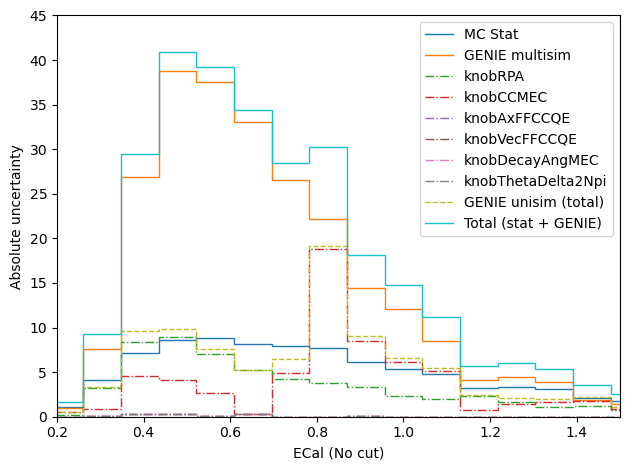


Using variable: ECal_pT04
bin counts: [  0.           0.           7.56024624  62.17995445 192.37204341
 272.54549965 266.46608518 232.83524346 192.5472012  144.37708158
  93.90812582  70.0243325   49.68936644  30.03602305  24.97165699
  18.18600771  11.67409652   7.08714288   6.69165141   1.80251393
   1.4670168    0.71318838   0.69297237]
MC stat absolute error: [1.68587394e-07 1.68587394e-07 1.11078522e+00 3.68865498e+00
 6.37308425e+00 7.80509822e+00 7.35103950e+00 6.94435638e+00
 6.84539024e+00 6.50214869e+00 5.22002270e+00 4.62823010e+00
 4.21083531e+00 2.77584579e+00 2.82931417e+00 2.33633155e+00
 1.59462846e+00 1.31668790e+00 2.08042019e+00 5.01729827e-01
 5.83450201e-01 3.20341405e-01 3.10124343e-01]

GENIE multisim absolute error: [ 0.          0.          0.99154372  6.31435244 21.34818195 29.94254211
 27.62666088 25.27123279 20.4046586  16.84140835 10.101635    9.04785448
  6.49139415  3.06572846  3.34832476  2.42926207  1.51790665  0.78056798
  1.19662531  0.21365717  0.2

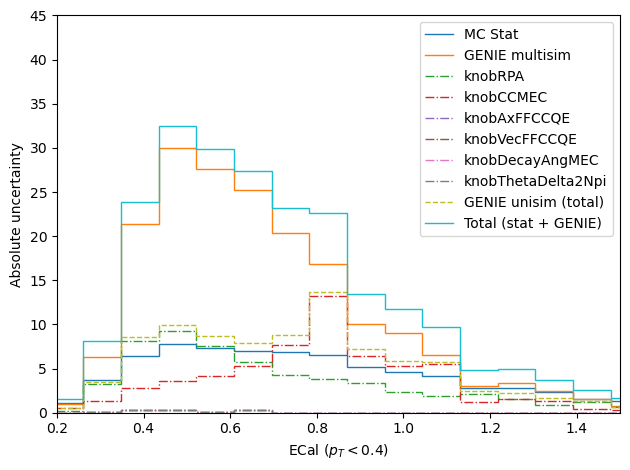


Using variable: ECal_pT03
bin counts: [  0.           0.           6.64497519  51.28392734 152.11523869
 220.74805629 218.64063045 192.04583597 162.98617599 120.60420983
  80.30229045  52.38091175  37.23606831  24.53545629  19.51480365
  15.92568784   9.71378994   5.9817277    5.38976839   1.5345338
   1.01263409   0.71318838   0.69297237]
MC stat absolute error: [1.19209290e-07 1.19209290e-07 1.05602523e+00 3.26233348e+00
 5.46211485e+00 6.84701040e+00 6.47355769e+00 5.90532528e+00
 6.07782172e+00 5.58906365e+00 4.48638537e+00 3.36262672e+00
 3.09432379e+00 2.04712920e+00 2.32774733e+00 2.12990505e+00
 1.22540492e+00 1.24368976e+00 1.86247523e+00 4.64555810e-01
 3.65992482e-01 3.20341405e-01 3.10124343e-01]

GENIE multisim absolute error: [ 0.          0.          0.87716038  4.95258639 15.85921444 23.60191653
 22.30506839 20.51184251 17.12579313 13.4905603   8.13347817  5.8666996
  4.00632732  2.41882146  2.40462245  2.02409136  1.15412756  0.68688693
  0.91589619  0.19540219  0.108

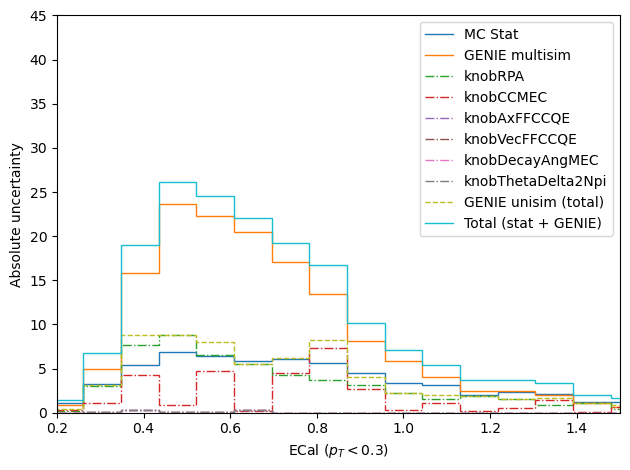


Using variable: ECal_pT02
bin counts: [  0.           0.           4.34163345  32.80097702  99.74777028
 150.64084883 151.94213258 136.72510196 113.93762127  84.76712216
  56.38761166  37.17611825  26.72334805  19.60450137  13.14913379
  10.85205567   5.50395533   5.4300172    4.67627372   0.67417582
   0.54593633   0.41665963   0.28012942]
MC stat absolute error: [8.42936970e-08 8.42936970e-08 8.13478172e-01 2.57763627e+00
 4.38495360e+00 5.59143135e+00 5.25140080e+00 4.92626073e+00
 4.91567020e+00 4.51748444e+00 3.57275223e+00 2.79026042e+00
 2.61515876e+00 1.80835548e+00 1.92098922e+00 1.75849099e+00
 8.82663444e-01 1.21251675e+00 1.83493058e+00 3.01595695e-01
 2.73412508e-01 2.40832538e-01 1.98277249e-01]

GENIE multisim absolute error: [ 0.          0.          0.72205396  2.78735372  9.61487798 15.34819575
 16.08941505 14.63508826 11.60181037  9.30992208  5.65563206  3.91221324
  2.78559465  2.06011773  1.73597177  1.51633639  0.62002262  0.64852443
  0.88091458  0.07749519  0.0

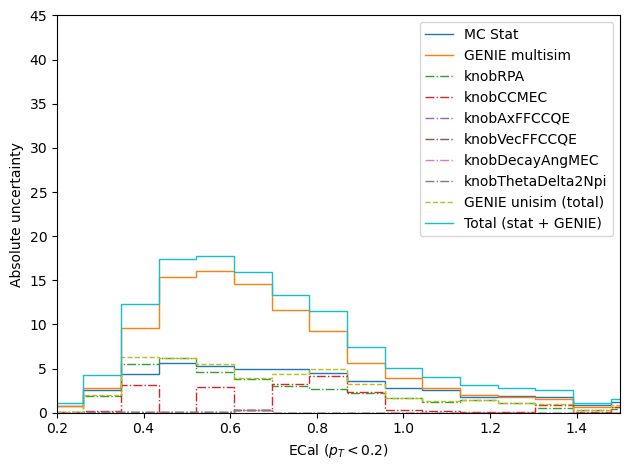

In [38]:
from microfit.statistics import covariance

edges = np.linspace(0.0, 1.0, 12)  # or your ECal edges, etc.

for var_name, var_edges, var_tex in my_vars:
    # Binning from ECal-like df column 
    binning = hist.Binning(
        variable=var_name,
        bin_edges=var_edges,
        label=var_name,
        variable_tex=var_tex,
    )
    print(f"\nUsing variable: {var_name}")

    # -----------------------
    # 1) MC stat only
    # -----------------------
    signal_generator_stat = hist.RunHistGenerator(
        rundata_stub,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        detvar_data=None,
        uncertainty_defaults=None,
    )

    total_prediction_stat = signal_generator_stat.get_total_prediction(
        include_multisim_errors=False,
        add_precomputed_detsys=False,
    )

    bin_counts = total_prediction_stat.bin_counts
    print("bin counts:", bin_counts)

    # For now keep flux normalization trivial
    IntegratedFlux = 1.0

    # If you later divide by flux, do it here and also for all covariances
    flux_norm_total_prediction_stat = total_prediction_stat / IntegratedFlux
    stat_cov = flux_norm_total_prediction_stat.covariance_matrix

    # --- absolute MC stat error (same units as bin_counts / IntegratedFlux) ---
    stat_error_abs = np.sqrt(np.diag(stat_cov))
    print("MC stat absolute error:", stat_error_abs)
    print()

    # -----------------------
    # 2) Multisim: GENIE
    # -----------------------
    signal_generator_multisim = hist.RunHistGenerator(
        rundata_stub,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
        detvar_data=None,
    )

    mc_hist_generator = signal_generator_multisim.mc_hist_generator

    # GENIE multisim covariance (same binning)
    genie_cov = mc_hist_generator.calculate_multisim_uncertainties(
        multisim_weight_column="weightsGenie"
    ) / IntegratedFlux**2

    # --- absolute GENIE multisim error ---
    genie_error_abs = np.sqrt(np.diag(genie_cov))
    print("GENIE multisim absolute error:", genie_error_abs)
    print()

    # -----------------------
    # 3) Unisim: total + per knob
    # -----------------------
    unisim_cov_total, unisim_hist_dict = mc_hist_generator.calculate_unisim_uncertainties(
        return_histograms=True,
        skip_covariance=False,   # so we also get the total covariance
    )

    # --- absolute GENIE unisim *total* error ---
    genie_unisim_total_abs = np.sqrt(np.diag(unisim_cov_total)) / IntegratedFlux
    print("GENIE unisim total absolute error:", genie_unisim_total_abs)
    print()

    # Central value histogram (same selection/binning) for per-knob cov
    central_hist = mc_hist_generator._histogram_multi_channel(mc_hist_generator.dataframe)
    cv_counts = central_hist.bin_counts  # same normalization as observations

    unisim_errors_per_knob_abs = {}
    for knob, observations in unisim_hist_dict.items():
        # observations shape: (n_universes, n_bins)
        cov_knob = covariance(
            observations,
            cv_counts,
            allow_approximation=True,
            tolerance=1e-8,
            debug_name=knob,
        ) / IntegratedFlux**2

        # --- absolute error per knob ---
        err_knob_abs = np.sqrt(np.diag(cov_knob))
        unisim_errors_per_knob_abs[knob] = err_knob_abs
        print(f"{knob} unisim absolute error:", err_knob_abs)

    # Optionally: total (stat + multisim + unisim-total) absolute error per bin
    total_abs_error = np.sqrt(
        stat_error_abs**2 + genie_error_abs**2 + genie_unisim_total_abs**2
    )
    print("Total absolute error (stat + GENIE multi + unisim-total):", total_abs_error)
    print()

    # -----------------------
    # 4) Plot absolute uncertainties
    # -----------------------
    fig, ax = plt.subplots()

    ax.stairs(stat_error_abs, var_edges, label="MC Stat")

    ax.stairs(
        genie_error_abs,
        var_edges,
        label="GENIE multisim",
    )

    # Example: only dominant knobs
    for knob in ["knobRPA", "knobCCMEC", "knobAxFFCCQE",
                 "knobVecFFCCQE", "knobDecayAngMEC", "knobThetaDelta2Npi"]:
        if knob in unisim_errors_per_knob_abs:
            ax.stairs(
                unisim_errors_per_knob_abs[knob],
                var_edges,
                label=knob,
                linestyle="dashdot",
            )

    # Plot total unisim if you want
    ax.stairs(
        genie_unisim_total_abs,
        var_edges,
        label="GENIE unisim (total)",
        linestyle="dashed",
    )

    # And / or total combined error
    ax.stairs(
        total_abs_error,
        var_edges,
        label="Total (stat + GENIE)",
        linestyle="solid",
    )

    ax.set_xlabel(var_tex)
    ax.set_ylabel("Absolute uncertainty")
    ax.legend(loc="best")
    ax.set_ylim(0, 45)
    ax.set_xlim(0.20, 1.50) 
    plt.tight_layout()
    plt.show()
    plt.close()


### ONLY MC STATS

(0.0, 2.0)

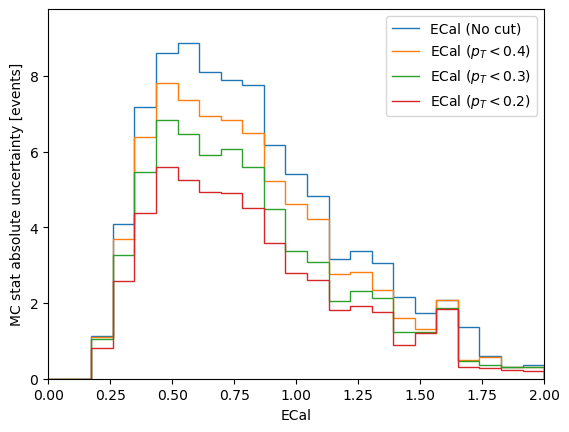

In [39]:
from microfit import histogram as hist
import numpy as np
import matplotlib.pyplot as plt

IntegratedFlux = 1.0  # keep as 1 for now

# my_vars already defined, e.g.:
# my_vars = [
#     ("ECal_all",  edges, r"ECal (No cut)"),
#     ("ECal_pT04", edges, r"ECal ($p_T<0.4$)"),
#     ("ECal_pT03", edges, r"ECal ($p_T<0.3$)"),
#     ("ECal_pT02", edges, r"ECal ($p_T<0.2$)"),
# ]

stat_errors_by_var = {}

for var_name, var_edges, var_tex in my_vars:
    binning = hist.Binning(
        variable=var_name,
        bin_edges=var_edges,
        label=var_name,
        variable_tex=var_tex,
    )

    # MC stat only
    signal_generator_stat = hist.RunHistGenerator(
        rundata_stub,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        detvar_data=None,
        uncertainty_defaults=None,
    )

    total_prediction_stat = signal_generator_stat.get_total_prediction(
        include_multisim_errors=False,
        add_precomputed_detsys=False,
    )

    bin_counts = total_prediction_stat.bin_counts

    # covariance in same units as bin_counts / IntegratedFlux
    flux_norm_total_prediction_stat = total_prediction_stat / IntegratedFlux
    stat_cov = flux_norm_total_prediction_stat.covariance_matrix

    # absolute MC stat error (events per bin)
    stat_error_abs = np.sqrt(np.diag(stat_cov))

    # store for joint plot
    stat_errors_by_var[var_name] = (var_edges, stat_error_abs, var_tex)

# -------------------------------------------------
# Single plot: MC stat error for all selections
# -------------------------------------------------
fig, ax = plt.subplots()

for var_name, (var_edges, stat_err_abs, var_tex) in stat_errors_by_var.items():
    ax.stairs(stat_err_abs, var_edges, label=var_tex)

ax.set_xlabel(r"ECal")  # or use something more specific if you like
ax.set_ylabel("MC stat absolute uncertainty [events]")
ax.legend(loc="best")

# nice y and x limits
max_err = max(np.nanmax(err) for _, err, _ in stat_errors_by_var.values())
ax.set_ylim(0, 1.1 * max_err)
ax.set_xlim(my_vars[0][1][0], my_vars[0][1][-1])  # assumes same_


## PER BIN Analysis

In [40]:
for col in ["is_signal", "mc_is_signal", "mc_is_cc0pi_signal", "mc_is_cc0pi_wc_signal"]:
    if col in mc.columns:
        vals = mc[col].value_counts(dropna=False)
        wsum = mc.loc[mc[col] == True, "weights"].sum()
        print(f"\nColumn: {col}")
        print(vals)
        print(f"  weighted sum for {col}==True: {wsum:.3f}")



Column: is_signal
False    1020773
Name: is_signal, dtype: int64
  weighted sum for is_signal==True: 0.000

Column: mc_is_signal
False    917078
True     103695
Name: mc_is_signal, dtype: int64
  weighted sum for mc_is_signal==True: 17483.929

Column: mc_is_cc0pi_signal
False    887237
True     133536
Name: mc_is_cc0pi_signal, dtype: int64
  weighted sum for mc_is_cc0pi_signal==True: 21780.861

Column: mc_is_cc0pi_wc_signal
False    880579
True     140194
Name: mc_is_cc0pi_wc_signal, dtype: int64
  weighted sum for mc_is_cc0pi_wc_signal==True: 22584.109


In [39]:
from microfit import selections as sel
import numpy as np

preselection = "sel_CCNp0pi"
selection    = "sel_CC1p0pi"

pre_q  = sel.preselection_categories[preselection]["query"]   # "sel_CCNp0pi"
sel_q  = sel.selection_categories[selection]["query"]         # "sel_CC1p0pi"
reco_q = f"({pre_q}) and ({sel_q})"

def wsum(df):
    return df["weights"].sum()

truth_defs = {
    "is_signal":              "is_signal == True",
    "mc_is_signal":           "mc_is_signal == True",
    "mc_is_cc1p0pi_signal":     "mc_is_cc1p0pi_signal == True",
    "mc_is_cc0pi_wc_signal":  "mc_is_cc0pi_wc_signal == True",
}

print(len(mc))
N_tot = wsum(mc)
print(f"Total MC (all): {N_tot:.3f}\n")

for label, signal_query in truth_defs.items():
    if label not in mc.columns:
        # (just skip missing ones, in case)
        pass
    
    sig_all   = mc.query(signal_query, engine="python")
    sel_all   = mc.query(reco_q,      engine="python")
    sel_sig   = mc.query(f"{signal_query} and {reco_q}", engine="python")

    N_sig_all = wsum(sig_all)
    N_sel_all = wsum(sel_all)
    N_sel_sig = wsum(sel_sig)

    eff  = N_sel_sig / N_sig_all if N_sig_all > 0 else np.nan
    pur  = N_sel_sig / N_sel_all if N_sel_all > 0 else np.nan
    rate = N_sel_all / N_tot      if N_tot    > 0 else np.nan

    print(f"=== Truth flag: {label} ===")
    print(f"  Truth signal (no reco cuts):    {N_sig_all:.3f}")
    print(f"  Reco selected (pre+sel):        {N_sel_all:.3f}")
    print(f"  Selected signal (truth+reco):   {N_sel_sig:.3f}")
    print(f"  Efficiency (truth → selected):  {eff*100:.2f} %")
    print(f"  Purity (selected signal frac):  {pur*100:.2f} %")
    print(f"  Rate vs all MC:                 {rate*100:.2f} %\n")


1020773
Total MC (all): 150147.136

=== Truth flag: is_signal ===
  Truth signal (no reco cuts):    0.000
  Reco selected (pre+sel):        2111.524
  Selected signal (truth+reco):   0.000
  Efficiency (truth → selected):  nan %
  Purity (selected signal frac):  0.00 %
  Rate vs all MC:                 1.41 %

=== Truth flag: mc_is_signal ===
  Truth signal (no reco cuts):    17483.929
  Reco selected (pre+sel):        2111.524
  Selected signal (truth+reco):   1544.104
  Efficiency (truth → selected):  8.83 %
  Purity (selected signal frac):  73.13 %
  Rate vs all MC:                 1.41 %

=== Truth flag: mc_is_cc1p0pi_signal ===
  Truth signal (no reco cuts):    11802.345
  Reco selected (pre+sel):        2111.524
  Selected signal (truth+reco):   1275.208
  Efficiency (truth → selected):  10.80 %
  Purity (selected signal frac):  60.39 %
  Rate vs all MC:                 1.41 %

=== Truth flag: mc_is_cc0pi_wc_signal ===
  Truth signal (no reco cuts):    22584.109
  Reco selected (

## FULL 2D SCAN FOR PURITY AND EFFICIENCY

In [41]:
import numpy as np
import pandas as pd
from microfit import histogram as hist

# ----------------------------------------------------
#  Fractional error from covariance
# ----------------------------------------------------
def fractional_error_from_cov(cov, central):
    """
    cov: (nbins, nbins) covariance matrix
    central: (nbins,) central bin contents (same normalization as cov)
    returns: (nbins,) fractional uncertainties (sigma / central)
    """
    central = np.asarray(central)
    diag = np.diag(cov)
    frac = np.zeros_like(central, dtype=float)
    mask = central > 0
    frac[mask] = np.sqrt(diag[mask]) / central[mask]
    return frac


# ----------------------------------------------------
# Selection definitions 
# ----------------------------------------------------
preselection = "sel_CCNp0pi"
selection    = "sel_CC1p0pi"

pre_q  = sel.preselection_categories[preselection]["query"]
sel_q  = sel.selection_categories[selection]["query"]
base_reco_q = f"({pre_q}) and ({sel_q})"

def wsum(df):
    return df["weights"].sum()

truth_label = "mc_is_cc1p0pi_signal"      # QE-like truth you care about
truth_q     = truth_defs[truth_label]

N_tot    = wsum(mc)
sig_all  = mc.query(truth_q, engine="python")
N_sig_all = wsum(sig_all)

print(f"Total MC (all): {N_tot:.3f}")
print(f"Total {truth_label} truth events: {N_sig_all:.3f}")

# ----------------------------------------------------
# Scan grids for Delta-pT and pN
# ----------------------------------------------------
dpT_max_values = np.linspace(0,1.2,10)#[0.4, 0.3, 0.2]      # GeV
pN_max_values  = np.linspace(0,1.2,10)#[0.8, 0.6, 0.4]      # GeV

# Ecal binning & region where you care about GENIE error
edges = np.linspace(0.0, 2.0, 24)
Ecal_min, Ecal_max = 0.2, 1.5
bin_mask = (edges[:-1] >= Ecal_min) & (edges[1:] <= Ecal_max)

# Make sure ECal_all exists in rundata
for k, df in rundata.items():
    if df is None:
        continue
    if "ECal_all" not in df.columns:
        df["ECal_all"] = df["Ecal"]

scan_rows = []

# ----------------------------------------------------
#  Main scan loop
# ----------------------------------------------------
for dpT_max in dpT_max_values:
    for pN_max in pN_max_values:

        #Define a new Ecal variable name for this cut combo
        col_name = f"ECal_dpT{dpT_max:.2f}_pN{pN_max:.2f}".replace(".", "p")
        print(f"\n=== Scanning ΔpT < {dpT_max:.2f}, pN < {pN_max:.2f} (var = {col_name}) ===")

        # Fill this column in rundata:
        #      - = NaN outside TKI cuts
        #      - = ECal_all inside TKI cuts
        for k, df in rundata.items():
            if df is None:
                continue
            # ensure delta_pT and pn exist in df;
            mask = (df["delta_pT"] < dpT_max) & (df["pn"] < pN_max)
            df[col_name] = np.nan
            df.loc[mask, col_name] = df.loc[mask, "ECal_all"]

        # Build binning and RunHistGenerator for this variable
        binning = hist.Binning(
            variable=col_name,
            bin_edges=edges,
            label=col_name,
            variable_tex=fr"ECal ($\Delta p_T<{dpT_max}$, p_N<{pN_max}$)",
        )

        run_hist_gen = hist.RunHistGenerator(
            rundata_stub,          # or 'rundata' if that's what you use
            binning.copy(),
            data_pot=data_pot,
            selection=selection,
            preselection=preselection,
            detvar_data=None,
            uncertainty_defaults=None,
        )

        # Stat-only prediction
        total_prediction_stat = run_hist_gen.get_total_prediction(
            include_multisim_errors=False,
            add_precomputed_detsys=False,
        )
        bin_counts = total_prediction_stat.bin_counts
        stat_cov   = total_prediction_stat.covariance_matrix
        stat_error_frac = fractional_error_from_cov(stat_cov, bin_counts)

        # GENIE multisim + unisim (MC only)
        mc_hist_generator = run_hist_gen.mc_hist_generator

        genie_cov = mc_hist_generator.calculate_multisim_uncertainties(
            multisim_weight_column="weightsGenie"
        )
        genie_error_frac = fractional_error_from_cov(genie_cov, bin_counts)

        genie_unisim_cov = mc_hist_generator.calculate_unisim_uncertainties()
        genie_unisim_error_frac = fractional_error_from_cov(genie_unisim_cov, bin_counts)

        genie_total_frac = np.sqrt(genie_error_frac**2 + genie_unisim_error_frac**2)
        total_frac       = np.sqrt(stat_error_frac**2 + genie_total_frac**2)

        # Average fractional errors in the Ecal region of interest
        avg_genie_frac = np.mean(genie_total_frac[bin_mask])
        avg_total_frac = np.mean(total_frac[bin_mask])

        # ------------------------------------------------
        # Efficiency & purity for this TKI cut combo
        # ------------------------------------------------
        reco_q = f"({base_reco_q}) and (delta_pT < {dpT_max}) and (pn < {pN_max})"

        sel_all = mc.query(reco_q, engine="python")
        sel_sig = mc.query(f"{truth_q} and ({reco_q})", engine="python")

        N_sel_all = wsum(sel_all)
        N_sel_sig = wsum(sel_sig)

        eff  = N_sel_sig / N_sig_all if N_sig_all > 0 else np.nan
        pur  = N_sel_sig / N_sel_all if N_sel_all > 0 else np.nan
        rate = N_sel_all / N_tot      if N_tot    > 0 else np.nan

        # ------------------------------------------------
        # Simple "sensitivity" FOM including systematics
        #      (very rough, but good to compare points)
        # ------------------------------------------------
        S = N_sel_sig
        B = max(N_sel_all - N_sel_sig, 0.0)
        T = S + B
        if T > 0:
            sigma_tot = np.sqrt(T + (avg_total_frac * T)**2)
            FOM = S / sigma_tot if sigma_tot > 0 else np.nan
        else:
            FOM = np.nan

        scan_rows.append({
            "dpT_max": dpT_max,
            "pN_max": pN_max,
            "N_sel_all": N_sel_all,
            "N_sel_sig": N_sel_sig,
            "eff_%": eff * 100.0,
            "pur_%": pur * 100.0,
            "rate_%": rate * 100.0,
            "avg_GENIE_frac": avg_genie_frac,
            "avg_total_frac": avg_total_frac,
            "FOM": FOM,
        })

# ----------------------------------------------------
# Collect and inspect results
# ----------------------------------------------------
scan_df = pd.DataFrame(scan_rows)

print("\nScan results sorted by FOM (best first):")
print(scan_df.sort_values("FOM", ascending=False))

# If you want to see just eff/pur vs cuts:
print("\nCompact view (eff, pur, GENIE):")
print(
    scan_df[["dpT_max", "pN_max", "eff_%", "pur_%", "avg_GENIE_frac", "FOM"]]
    .sort_values("FOM", ascending=False)
)


Total MC (all): 150147.136
Total mc_is_cc1p0pi_signal truth events: 11802.345

=== Scanning ΔpT < 0.00, pN < 0.00 (var = ECal_dpT0p00_pN0p00) ===

=== Scanning ΔpT < 0.00, pN < 0.13 (var = ECal_dpT0p00_pN0p13) ===

=== Scanning ΔpT < 0.00, pN < 0.27 (var = ECal_dpT0p00_pN0p27) ===

=== Scanning ΔpT < 0.00, pN < 0.40 (var = ECal_dpT0p00_pN0p40) ===

=== Scanning ΔpT < 0.00, pN < 0.53 (var = ECal_dpT0p00_pN0p53) ===

=== Scanning ΔpT < 0.00, pN < 0.67 (var = ECal_dpT0p00_pN0p67) ===

=== Scanning ΔpT < 0.00, pN < 0.80 (var = ECal_dpT0p00_pN0p80) ===

=== Scanning ΔpT < 0.00, pN < 0.93 (var = ECal_dpT0p00_pN0p93) ===

=== Scanning ΔpT < 0.00, pN < 1.07 (var = ECal_dpT0p00_pN1p07) ===

=== Scanning ΔpT < 0.00, pN < 1.20 (var = ECal_dpT0p00_pN1p20) ===

=== Scanning ΔpT < 0.13, pN < 0.00 (var = ECal_dpT0p13_pN0p00) ===

=== Scanning ΔpT < 0.13, pN < 0.13 (var = ECal_dpT0p13_pN0p13) ===

=== Scanning ΔpT < 0.13, pN < 0.27 (var = ECal_dpT0p13_pN0p27) ===

=== Scanning ΔpT < 0.13, pN < 0.40 (v

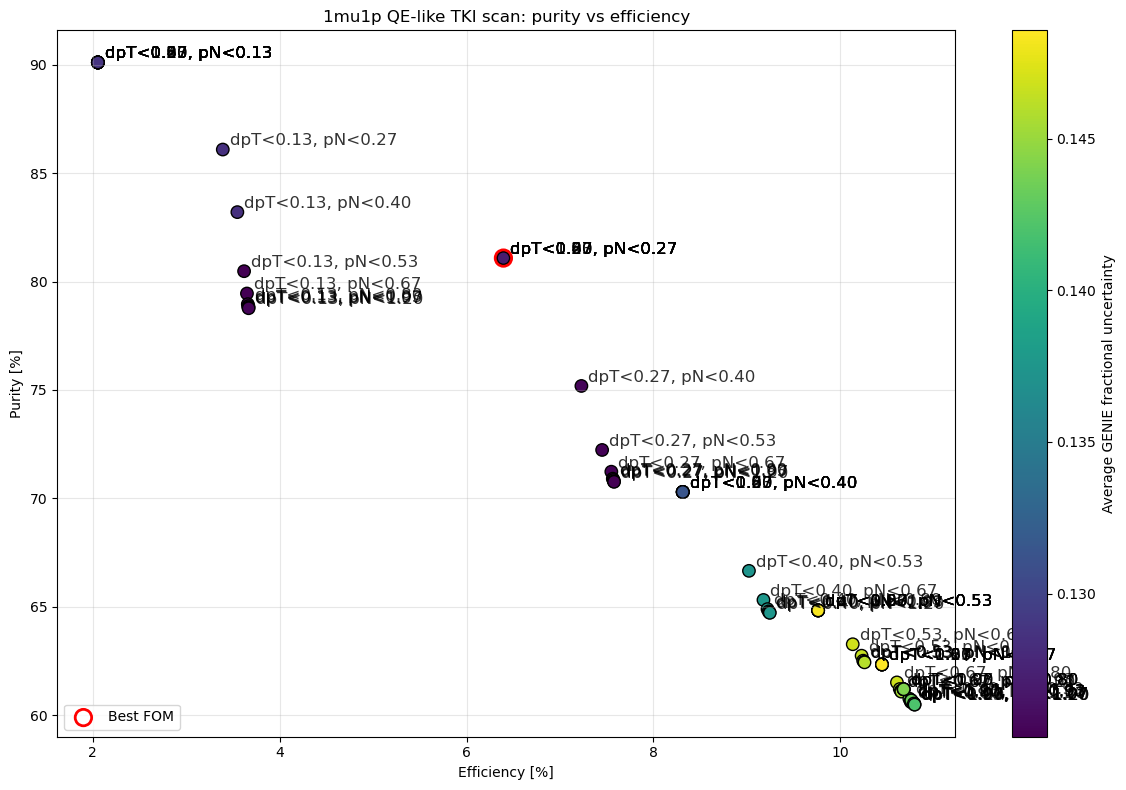

In [41]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))

sc = ax.scatter(
    scan_df["eff_%"],
    scan_df["pur_%"],
    c=scan_df["avg_GENIE_frac"],   # color = GENIE fractional error
    s=80,
    cmap="viridis",
    edgecolors="k"
)

# Label a few key points (optional: best FOM + maybe 1–2 others)
best_idx = scan_df["FOM"].idxmax()
best_row = scan_df.loc[best_idx]

ax.scatter(
    best_row["eff_%"],
    best_row["pur_%"],
    s=140,
    facecolors="none",
    edgecolors="red",
    linewidths=2,
    label="Best FOM"
)

for _, row in scan_df.iterrows():
    #label = f"dpT<{row['dpT_max']}, pN<{row['pN_max']}"
    label = f"dpT<{row['dpT_max']:.2f}, pN<{row['pN_max']:.2f}"
    ax.annotate(
        label,
        (row["eff_%"], row["pur_%"]),
        textcoords="offset points",
        xytext=(5, 3),
        fontsize=12,
        alpha=0.8
    )

cb = plt.colorbar(sc)
cb.set_label("Average GENIE fractional uncertainty")

ax.set_xlabel("Efficiency [%]")
ax.set_ylabel("Purity [%]")
ax.set_title("1mu1p QE-like TKI scan: purity vs efficiency")

ax.grid(alpha=0.3)
ax.legend(loc="lower left")

plt.tight_layout()
plt.show()


Baseline (no TKI cuts) avg GENIE frac = 0.1283
Baseline (no TKI cuts) avg TOTAL frac = 0.1364
Baseline efficiency (no TKI cuts): 10.80 %
Baseline purity     (no TKI cuts): 60.39 %


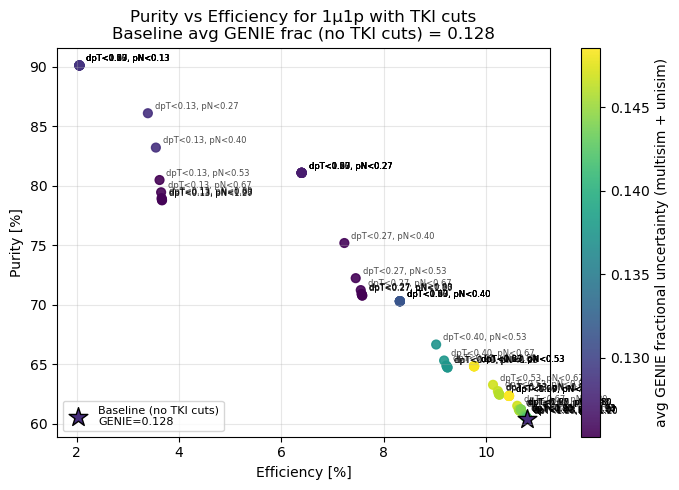

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from microfit import histogram as hist

# -------------------------
# Baseline GENIE error (ECal_all, no TKI cuts)
# -------------------------

# Define the binning for ECal_all (same edges you used in the scan)
binning_base = hist.Binning(
    variable="ECal_all",
    bin_edges=edges,
    label="ECal_all",
    variable_tex=r"ECal (no TKI cuts)",
)

# Build RunHistGenerator for baseline
run_hist_gen_base = hist.RunHistGenerator(
    rundata_stub,
    binning_base.copy(),
    data_pot=data_pot,
    selection=selection,
    preselection=preselection,
    detvar_data=None,
    uncertainty_defaults=None,
)

# Stat-only total prediction
total_prediction_base = run_hist_gen_base.get_total_prediction(
    include_multisim_errors=False,
    add_precomputed_detsys=False,
)

bin_counts_base = total_prediction_base.bin_counts
stat_cov_base   = total_prediction_base.covariance_matrix
stat_err_frac_base = fractional_error_from_cov(stat_cov_base, bin_counts_base)

# GENIE multisim + unisim (MC only)
mc_hist_gen_base = run_hist_gen_base.mc_hist_generator

genie_cov_base = mc_hist_gen_base.calculate_multisim_uncertainties(
    multisim_weight_column="weightsGenie"
)
genie_err_frac_base = fractional_error_from_cov(genie_cov_base, bin_counts_base)

genie_unisim_cov_base = mc_hist_gen_base.calculate_unisim_uncertainties()
genie_unisim_err_frac_base = fractional_error_from_cov(genie_unisim_cov_base, bin_counts_base)

# Total GENIE frac error per bin
genie_total_err_frac_base = np.sqrt(
    genie_err_frac_base**2 + genie_unisim_err_frac_base**2
)

# Total (stat + GENIE) per bin
total_frac_err_base = np.sqrt(
    stat_err_frac_base**2 + genie_total_err_frac_base**2
)

# Weighted averages over non-empty bins (same definition as in the scan)
mask_nonzero = bin_counts_base > 0
avg_GENIE_frac_base = np.average(
    genie_total_err_frac_base[mask_nonzero],
    weights=bin_counts_base[mask_nonzero],
)
avg_total_frac_base = np.average(
    total_frac_err_base[mask_nonzero],
    weights=bin_counts_base[mask_nonzero],
)

print(f"Baseline (no TKI cuts) avg GENIE frac = {avg_GENIE_frac_base:.4f}")
print(f"Baseline (no TKI cuts) avg TOTAL frac = {avg_total_frac_base:.4f}")

# -------------------------
# Baseline efficiency & purity (no TKI cuts)
# -------------------------

truth_label = "mc_is_cc1p0pi_signal"
truth_q     = truth_defs[truth_label]

# Total signal truth
sig_all_base = mc.query(truth_q, engine="python")
N_sig_all    = wsum(sig_all_base)   # same denominator for all points

# Reco selection WITHOUT TKI cuts
reco_q_base   = f"({pre_q}) and ({sel_q})"
sel_all_base  = mc.query(reco_q_base, engine="python")
sel_sig_base  = mc.query(f"{truth_q} and {reco_q_base}", engine="python")

N_sel_all_base = wsum(sel_all_base)
N_sel_sig_base = wsum(sel_sig_base)

eff_base = 100.0 * N_sel_sig_base / N_sig_all
pur_base = 100.0 * N_sel_sig_base / N_sel_all_base

print(f"Baseline efficiency (no TKI cuts): {eff_base:.2f} %")
print(f"Baseline purity     (no TKI cuts): {pur_base:.2f} %")

# -------------------------
# Plot purity vs efficiency, color = avg_GENIE_frac
#    + baseline point as a star
# -------------------------

fig, ax = plt.subplots(figsize=(7, 5))

# Only keep finite FOM / meaningful points if you like
scan_to_plot = scan_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["avg_GENIE_frac"])

sc = ax.scatter(
    scan_to_plot["eff_%"],
    scan_to_plot["pur_%"],
    c=scan_to_plot["avg_GENIE_frac"],
    cmap="viridis",
    s=40,
    alpha=0.9,
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("avg GENIE fractional uncertainty (multisim + unisim)")

# Annotate points with dpT, pN using .2f
for _, row in scan_to_plot.iterrows():
    label = f"dpT<{row['dpT_max']:.2f}, pN<{row['pN_max']:.2f}"
    ax.annotate(
        label,
        (row["eff_%"], row["pur_%"]),
        textcoords="offset points",
        xytext=(5, 3),
        fontsize=6,
        alpha=0.7,
    )

# Plot the baseline point (no TKI cuts) as a big star, colored by its GENIE frac
baseline_color = sc.cmap(sc.norm(avg_GENIE_frac_base))

ax.scatter(
    eff_base,
    pur_base,
    marker="*",
    s=200,
    edgecolor="k",
    facecolor=baseline_color,
    label=f"Baseline (no TKI cuts)\nGENIE={avg_GENIE_frac_base:.3f}",
)

ax.set_xlabel("Efficiency [%]")
ax.set_ylabel("Purity [%]")

ax.set_title(
    "Purity vs Efficiency for 1µ1p with TKI cuts\n"
    f"Baseline avg GENIE frac (no TKI cuts) = {avg_GENIE_frac_base:.3f}"
)

ax.grid(alpha=0.3)
ax.legend(loc="lower left", fontsize=8)

plt.tight_layout()
plt.show()


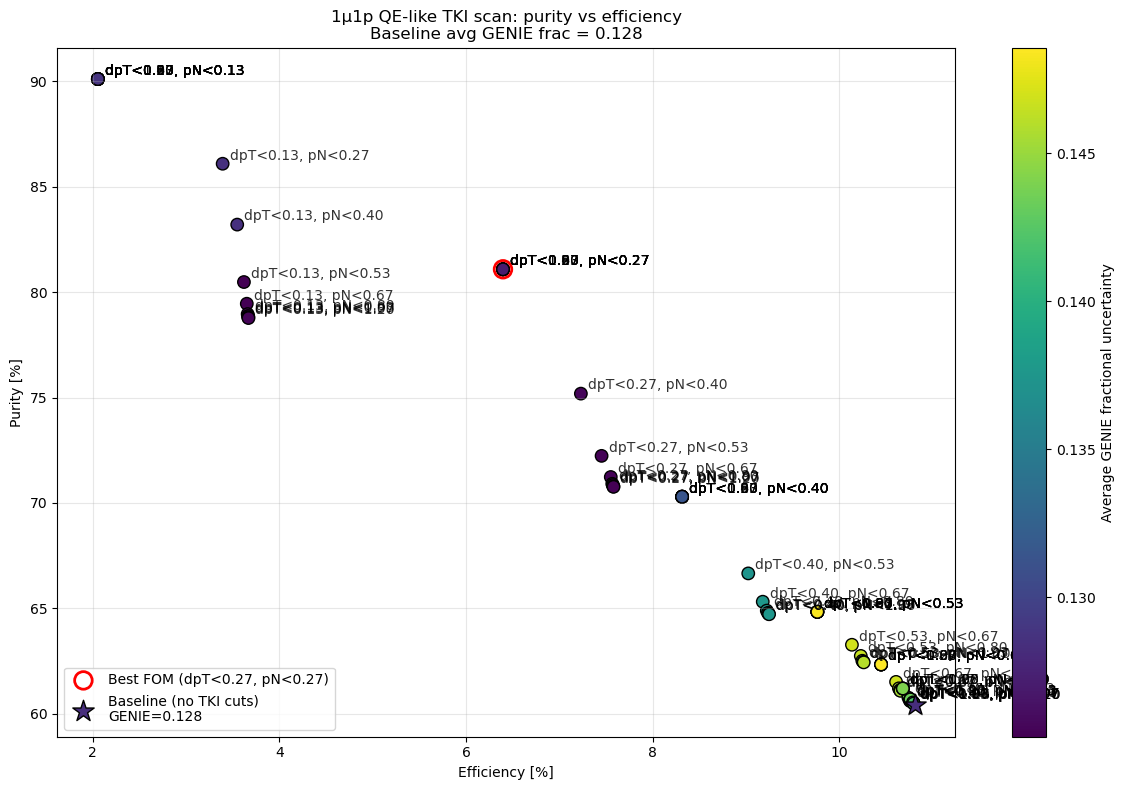

In [43]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 8))

# Main scatter: all TKI working points
sc = ax.scatter(
    scan_df["eff_%"],
    scan_df["pur_%"],
    c=scan_df["avg_GENIE_frac"],   # color = GENIE fractional error
    s=80,
    cmap="viridis",
    edgecolors="k"
)

# Highlight best FOM point
best_idx = scan_df["FOM"].idxmax()
best_row = scan_df.loc[best_idx]

ax.scatter(
    best_row["eff_%"],
    best_row["pur_%"],
    s=160,
    facecolors="none",
    edgecolors="red",
    linewidths=2,
    label=f"Best FOM (dpT<{best_row['dpT_max']:.2f}, pN<{best_row['pN_max']:.2f})"
)

# --- Baseline (no TKI cuts) point ---
# Color it according to the same GENIE scale as other points
baseline_color = sc.cmap(sc.norm(avg_GENIE_frac_base))

ax.scatter(
    eff_base,
    pur_base,
    marker="*",
    s=260,
    edgecolors="black",
    facecolors=baseline_color,
    label=f"Baseline (no TKI cuts)\nGENIE={avg_GENIE_frac_base:.3f}"
)

# Labels for all scan points (with .2f formatting)
for _, row in scan_df.iterrows():
    label = f"dpT<{row['dpT_max']:.2f}, pN<{row['pN_max']:.2f}"
    ax.annotate(
        label,
        (row["eff_%"], row["pur_%"]),
        textcoords="offset points",
        xytext=(5, 3),
        fontsize=10,
        alpha=0.8
    )

# Colorbar for GENIE fractional uncertainty
cb = plt.colorbar(sc)
cb.set_label("Average GENIE fractional uncertainty")

ax.set_xlabel("Efficiency [%]")
ax.set_ylabel("Purity [%]")
ax.set_title(
    "1µ1p QE-like TKI scan: purity vs efficiency\n"
    f"Baseline avg GENIE frac = {avg_GENIE_frac_base:.3f}"
)

ax.grid(alpha=0.3)
ax.legend(loc="lower left", fontsize=10)

plt.tight_layout()
plt.show()


## Delta_pT and pN

In [44]:
import numpy as np
import pandas as pd
from microfit import histogram as hist

# ---------- helper (same as before) ----------
def fractional_error_from_cov(cov, central):
    central = np.asarray(central)
    diag = np.diag(cov)
    frac = np.zeros_like(central, dtype=float)
    mask = central > 0
    frac[mask] = np.sqrt(diag[mask]) / central[mask]
    return frac


# ---------- basic definitions ----------
preselection = "sel_CCNp0pi"
selection    = "sel_CC1p0pi"

pre_q  = sel.preselection_categories[preselection]["query"]
sel_q  = sel.selection_categories[selection]["query"]
base_reco_q = f"({pre_q}) and ({sel_q})"

def wsum(df):
    return df["weights"].sum()

truth_label = "mc_is_cc1p0pi_signal"
truth_q     = truth_defs[truth_label]

N_tot     = wsum(mc)
sig_all   = mc.query(truth_q, engine="python")
N_sig_all = wsum(sig_all)

print(f"Total MC (all): {N_tot:.3f}")
print(f"Total {truth_label} truth events: {N_sig_all:.3f}")


# ---------- ECal binning for systematics ----------
edges = np.linspace(0.0, 2.0, 24)
Ecal_min, Ecal_max = 0.2, 1.5
bin_mask = (edges[:-1] >= Ecal_min) & (edges[1:] <= Ecal_max)

# Make sure ECal_all exists
for k, df in rundata.items():
    if df is None:
        continue
    if "ECal_all" not in df.columns:
        df["ECal_all"] = df["Ecal"]


# ====================================================
#  A) ΔpT-only scan
# ====================================================
dpT_max_values = np.linspace(0.0, 1.2, 10)
dpT_scan_rows = []

for dpT_max in dpT_max_values:

    col_name = f"ECal_dpT{dpT_max:.2f}".replace(".", "p")
    print(f"\n=== ΔpT scan: ΔpT < {dpT_max:.2f} (var = {col_name}) ===")

    # fill new ECal column: only ΔpT cut, NO pN cut
    for k, df in rundata.items():
        if df is None:
            continue
        mask = (df["delta_pT"] < dpT_max)
        df[col_name] = np.nan
        df.loc[mask, col_name] = df.loc[mask, "ECal_all"]

    # histogram setup
    binning = hist.Binning(
        variable=col_name,
        bin_edges=edges,
        label=col_name,
        variable_tex=fr"ECal ($\Delta p_T<{dpT_max:.2f}$)",
    )

    run_hist_gen = hist.RunHistGenerator(
        rundata_stub,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        detvar_data=None,
        uncertainty_defaults=None,
    )

    # stat-only prediction
    total_prediction_stat = run_hist_gen.get_total_prediction(
        include_multisim_errors=False,
        add_precomputed_detsys=False,
    )
    bin_counts = total_prediction_stat.bin_counts
    stat_cov   = total_prediction_stat.covariance_matrix
    stat_frac  = fractional_error_from_cov(stat_cov, bin_counts)

    # GENIE multisim + unisim
    mc_hist_generator = run_hist_gen.mc_hist_generator

    genie_cov   = mc_hist_generator.calculate_multisim_uncertainties(
        multisim_weight_column="weightsGenie"
    )
    genie_frac  = fractional_error_from_cov(genie_cov, bin_counts)

    genie_uni_cov  = mc_hist_generator.calculate_unisim_uncertainties()
    genie_uni_frac = fractional_error_from_cov(genie_uni_cov, bin_counts)

    genie_tot_frac = np.sqrt(genie_frac**2 + genie_uni_frac**2)
    total_frac     = np.sqrt(stat_frac**2 + genie_tot_frac**2)

    # average systematics in ECal window
    avg_genie_frac = np.mean(genie_tot_frac[bin_mask])
    avg_total_frac = np.mean(total_frac[bin_mask])

    # efficiency & purity for ΔpT<dpT_max
    reco_q = f"({base_reco_q}) and (delta_pT < {dpT_max})"

    sel_all = mc.query(reco_q, engine="python")
    sel_sig = mc.query(f"{truth_q} and ({reco_q})", engine="python")

    N_sel_all = wsum(sel_all)
    N_sel_sig = wsum(sel_sig)

    eff  = N_sel_sig / N_sig_all if N_sig_all > 0 else np.nan
    pur  = N_sel_sig / N_sel_all if N_sel_all > 0 else np.nan
    rate = N_sel_all / N_tot      if N_tot    > 0 else np.nan

    # FOM with systematics
    S = N_sel_sig
    B = max(N_sel_all - N_sel_sig, 0.0)
    T = S + B
    if T > 0:
        sigma_tot = np.sqrt(T + (avg_total_frac * T)**2)
        FOM = S / sigma_tot if sigma_tot > 0 else np.nan
    else:
        FOM = np.nan

    dpT_scan_rows.append({
        "dpT_max": dpT_max,
        "N_sel_all": N_sel_all,
        "N_sel_sig": N_sel_sig,
        "eff_%": eff * 100.0,
        "pur_%": pur * 100.0,
        "rate_%": rate * 100.0,
        "avg_GENIE_frac": avg_genie_frac,
        "avg_total_frac": avg_total_frac,
        "FOM": FOM,
    })

dpT_scan_df = pd.DataFrame(dpT_scan_rows)


# ====================================================
#  B) pN-only scan
# ====================================================
pN_max_values = np.linspace(0.0, 1.2, 10)
pN_scan_rows = []

for pN_max in pN_max_values:

    col_name = f"ECal_pN{pN_max:.2f}".replace(".", "p")
    print(f"\n=== pN scan: pN < {pN_max:.2f} (var = {col_name}) ===")

    # fill new ECal column: only pN cut, NO ΔpT cut
    for k, df in rundata.items():
        if df is None:
            continue
        mask = (df["pn"] < pN_max)
        df[col_name] = np.nan
        df.loc[mask, col_name] = df.loc[mask, "ECal_all"]

    binning = hist.Binning(
        variable=col_name,
        bin_edges=edges,
        label=col_name,
        variable_tex=fr"ECal ($p_N<{pN_max:.2f}$)",
    )

    run_hist_gen = hist.RunHistGenerator(
        rundata_stub,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        detvar_data=None,
        uncertainty_defaults=None,
    )

    total_prediction_stat = run_hist_gen.get_total_prediction(
        include_multisim_errors=False,
        add_precomputed_detsys=False,
    )
    bin_counts = total_prediction_stat.bin_counts
    stat_cov   = total_prediction_stat.covariance_matrix
    stat_frac  = fractional_error_from_cov(stat_cov, bin_counts)

    mc_hist_generator = run_hist_gen.mc_hist_generator

    genie_cov   = mc_hist_generator.calculate_multisim_uncertainties(
        multisim_weight_column="weightsGenie"
    )
    genie_frac  = fractional_error_from_cov(genie_cov, bin_counts)

    genie_uni_cov  = mc_hist_generator.calculate_unisim_uncertainties()
    genie_uni_frac = fractional_error_from_cov(genie_uni_cov, bin_counts)

    genie_tot_frac = np.sqrt(genie_frac**2 + genie_uni_frac**2)
    total_frac     = np.sqrt(stat_frac**2 + genie_tot_frac**2)

    avg_genie_frac = np.mean(genie_tot_frac[bin_mask])
    avg_total_frac = np.mean(total_frac[bin_mask])

    reco_q = f"({base_reco_q}) and (pn < {pN_max})"

    sel_all = mc.query(reco_q, engine="python")
    sel_sig = mc.query(f"{truth_q} and ({reco_q})", engine="python")

    N_sel_all = wsum(sel_all)
    N_sel_sig = wsum(sel_sig)

    eff  = N_sel_sig / N_sig_all if N_sig_all > 0 else np.nan
    pur  = N_sel_sig / N_sel_all if N_sel_all > 0 else np.nan
    rate = N_sel_all / N_tot      if N_tot    > 0 else np.nan

    S = N_sel_sig
    B = max(N_sel_all - N_sel_sig, 0.0)
    T = S + B
    if T > 0:
        sigma_tot = np.sqrt(T + (avg_total_frac * T)**2)
        FOM = S / sigma_tot if sigma_tot > 0 else np.nan
    else:
        FOM = np.nan

    pN_scan_rows.append({
        "pN_max": pN_max,
        "N_sel_all": N_sel_all,
        "N_sel_sig": N_sel_sig,
        "eff_%": eff * 100.0,
        "pur_%": pur * 100.0,
        "rate_%": rate * 100.0,
        "avg_GENIE_frac": avg_genie_frac,
        "avg_total_frac": avg_total_frac,
        "FOM": FOM,
    })

pN_scan_df = pd.DataFrame(pN_scan_rows)


Total MC (all): 150147.136
Total mc_is_cc1p0pi_signal truth events: 11802.345

=== ΔpT scan: ΔpT < 0.00 (var = ECal_dpT0p00) ===

=== ΔpT scan: ΔpT < 0.13 (var = ECal_dpT0p13) ===

=== ΔpT scan: ΔpT < 0.27 (var = ECal_dpT0p27) ===

=== ΔpT scan: ΔpT < 0.40 (var = ECal_dpT0p40) ===

=== ΔpT scan: ΔpT < 0.53 (var = ECal_dpT0p53) ===

=== ΔpT scan: ΔpT < 0.67 (var = ECal_dpT0p67) ===

=== ΔpT scan: ΔpT < 0.80 (var = ECal_dpT0p80) ===

=== ΔpT scan: ΔpT < 0.93 (var = ECal_dpT0p93) ===

=== ΔpT scan: ΔpT < 1.07 (var = ECal_dpT1p07) ===

=== ΔpT scan: ΔpT < 1.20 (var = ECal_dpT1p20) ===

=== pN scan: pN < 0.00 (var = ECal_pN0p00) ===

=== pN scan: pN < 0.13 (var = ECal_pN0p13) ===

=== pN scan: pN < 0.27 (var = ECal_pN0p27) ===

=== pN scan: pN < 0.40 (var = ECal_pN0p40) ===

=== pN scan: pN < 0.53 (var = ECal_pN0p53) ===

=== pN scan: pN < 0.67 (var = ECal_pN0p67) ===

=== pN scan: pN < 0.80 (var = ECal_pN0p80) ===

=== pN scan: pN < 0.93 (var = ECal_pN0p93) ===

=== pN scan: pN < 1.07 (var

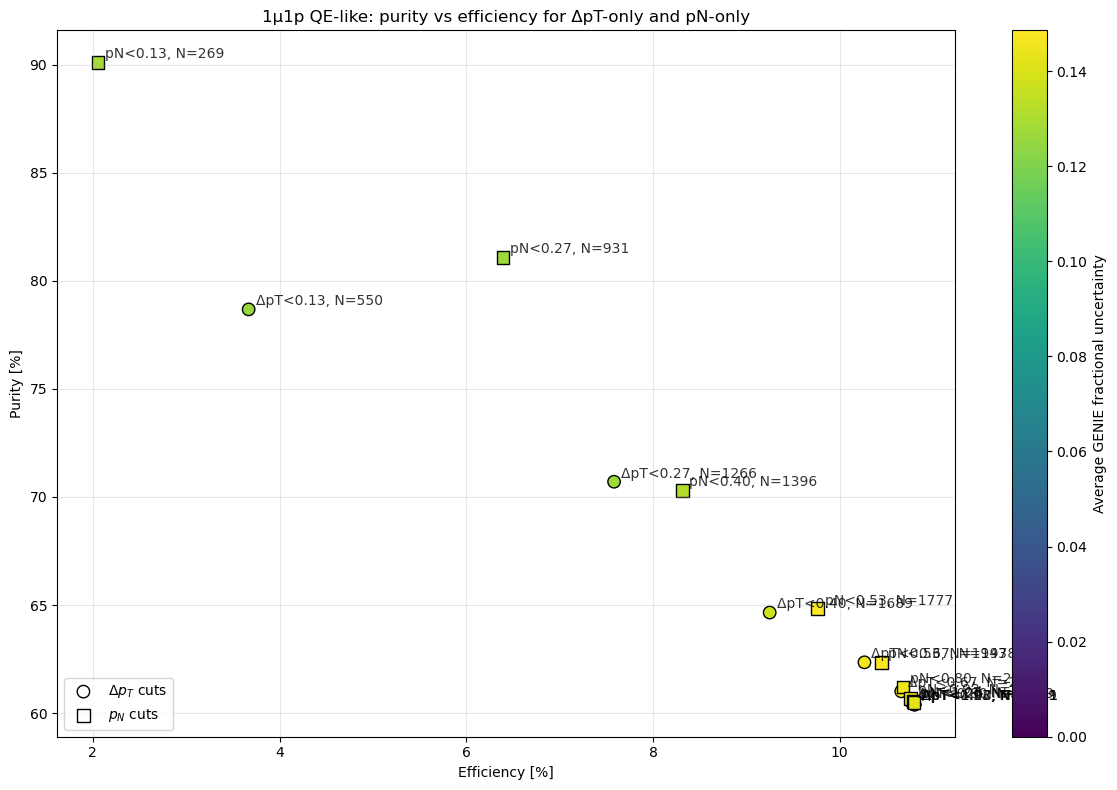

In [45]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))

# common color scale based on both scans
vmin = min(dpT_scan_df["avg_GENIE_frac"].min(),
           pN_scan_df["avg_GENIE_frac"].min())
vmax = max(dpT_scan_df["avg_GENIE_frac"].max(),
           pN_scan_df["avg_GENIE_frac"].max())

# ΔpT series (circles)
sc_dpT = ax.scatter(
    dpT_scan_df["eff_%"],
    dpT_scan_df["pur_%"],
    c=dpT_scan_df["avg_GENIE_frac"],
    s=80,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    edgecolors="k",
    marker="o",
    label=r"$\Delta p_T$ cuts"
)

for _, row in dpT_scan_df.iterrows():
    label = fr"ΔpT<{row['dpT_max']:.2f}, N={row['N_sel_all']:.0f}"
    ax.annotate(
        label,
        (row["eff_%"], row["pur_%"]),
        textcoords="offset points",
        xytext=(5, 3),
        fontsize=10,
        alpha=0.8
    )

# pN series (squares)
sc_pN = ax.scatter(
    pN_scan_df["eff_%"],
    pN_scan_df["pur_%"],
    c=pN_scan_df["avg_GENIE_frac"],
    s=80,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    edgecolors="k",
    marker="s",
    label=r"$p_N$ cuts"
)

for _, row in pN_scan_df.iterrows():
    label = fr"pN<{row['pN_max']:.2f}, N={row['N_sel_all']:.0f}"
    ax.annotate(
        label,
        (row["eff_%"], row["pur_%"]),
        textcoords="offset points",
        xytext=(5, 3),
        fontsize=10,
        alpha=0.8
    )

# Colorbar (GENIE error)
cb = plt.colorbar(sc_dpT)
cb.set_label("Average GENIE fractional uncertainty")

ax.set_xlabel("Efficiency [%]")
ax.set_ylabel("Purity [%]")
ax.set_title("1μ1p QE-like: purity vs efficiency for ΔpT-only and pN-only")
#ax.set_xlim(8,11)

ax.grid(alpha=0.3)
ax.legend(loc="lower left")

plt.tight_layout()
plt.show()


## pN and Delta_alphaT

In [46]:
import numpy as np
import pandas as pd
from microfit import histogram as hist

# ---------- helper----------
def fractional_error_from_cov(cov, central):
    central = np.asarray(central)
    diag = np.diag(cov)
    frac = np.zeros_like(central, dtype=float)
    mask = central > 0
    frac[mask] = np.sqrt(diag[mask]) / central[mask]
    return frac


# ---------- selections ----------
preselection = "sel_CCNp0pi"
selection    = "sel_CC1p0pi"

pre_q  = sel.preselection_categories[preselection]["query"]
sel_q  = sel.selection_categories[selection]["query"]
base_reco_q = f"({pre_q}) and ({sel_q})"

def wsum(df):
    return df["weights"].sum()

truth_label = "mc_is_cc1p0pi_signal"
truth_q     = truth_defs[truth_label]

N_tot     = wsum(mc)
sig_all   = mc.query(truth_q, engine="python")
N_sig_all = wsum(sig_all)

print(f"Total MC (all): {N_tot:.3f}")
print(f"Total {truth_label} truth events: {N_sig_all:.3f}")


# ---------- ECal binning for systematics ----------
edges = np.linspace(0.0, 2.0, 24)
Ecal_min, Ecal_max = 0.2, 1.5
bin_mask = (edges[:-1] >= Ecal_min) & (edges[1:] <= Ecal_max)

# Make sure ECal_all exists
for k, df in rundata.items():
    if df is None:
        continue
    if "ECal_all" not in df.columns:
        df["ECal_all"] = df["Ecal"]


# ====================================================
#  alphaT-only scan
# ====================================================
alphaT_max_values = np.linspace(0.0, 3.14, 10)
alphaT_scan_rows = []

for alphaT_max in alphaT_max_values:

    col_name = f"ECal_alphaT{alphaT_max:.2f}".replace(".", "p")
    print(f"\n=== alphaT scan: alphaT < {alphaT_max:.2f} (var = {col_name}) ===")

    # fill new ECal column: only alphaT cut,
    for k, df in rundata.items():
        if df is None:
            continue
        mask = (df["delta_alphaT"] < alphaT_max)
        df[col_name] = np.nan
        df.loc[mask, col_name] = df.loc[mask, "ECal_all"]

    binning = hist.Binning(
        variable=col_name,
        bin_edges=edges,
        label=col_name,
        variable_tex=fr"ECal ($alpha_T<{alphaT_max:.2f}$)",
    )

    run_hist_gen = hist.RunHistGenerator(
        rundata_stub,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        detvar_data=None,
        uncertainty_defaults=None,
    )

    total_prediction_stat = run_hist_gen.get_total_prediction(
        include_multisim_errors=False,
        add_precomputed_detsys=False,
    )
    bin_counts = total_prediction_stat.bin_counts
    stat_cov   = total_prediction_stat.covariance_matrix
    stat_frac  = fractional_error_from_cov(stat_cov, bin_counts)

    mc_hist_generator = run_hist_gen.mc_hist_generator

    genie_cov   = mc_hist_generator.calculate_multisim_uncertainties(
        multisim_weight_column="weightsGenie"
    )
    genie_frac  = fractional_error_from_cov(genie_cov, bin_counts)

    genie_uni_cov  = mc_hist_generator.calculate_unisim_uncertainties()
    genie_uni_frac = fractional_error_from_cov(genie_uni_cov, bin_counts)

    genie_tot_frac = np.sqrt(genie_frac**2 + genie_uni_frac**2)
    total_frac     = np.sqrt(stat_frac**2 + genie_tot_frac**2)

    avg_genie_frac = np.mean(genie_tot_frac[bin_mask])
    avg_total_frac = np.mean(total_frac[bin_mask])

    reco_q = f"({base_reco_q}) and (delta_alphaT < {alphaT_max})"

    sel_all = mc.query(reco_q, engine="python")
    sel_sig = mc.query(f"{truth_q} and ({reco_q})", engine="python")

    N_sel_all = wsum(sel_all)
    N_sel_sig = wsum(sel_sig)

    eff  = N_sel_sig / N_sig_all if N_sig_all > 0 else np.nan
    pur  = N_sel_sig / N_sel_all if N_sel_all > 0 else np.nan
    rate = N_sel_all / N_tot      if N_tot    > 0 else np.nan

    S = N_sel_sig
    B = max(N_sel_all - N_sel_sig, 0.0)
    T = S + B
    if T > 0:
        sigma_tot = np.sqrt(T + (avg_total_frac * T)**2)
        FOM = S / sigma_tot if sigma_tot > 0 else np.nan
    else:
        FOM = np.nan

    alphaT_scan_rows.append({
        "alphaT_max": alphaT_max,
        "N_sel_all": N_sel_all,
        "N_sel_sig": N_sel_sig,
        "eff_%": eff * 100.0,
        "pur_%": pur * 100.0,
        "rate_%": rate * 100.0,
        "avg_GENIE_frac": avg_genie_frac,
        "avg_total_frac": avg_total_frac,
        "FOM": FOM,
    })

alphaT_scan_df = pd.DataFrame(alphaT_scan_rows)


Total MC (all): 150147.136
Total mc_is_cc1p0pi_signal truth events: 11802.345

=== alphaT scan: alphaT < 0.00 (var = ECal_alphaT0p00) ===

=== alphaT scan: alphaT < 0.35 (var = ECal_alphaT0p35) ===

=== alphaT scan: alphaT < 0.70 (var = ECal_alphaT0p70) ===

=== alphaT scan: alphaT < 1.05 (var = ECal_alphaT1p05) ===

=== alphaT scan: alphaT < 1.40 (var = ECal_alphaT1p40) ===

=== alphaT scan: alphaT < 1.74 (var = ECal_alphaT1p74) ===

=== alphaT scan: alphaT < 2.09 (var = ECal_alphaT2p09) ===

=== alphaT scan: alphaT < 2.44 (var = ECal_alphaT2p44) ===

=== alphaT scan: alphaT < 2.79 (var = ECal_alphaT2p79) ===

=== alphaT scan: alphaT < 3.14 (var = ECal_alphaT3p14) ===


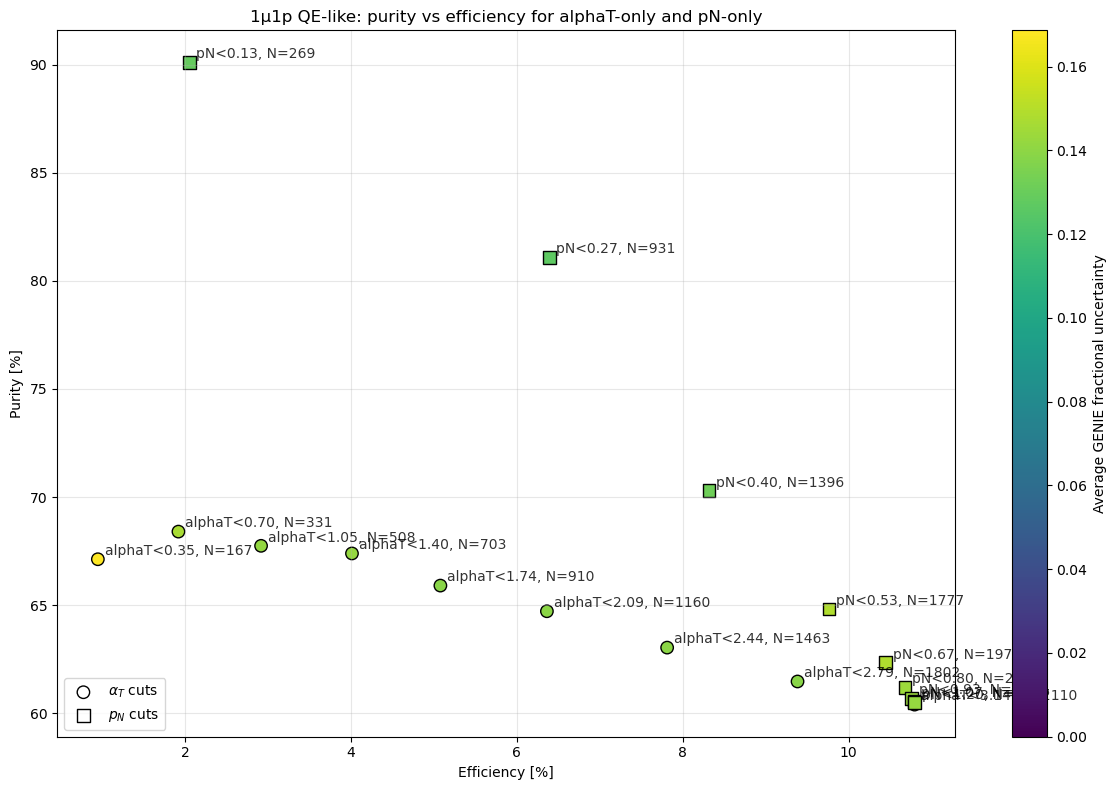

In [47]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))

# common color scale based on both scans
vmin = min(alphaT_scan_df["avg_GENIE_frac"].min(),
           pN_scan_df["avg_GENIE_frac"].min())
vmax = max(alphaT_scan_df["avg_GENIE_frac"].max(),
           pN_scan_df["avg_GENIE_frac"].max())


# alphaT series (circles)
sc_alphaT = ax.scatter(
    alphaT_scan_df["eff_%"],
    alphaT_scan_df["pur_%"],
    c=alphaT_scan_df["avg_GENIE_frac"],
    s=80,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    edgecolors="k",
    marker="o",
    label=r"$\alpha_T$ cuts"
)

for _, row in alphaT_scan_df.iterrows():
    label = fr"alphaT<{row['alphaT_max']:.2f}, N={row['N_sel_all']:.0f}"
    ax.annotate(
        label,
        (row["eff_%"], row["pur_%"]),
        textcoords="offset points",
        xytext=(5, 3),
        fontsize=10,
        alpha=0.8
    )

# pN series (squares)
sc_pN = ax.scatter(
    pN_scan_df["eff_%"],
    pN_scan_df["pur_%"],
    c=pN_scan_df["avg_GENIE_frac"],
    s=80,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    edgecolors="k",
    marker="s",
    label=r"$p_N$ cuts"
)

for _, row in pN_scan_df.iterrows():
    label = fr"pN<{row['pN_max']:.2f}, N={row['N_sel_all']:.0f}"
    ax.annotate(
        label,
        (row["eff_%"], row["pur_%"]),
        textcoords="offset points",
        xytext=(5, 3),
        fontsize=10,
        alpha=0.8
    )

# Colorbar (GENIE error)
cb = plt.colorbar(sc_alphaT)
cb.set_label("Average GENIE fractional uncertainty")

ax.set_xlabel("Efficiency [%]")
ax.set_ylabel("Purity [%]")
ax.set_title("1μ1p QE-like: purity vs efficiency for alphaT-only and pN-only")
#ax.set_xlim(8,11)

ax.grid(alpha=0.3)
ax.legend(loc="lower left")

plt.tight_layout()
plt.show()


## pN and phiT

In [48]:
import numpy as np
import pandas as pd
from microfit import histogram as hist

# ---------- helper----------
def fractional_error_from_cov(cov, central):
    central = np.asarray(central)
    diag = np.diag(cov)
    frac = np.zeros_like(central, dtype=float)
    mask = central > 0
    frac[mask] = np.sqrt(diag[mask]) / central[mask]
    return frac


# ---------- selections ----------
preselection = "sel_CCNp0pi"
selection    = "sel_CC1p0pi"

pre_q  = sel.preselection_categories[preselection]["query"]
sel_q  = sel.selection_categories[selection]["query"]
base_reco_q = f"({pre_q}) and ({sel_q})"

def wsum(df):
    return df["weights"].sum()

truth_label = "mc_is_cc1p0pi_signal"
truth_q     = truth_defs[truth_label]

N_tot     = wsum(mc)
sig_all   = mc.query(truth_q, engine="python")
N_sig_all = wsum(sig_all)

print(f"Total MC (all): {N_tot:.3f}")
print(f"Total {truth_label} truth events: {N_sig_all:.3f}")


# ---------- ECal binning for systematics ----------
edges = np.linspace(0.0, 2.0, 24)
Ecal_min, Ecal_max = 0.2, 1.5
bin_mask = (edges[:-1] >= Ecal_min) & (edges[1:] <= Ecal_max)

# Make sure ECal_all exists
for k, df in rundata.items():
    if df is None:
        continue
    if "ECal_all" not in df.columns:
        df["ECal_all"] = df["Ecal"]


# ====================================================
#  alphaT-only scan
# ====================================================
phiT_max_values = np.linspace(0.0, 3.14, 10)
phiT_scan_rows = []

for phiT_max in phiT_max_values:

    col_name = f"ECal_phiT{phiT_max:.2f}".replace(".", "p")
    print(f"\n=== phiT scan: phiT < {phiT_max:.2f} (var = {col_name}) ===")

    # fill new ECal column: only alphaT cut,
    for k, df in rundata.items():
        if df is None:
            continue
        mask = (df["delta_phiT"] < phiT_max)
        df[col_name] = np.nan
        df.loc[mask, col_name] = df.loc[mask, "ECal_all"]

    binning = hist.Binning(
        variable=col_name,
        bin_edges=edges,
        label=col_name,
        variable_tex=fr"ECal ($alpha_T<{phiT_max:.2f}$)",
    )

    run_hist_gen = hist.RunHistGenerator(
        rundata_stub,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        detvar_data=None,
        uncertainty_defaults=None,
    )

    total_prediction_stat = run_hist_gen.get_total_prediction(
        include_multisim_errors=False,
        add_precomputed_detsys=False,
    )
    bin_counts = total_prediction_stat.bin_counts
    stat_cov   = total_prediction_stat.covariance_matrix
    stat_frac  = fractional_error_from_cov(stat_cov, bin_counts)

    mc_hist_generator = run_hist_gen.mc_hist_generator

    genie_cov   = mc_hist_generator.calculate_multisim_uncertainties(
        multisim_weight_column="weightsGenie"
    )
    genie_frac  = fractional_error_from_cov(genie_cov, bin_counts)

    genie_uni_cov  = mc_hist_generator.calculate_unisim_uncertainties()
    genie_uni_frac = fractional_error_from_cov(genie_uni_cov, bin_counts)

    genie_tot_frac = np.sqrt(genie_frac**2 + genie_uni_frac**2)
    total_frac     = np.sqrt(stat_frac**2 + genie_tot_frac**2)

    avg_genie_frac = np.mean(genie_tot_frac[bin_mask])
    avg_total_frac = np.mean(total_frac[bin_mask])

    reco_q = f"({base_reco_q}) and (delta_phiT < {phiT_max})"

    sel_all = mc.query(reco_q, engine="python")
    sel_sig = mc.query(f"{truth_q} and ({reco_q})", engine="python")

    N_sel_all = wsum(sel_all)
    N_sel_sig = wsum(sel_sig)

    eff  = N_sel_sig / N_sig_all if N_sig_all > 0 else np.nan
    pur  = N_sel_sig / N_sel_all if N_sel_all > 0 else np.nan
    rate = N_sel_all / N_tot      if N_tot    > 0 else np.nan

    S = N_sel_sig
    B = max(N_sel_all - N_sel_sig, 0.0)
    T = S + B
    if T > 0:
        sigma_tot = np.sqrt(T + (avg_total_frac * T)**2)
        FOM = S / sigma_tot if sigma_tot > 0 else np.nan
    else:
        FOM = np.nan

    phiT_scan_rows.append({
        "phiT_max": phiT_max,
        "N_sel_all": N_sel_all,
        "N_sel_sig": N_sel_sig,
        "eff_%": eff * 100.0,
        "pur_%": pur * 100.0,
        "rate_%": rate * 100.0,
        "avg_GENIE_frac": avg_genie_frac,
        "avg_total_frac": avg_total_frac,
        "FOM": FOM,
    })

phiT_scan_df = pd.DataFrame(phiT_scan_rows)


Total MC (all): 150147.136
Total mc_is_cc1p0pi_signal truth events: 11802.345

=== phiT scan: phiT < 0.00 (var = ECal_phiT0p00) ===

=== phiT scan: phiT < 0.35 (var = ECal_phiT0p35) ===

=== phiT scan: phiT < 0.70 (var = ECal_phiT0p70) ===

=== phiT scan: phiT < 1.05 (var = ECal_phiT1p05) ===

=== phiT scan: phiT < 1.40 (var = ECal_phiT1p40) ===

=== phiT scan: phiT < 1.74 (var = ECal_phiT1p74) ===

=== phiT scan: phiT < 2.09 (var = ECal_phiT2p09) ===

=== phiT scan: phiT < 2.44 (var = ECal_phiT2p44) ===

=== phiT scan: phiT < 2.79 (var = ECal_phiT2p79) ===

=== phiT scan: phiT < 3.14 (var = ECal_phiT3p14) ===


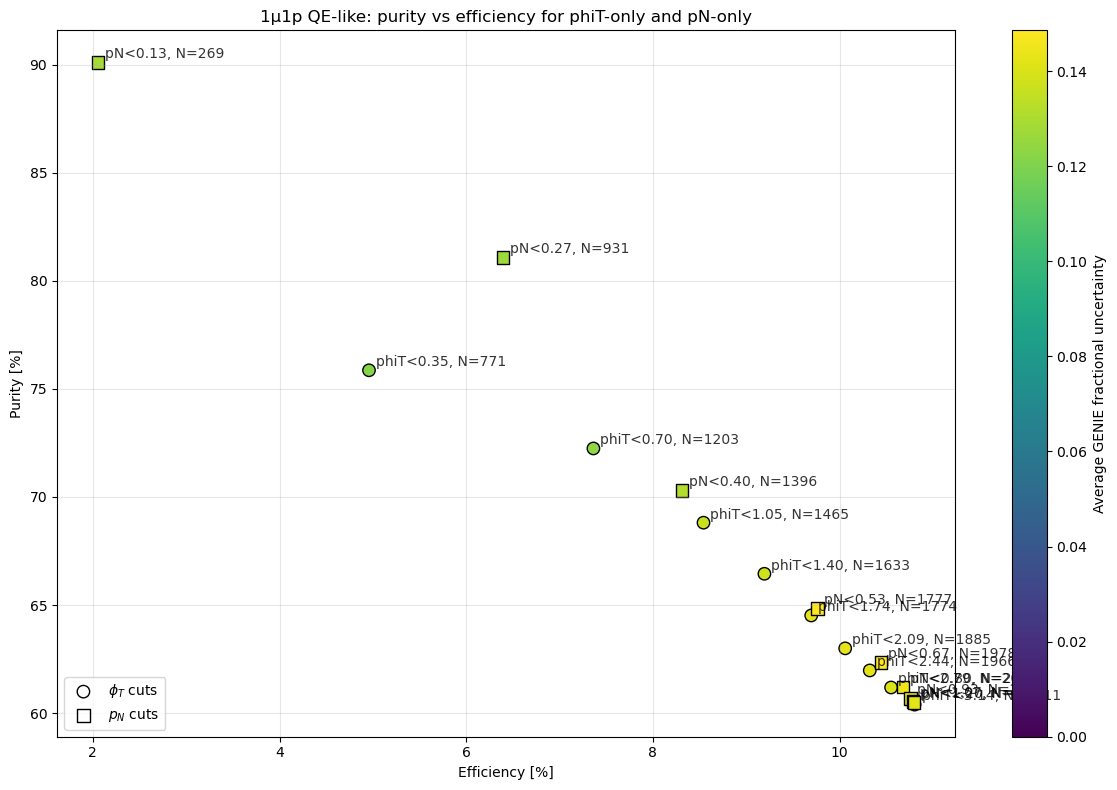

In [49]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))

# common color scale based on both scans
vmin = min(phiT_scan_df["avg_GENIE_frac"].min(),
           pN_scan_df["avg_GENIE_frac"].min())
vmax = max(phiT_scan_df["avg_GENIE_frac"].max(),
           pN_scan_df["avg_GENIE_frac"].max())


# alphaT series (circles)
sc_phiT = ax.scatter(
    phiT_scan_df["eff_%"],
    phiT_scan_df["pur_%"],
    c=phiT_scan_df["avg_GENIE_frac"],
    s=80,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    edgecolors="k",
    marker="o",
    label=r"$\phi_T$ cuts"
)

for _, row in phiT_scan_df.iterrows():
    label = fr"phiT<{row['phiT_max']:.2f}, N={row['N_sel_all']:.0f}"
    ax.annotate(
        label,
        (row["eff_%"], row["pur_%"]),
        textcoords="offset points",
        xytext=(5, 3),
        fontsize=10,
        alpha=0.8
    )

# pN series (squares)
sc_pN = ax.scatter(
    pN_scan_df["eff_%"],
    pN_scan_df["pur_%"],
    c=pN_scan_df["avg_GENIE_frac"],
    s=80,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    edgecolors="k",
    marker="s",
    label=r"$p_N$ cuts"
)

for _, row in pN_scan_df.iterrows():
    label = fr"pN<{row['pN_max']:.2f}, N={row['N_sel_all']:.0f}"
    ax.annotate(
        label,
        (row["eff_%"], row["pur_%"]),
        textcoords="offset points",
        xytext=(5, 3),
        fontsize=10,
        alpha=0.8
    )

# Colorbar (GENIE error)
cb = plt.colorbar(sc_phiT)
cb.set_label("Average GENIE fractional uncertainty")

ax.set_xlabel("Efficiency [%]")
ax.set_ylabel("Purity [%]")
ax.set_title("1μ1p QE-like: purity vs efficiency for phiT-only and pN-only")
#ax.set_xlim(8,11)

ax.grid(alpha=0.3)
ax.legend(loc="lower left")

plt.tight_layout()
plt.show()


##  ASIMOZ FOM

In [43]:
import numpy as np
import pandas as pd
from microfit import histogram as hist

# ----------------------------------------------------
# 0. Helper: fractional error from covariance
# ----------------------------------------------------
def fractional_error_from_cov(cov, central):
    """
    cov: (nbins, nbins) covariance matrix
    central: (nbins,) central bin contents (same normalization as cov)
    returns: (nbins,) fractional uncertainties (sigma / central)
    """
    central = np.asarray(central)
    diag = np.diag(cov)
    frac = np.zeros_like(central, dtype=float)
    mask = central > 0
    frac[mask] = np.sqrt(diag[mask]) / central[mask]
    return frac


# ----------------------------------------------------
# 0b. Cowan Asimov significance (discovery, with bkg syst)
#     EPJ C 71 (2011) Eq. (71)
# ----------------------------------------------------
def Z_cowan(s, b, sigma_b):
    """
    Asimov discovery significance with Gaussian background uncertainty.

    s       : expected signal yield
    b       : expected background yield
    sigma_b : absolute background uncertainty (systematic, NOT stat)
    """
    s = float(s)
    b = float(b)
    sigma_b = float(sigma_b)

    # Degenerate cases
    if s <= 0 or b <= 0:
        return 0.0
    if sigma_b <= 0:
        # No syst -> usual Poisson S/sqrt(B)
        return s / np.sqrt(b)

    # Cowan+ 2011, Eq. (71)
    term1 = (s + b) * np.log((s + b) * (b + sigma_b**2) /
                             (b**2 + (s + b) * sigma_b**2))
    term2 = (b**2 / sigma_b**2) * np.log(
        1.0 + (sigma_b**2 * s) / (b * (b + sigma_b**2))
    )
    Z2 = 2.0 * (term1 - term2)
    return np.sqrt(Z2) if Z2 > 0 else 0.0


# # ----------------------------------------------------
# # 1. Basic definitions
# # ----------------------------------------------------
# preselection = "sel_CCNp0pi"
# selection    = "sel_CC1p0pi"

# pre_q  = sel.preselection_categories[preselection]["query"]
# sel_q  = sel.selection_categories[selection]["query"]
# base_reco_q = f"({pre_q}) and ({sel_q})"

# def wsum(df):
#     return df["weights"].sum()

# truth_label = "mc_is_cc1p0pi_signal"      # QE-like truth you care about
# truth_q     = truth_defs[truth_label]

# N_tot     = wsum(mc)
# sig_all   = mc.query(truth_q, engine="python")
# N_sig_all = wsum(sig_all)

# print(f"Total MC (all): {N_tot:.3f}")
# print(f"Total {truth_label} truth events: {N_sig_all:.3f}")

# # ----------------------------------------------------
# # 2. Scan grids for ΔpT and pN
# # ----------------------------------------------------
# dpT_max_values = np.linspace(0, 1.2, 10)   # GeV
# pN_max_values  = np.linspace(0, 1.2, 10)   # GeV

# # ECal binning & region where you care about GENIE error
# edges = np.linspace(0.0, 2.0, 24)
# Ecal_min, Ecal_max = 0.2, 1.5
# bin_mask = (edges[:-1] >= Ecal_min) & (edges[1:] <= Ecal_max)

# # Make sure ECal_all exists in rundata
# for k, df in rundata.items():
#     if df is None:
#         continue
#     if "ECal_all" not in df.columns:
#         # if your column is named differently (e.g. "Ecal"), change here
#         df["ECal_all"] = df["Ecal"]

# scan_rows = []

# # ----------------------------------------------------
# # 3. Main scan loop
# # ----------------------------------------------------
# for dpT_max in dpT_max_values:
#     for pN_max in pN_max_values:

#         # 3a. Define a new Ecal variable name for this cut combo
#         col_name = f"ECal_dpT{dpT_max:.2f}_pN{pN_max:.2f}".replace(".", "p")
#         print(f"\n=== Scanning ΔpT < {dpT_max:.2f}, pN < {pN_max:.2f} "
#               f"(var = {col_name}) ===")

#         # 3b. Fill this column in rundata:
#         #      - = NaN outside TKI cuts
#         #      - = ECal_all inside TKI cuts
#         for k, df in rundata.items():
#             if df is None:
#                 continue
#             mask = (df["delta_pT"] < dpT_max) & (df["pn"] < pN_max)
#             df[col_name] = np.nan
#             df.loc[mask, col_name] = df.loc[mask, "ECal_all"]

#         # 3c. Build binning and RunHistGenerator for this variable
#         binning = hist.Binning(
#             variable=col_name,
#             bin_edges=edges,
#             label=col_name,
#             variable_tex=fr"ECal ($\Delta p_T<{dpT_max}$, p_N<{pN_max}$)",
#         )

#         run_hist_gen = hist.RunHistGenerator(
#             rundata_stub,
#             binning.copy(),
#             data_pot=data_pot,
#             selection=selection,
#             preselection=preselection,
#             detvar_data=None,
#             uncertainty_defaults=None,
#         )

#         # 3d. Stat-only prediction
#         total_prediction_stat = run_hist_gen.get_total_prediction(
#             include_multisim_errors=False,
#             add_precomputed_detsys=False,
#         )
#         bin_counts = total_prediction_stat.bin_counts
#         stat_cov   = total_prediction_stat.covariance_matrix
#         stat_error_frac = fractional_error_from_cov(stat_cov, bin_counts)

#         # 3e. GENIE multisim + unisim (MC only)
#         mc_hist_generator = run_hist_gen.mc_hist_generator

#         genie_cov = mc_hist_generator.calculate_multisim_uncertainties(
#             multisim_weight_column="weightsGenie"
#         )
#         genie_error_frac = fractional_error_from_cov(genie_cov, bin_counts)

#         genie_unisim_cov = mc_hist_generator.calculate_unisim_uncertainties()
#         genie_unisim_error_frac = fractional_error_from_cov(genie_unisim_cov, bin_counts)

#         genie_total_frac = np.sqrt(genie_error_frac**2 + genie_unisim_error_frac**2)
#         total_frac       = np.sqrt(stat_error_frac**2 + genie_total_frac**2)

#         # 3f. Average fractional errors in the Ecal region of interest
#         avg_genie_frac = np.mean(genie_total_frac[bin_mask])
#         avg_total_frac = np.mean(total_frac[bin_mask])

#         # ------------------------------------------------
#         # 3g. Efficiency & purity for this TKI cut combo
#         # ------------------------------------------------
#         reco_q = f"({base_reco_q}) and (delta_pT < {dpT_max}) and (pn < {pN_max})"

#         sel_all = mc.query(reco_q, engine="python")
#         sel_sig = mc.query(f"{truth_q} and ({reco_q})", engine="python")

#         N_sel_all = wsum(sel_all)
#         N_sel_sig = wsum(sel_sig)

#         eff  = N_sel_sig / N_sig_all if N_sig_all > 0 else np.nan
#         pur  = N_sel_sig / N_sel_all if N_sel_all > 0 else np.nan
#         rate = N_sel_all / N_tot      if N_tot    > 0 else np.nan

#         # ------------------------------------------------
#         # Asimov significance FOM (Cowan)
#         #     σ_b = avg_GENIE_frac × B
#         # ------------------------------------------------
#         S = N_sel_sig
#         B = max(N_sel_all - N_sel_sig, 0.0)
#         sigma_b = avg_genie_frac * B
#         Z_asimov = Z_cowan(S, B, sigma_b)

#         scan_rows.append({
#             "dpT_max": dpT_max,
#             "pN_max": pN_max,
#             "N_sel_all": N_sel_all,
#             "N_sel_sig": N_sel_sig,
#             "S": S,
#             "B": B,
#             "sigma_b": sigma_b,
#             "eff_%": eff * 100.0,
#             "pur_%": pur * 100.0,
#             "rate_%": rate * 100.0,
#             "avg_GENIE_frac": avg_genie_frac,
#             "avg_total_frac": avg_total_frac,
#             "Z_asimov": Z_asimov,
#         })

# # ----------------------------------------------------
# # ----------------------------------------------------
# scan_df2 = pd.DataFrame(scan_rows)

# print("\nScan results sorted by Asimov Z (best first):")
# print(
#     scan_df2.sort_values("Z_asimov", ascending=False)
# )

# print("\nCompact view (eff, pur, GENIE, Z_asimov):")
# print(
#     scan_df2[["dpT_max", "pN_max", "eff_%", "pur_%",
#              "avg_GENIE_frac", "Z_asimov"]]
#     .sort_values("Z_asimov", ascending=False)
# )


### Find best value using efficiency

In [44]:
eff_min = 5.5  

candidates = scan_df2[scan_df2["eff_%"] >= eff_min]
best_idx   = candidates["Z_asimov"].idxmax()
best_row   = candidates.loc[best_idx]
print(best_row)


NameError: name 'scan_df2' is not defined

### PURITY X EFFICIENCY  --  FOR ALL TKI/GKI 


In [117]:
# ----------------------------------------------------
# Baseline: no TKI cut (just base CC1p0pi selection)
# ----------------------------------------------------

# Make sure ECal_all exists in rundata
for k, df in rundata.items():
    if df is None:
        continue
    if "ECal_all" not in df.columns:
        df["ECal_all"] = df["Ecal"]   # or whatever your original column is

# Binning for baseline ECal
binning_base = hist.Binning(
    variable="ECal_all",
    bin_edges=edges,
    label="ECal_all",
    variable_tex=r"ECal (no TKI cuts)",
)

run_hist_base = hist.RunHistGenerator(
    rundata_stub,
    binning_base.copy(),
    data_pot=data_pot,
    selection=selection,
    preselection=preselection,
    detvar_data=None,
    uncertainty_defaults=None,
)

# Stat-only prediction
base_pred = run_hist_base.get_total_prediction(
    include_multisim_errors=False,
    add_precomputed_detsys=False,
)
base_counts = base_pred.bin_counts
base_stat_cov = base_pred.covariance_matrix
base_stat_frac = fractional_error_from_cov(base_stat_cov, base_counts)

# GENIE multisim (+ optional unisim, same choice as below)
base_mc_gen = run_hist_base.mc_hist_generator

base_genie_cov = base_mc_gen.calculate_multisim_uncertainties(
    multisim_weight_column="weightsGenie"
)
base_genie_frac = fractional_error_from_cov(base_genie_cov, base_counts)

base_genie_unisim_cov = base_mc_gen.calculate_unisim_uncertainties()
base_genie_unisim_frac = fractional_error_from_cov(base_genie_unisim_cov, base_counts)

# Use the same definition as in your scan (right now only multisim):
base_genie_total_frac = base_genie_frac  # or np.sqrt(base_genie_frac**2 + base_genie_unisim_frac**2)
base_total_frac       = np.sqrt(base_stat_frac**2 + base_genie_total_frac**2)

# Average GENIE frac in the same ECal ROI
avg_genie_frac_base = np.mean(base_genie_total_frac[bin_mask])

print(f"Baseline GENIE fractional uncertainty (no TKI cuts) = {avg_genie_frac_base:.4f}")

# Also compute baseline efficiency/purity & EP for reference
reco_q_base = base_reco_q  

sel_all_base = mc.query(reco_q_base, engine="python")
sel_sig_base = mc.query(f"{truth_q} and ({reco_q_base})", engine="python")

N_sel_all_base = wsum(sel_all_base)
N_sel_sig_base = wsum(sel_sig_base)

eff_base = N_sel_sig_base / N_sig_all if N_sig_all > 0 else np.nan
pur_base = N_sel_sig_base / N_sel_all_base if N_sel_all_base > 0 else np.nan
EP_base  = eff_base * pur_base

print(f"Baseline EP = {EP_base:.4f}, eff={eff_base*100:.2f}%, pur={pur_base*100:.2f}%")


Baseline GENIE fractional uncertainty (no TKI cuts) = 0.1236
Baseline EP = 0.0653, eff=10.80%, pur=60.39%


In [67]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# TKI scans: pN, pT, alphaT, phiT
# ============================================

# Define which TKI variables to scan and their cut grids
tki_specs = [
    {
        "name": "pn",
        "tex":  r"$p_N$",
        "cuts": np.linspace(0.0, 1.2, 10),   # GeV
    },
    {
        "name": "delta_pT",
        "tex":  r"$\delta p_T$",
        "cuts": np.linspace(0.0, 1.2, 10),   # GeV
    },
    {
        "name": "delta_alphaT",
        "tex":  r"$\delta \alpha_T$",
        "cuts": np.linspace(0.0, 3.14, 10), # rad; 
    },
    {
        "name": "delta_phiT",
        "tex":  r"$\delta \phi_T$",
        "cuts": np.linspace(0.0, 3.14, 10), # rad; 
    },
]

tki_rows = []

for spec in tki_specs:
    var_col = spec["name"]     # df column, e.g. "pn"
    var_tex = spec["tex"]      # label for plot/legend
    cut_values = spec["cuts"]

    for cut_max in cut_values:

        #Define a new ECal variable name for this (var, cut) combo
        col_name = f"ECal_{var_col}_{cut_max:.2f}".replace(".", "p")
        #print(f"\n=== Scanning {var_col} < {cut_max:.3f} (var = {col_name}) ===")

        # Fill this column in rundata:
        #     - = NaN outside TKI cut
        #     - = ECal_all inside TKI cut
        for k, df in rundata.items():
            if df is None:
                continue
            if var_col not in df.columns:
                raise KeyError(f"{var_col} not found in df[{k}].columns")
            mask = df[var_col] < cut_max
            df[col_name] = np.nan
            df.loc[mask, col_name] = df.loc[mask, "ECal_all"]

        # Build binning and RunHistGenerator for this variable
        binning = hist.Binning(
            variable=col_name,
            bin_edges=edges,
            label=col_name,
            variable_tex=fr"ECal ({var_tex}<{cut_max:.2f})",
        )

        run_hist_gen = hist.RunHistGenerator(
            rundata_stub,
            binning.copy(),
            data_pot=data_pot,
            selection=selection,
            preselection=preselection,
            detvar_data=None,
            uncertainty_defaults=None,
        )

        # Stat-only prediction
        total_prediction_stat = run_hist_gen.get_total_prediction(
            include_multisim_errors=False,
            add_precomputed_detsys=False,
        )
        bin_counts = total_prediction_stat.bin_counts
        stat_cov   = total_prediction_stat.covariance_matrix
        stat_error_frac = fractional_error_from_cov(stat_cov, bin_counts)

        # GENIE multisim + unisim 
        mc_hist_generator = run_hist_gen.mc_hist_generator

        genie_cov = mc_hist_generator.calculate_multisim_uncertainties(
            multisim_weight_column="weightsGenie"
        )
        genie_error_frac = fractional_error_from_cov(genie_cov, bin_counts)

        genie_unisim_cov = mc_hist_generator.calculate_unisim_uncertainties()
        genie_unisim_error_frac = fractional_error_from_cov(genie_unisim_cov, bin_counts)

        genie_total_frac = genie_error_frac#np.sqrt(genie_error_frac**2 + genie_unisim_error_frac**2)
        total_frac       = np.sqrt(stat_error_frac**2 + genie_total_frac**2)

        # Average fractional errors in the Ecal region of interest
        avg_genie_frac = np.mean(genie_total_frac[bin_mask])
        avg_total_frac = np.mean(total_frac[bin_mask])

        # Efficiency & purity for this TKI cut
        reco_q = f"({base_reco_q}) and ({var_col} < {cut_max})"

        sel_all = mc.query(reco_q, engine="python")
        sel_sig = mc.query(f"{truth_q} and ({reco_q})", engine="python")

        N_sel_all = wsum(sel_all)
        N_sel_sig = wsum(sel_sig)

        eff  = N_sel_sig / N_sig_all if N_sig_all > 0 else np.nan
        pur  = N_sel_sig / N_sel_all if N_sel_all > 0 else np.nan
        rate = N_sel_all / N_tot      if N_tot    > 0 else np.nan

        # Asimov Z (not used for this plot, but stored for later)
        S = N_sel_sig
        B = max(N_sel_all - N_sel_sig, 0.0)
        sigma_b = avg_genie_frac * B
        Z_asimov = Z_cowan(S, B, sigma_b)

        tki_rows.append({
            "var_col": var_col,
            "var_tex": var_tex,
            "cut_max": cut_max,
            "N_sel_all": N_sel_all,
            "N_sel_sig": N_sel_sig,
            "S": S,
            "B": B,
            "sigma_b": sigma_b,
            "eff_%": eff * 100.0,
            "pur_%": pur * 100.0,
            "rate_%": rate * 100.0,
            "avg_GENIE_frac": avg_genie_frac,
            "avg_total_frac": avg_total_frac,
            "Z_asimov": Z_asimov,
        })

tki_df = pd.DataFrame(tki_rows)

# Compute epsilon × purity
tki_df["eff_frac"] = tki_df["eff_%"] / 100.0
tki_df["pur_frac"] = tki_df["pur_%"] / 100.0
tki_df["EP"]       = tki_df["eff_frac"] * tki_df["pur_frac"]

# Drop (no events -> NaNs)
plot_df = tki_df.dropna(subset=["EP", "avg_GENIE_frac"]).copy()


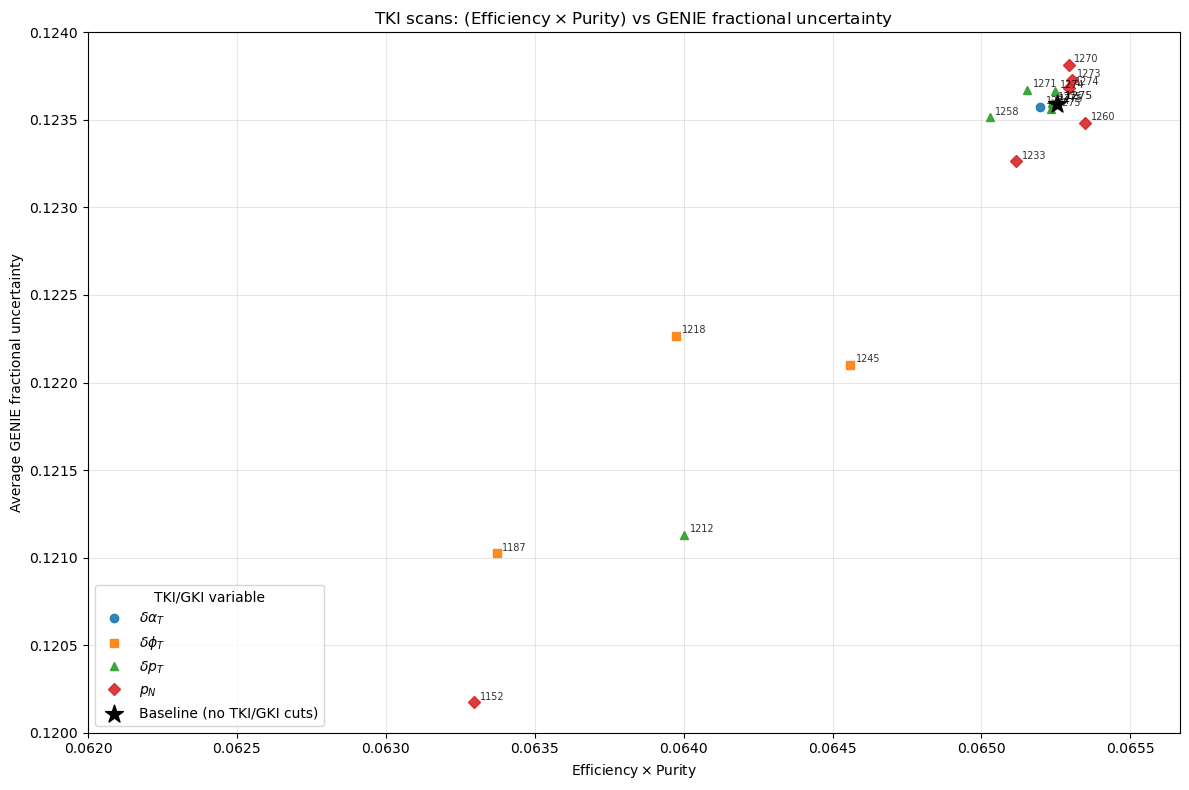

In [146]:
# ===========================================
# Plot: EP vs GENIE frac for all TKI vars
# ===========================================
fig, ax = plt.subplots(figsize=(12, 8))

markers = ["o", "s", "^", "D"]  # one per TKI variable

for (var_tex, sub), marker in zip(plot_df.groupby("var_tex"), markers):
    sub = sub.sort_values("avg_GENIE_frac")

    ax.plot(
        sub["EP"],
        sub["avg_GENIE_frac"],
        marker=marker,
        linestyle="none",   # no connecting line, just points
        markersize=6,
        alpha=0.9,
        label=var_tex,
    )
    

        # annotate each point with number of signal events 
    for _, row in sub.iterrows():
        ax.annotate(
            f"{row['N_sel_sig']:.0f}",                   # text = integer events 
            (row["EP"], row["avg_GENIE_frac"]),         # at the point 
            textcoords="offset points",
            xytext=(4, 2),                              # small offset
            fontsize=7,
            alpha=0.8,
        )

ax.scatter(
    EP_base,
    avg_genie_frac_base,
    marker="*",
    s=180,
    color="black",
    edgecolors="k",
    zorder=5,
    label=rf"Baseline (no TKI/GKI cuts)", 
)

# Label that point with signal yield too
ax.annotate(
    f"{N_sel_sig_base:.0f}",
    (EP_base, avg_genie_frac_base),
    textcoords="offset points",
    xytext=(6, 4),
    fontsize=8,
    alpha=0.9,
)
        

        
ax.set_ylabel("Average GENIE fractional uncertainty")
ax.set_xlabel(r"$\mathrm{Efficiency} \times \mathrm{Purity}$")
ax.set_title(
    r"TKI scans: $(\mathrm{Efficiency} \times \mathrm{Purity})$ "
    r"vs GENIE fractional uncertainty"
)
ax.grid(alpha=0.3)
ax.legend(title="TKI/GKI variable")
ax.set_ylim(0.120, 0.124)
ax.set_xlim(0.062, 0.06566668)

plt.tight_layout()
plt.show()


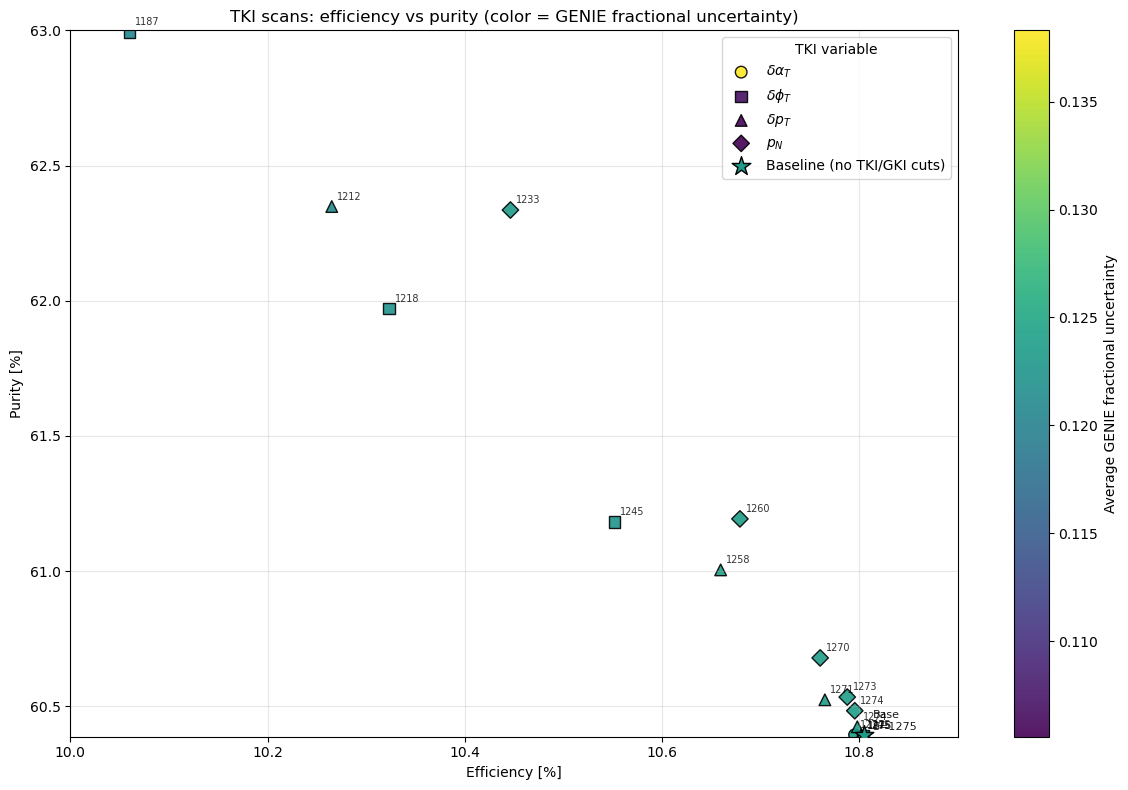

In [141]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 8))

# One global color scale for all variables
vmin = plot_df["avg_GENIE_frac"].min()
vmax = plot_df["avg_GENIE_frac"].max()

# Different marker per TKI variable for the legend
markers = ["o", "s", "^", "D"]  # circle, square, triangle, diamond

for (var_tex, sub), marker in zip(plot_df.groupby("var_tex"), markers):
    sub = sub.sort_values("eff_%")  # purely for nicer point ordering

    sc = ax.scatter(
        sub["eff_%"],
        sub["pur_%"],
        c=sub["avg_GENIE_frac"],
        vmin=vmin,
        vmax=vmax,
        cmap="viridis",
        marker=marker,
        edgecolors="k",
        s=70,
        alpha=0.9,
        label=var_tex,
    )

   
    for _, row in sub.iterrows():
        ax.annotate(
            f"{row['N_sel_sig']:.0f}",         # POT-weighted signal events
            (row["eff_%"], row["pur_%"]),     # at the point
            textcoords="offset points",
            xytext=(4, dy),                   # shift text slightly
            fontsize=7,
            alpha=0.8,
        )
        
# BASELINE (no TKI cuts)        
ax.scatter(
    eff_base * 100.0,
    pur_base * 100.0,
    marker="*",
    s=200,
    c=[avg_genie_frac_base],   # use baseline GENIE frac for color
    vmin=vmin,
    vmax=vmax,
    cmap="viridis",
    edgecolors="k",
    zorder=5,
    label="Baseline (no TKI/GKI cuts)",
)

# label the baseline point
ax.annotate(
    f"Base\nS={N_sel_sig_base:.0f}",
    (eff_base * 100.0, pur_base * 100.0),
    textcoords="offset points",
    xytext=(6, 4),
    fontsize=8,
    alpha=0.9,
)


# Colorbar for GENIE fractional uncertainty
cb = plt.colorbar(sc)
cb.set_label("Average GENIE fractional uncertainty")

ax.set_xlabel("Efficiency [%]")
ax.set_ylabel("Purity [%]")
ax.set_title(r"TKI scans: efficiency vs purity (color = GENIE fractional uncertainty)")

ax.grid(alpha=0.3)
ax.legend(title="TKI variable")

plt.ylim(60.388,63.00)
plt.xlim(10.0,10.9)

plt.tight_layout()
plt.show()


/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


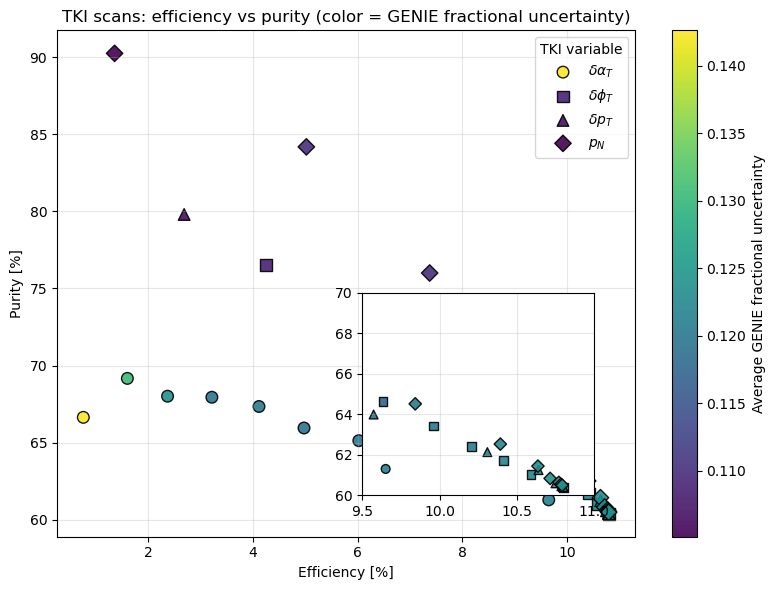

In [140]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(8, 6))

# One global color scale for all variables
vmin = plot_df["avg_GENIE_frac"].min()
vmax = plot_df["avg_GENIE_frac"].max()

# Different marker per TKI variable for the legend
markers = ["o", "s", "^", "D"]  

for (var_tex, sub), marker in zip(plot_df.groupby("var_tex"), markers):
    sub = sub.sort_values("eff_%")  # purely for nicer point ordering

    sc = ax.scatter(
        sub["eff_%"],
        sub["pur_%"],
        c=sub["avg_GENIE_frac"],
        vmin=vmin,
        vmax=vmax,
        cmap="viridis",
        marker=marker,
        edgecolors="k",
        s=70,
        alpha=0.9,
        label=var_tex,
    )

# Colorbar for GENIE fractional uncertainty
cb = plt.colorbar(sc)
cb.set_label("Average GENIE fractional uncertainty")

ax.set_xlabel("Efficiency [%]")
ax.set_ylabel("Purity [%]")
ax.set_title(r"TKI scans: efficiency vs purity (color = GENIE fractional uncertainty)")

ax.grid(alpha=0.3)
ax.legend(title="TKI variable")

# ===========================================
# Inset zoom: ONLY x in [8.5, 10.5], same y
# ===========================================
zoom_eff_min = 9.5
zoom_eff_max = 11.0

zoom_pur_min = 60
zoom_pur_max = 70

axins = inset_axes(
    ax,
    width="40%",    # % of parent axis
    height="40%",
    loc="lower right",
    borderpad=3,
)

for (var_tex, sub), marker in zip(plot_df.groupby("var_tex"), markers):
    sub = sub.sort_values("eff_%")
    axins.scatter(
        sub["eff_%"],
        sub["pur_%"],
        c=sub["avg_GENIE_frac"],
        vmin=vmin,
        vmax=vmax,
        cmap="viridis",
        marker=marker,
        edgecolors="k",
        s=40,
        alpha=0.9,
    )

# Zoom only x; copy y-limits from main axis
axins.set_xlim(zoom_eff_min, zoom_eff_max)
axins.set_ylim(zoom_pur_min, zoom_pur_max)
#axins.set_ylim(ax.get_ylim())
axins.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [138]:
print(max(sel_mc_1mu1p["pn"]))

2.657467426393314


## SELECTION STATES 0pi1p

In [181]:
def _b(s: pd.Series) -> pd.Series:
    return s.fillna(False).astype(bool)

def compute_eff_pur_df(
    df: pd.DataFrame,
    truth_col: str = "mc_is_cc1p0pi_signal",
    weight_col: str = "weights",
) -> pd.DataFrame:

    stages = [
        ("no cuts",
         lambda d: pd.Series(True, index=d.index)),

        ("in FV",
         lambda d: _b(d["sel_reco_vertex_in_FV"])),

        ("starts contained",
         lambda d: _b(d["sel_reco_vertex_in_FV"])
                   & _b(d["sel_pfp_starts_in_PCV"])),

        ("CCincl",
         lambda d: _b(d["sel_nu_mu_cc"])),

        ("#mu momentum limits",
         lambda d: _b(d["sel_nu_mu_cc"])
                   & _b(d["sel_muon_passed_mom_cuts"])),

        ("no showers",
         lambda d: _b(d["sel_nu_mu_cc"])
                   & _b(d["sel_muon_passed_mom_cuts"])
                   & _b(d["sel_no_reco_showers"])),

        ("#mu contained",
         lambda d: _b(d["sel_nu_mu_cc"])
                   & _b(d["sel_muon_passed_mom_cuts"])
                   & _b(d["sel_no_reco_showers"])
                   & _b(d["sel_muon_contained"])),

        ("#mu quality",
         lambda d: _b(d["sel_nu_mu_cc"])
                   & _b(d["sel_muon_passed_mom_cuts"])
                   & _b(d["sel_no_reco_showers"])
                   & _b(d["sel_muon_contained"])
                   & _b(d["sel_muon_quality_ok"])),

        ("has p candidate",
         lambda d: _b(d["sel_nu_mu_cc"])
                   & _b(d["sel_muon_passed_mom_cuts"])
                   & _b(d["sel_no_reco_showers"])
                   & _b(d["sel_muon_contained"])
                   & _b(d["sel_muon_quality_ok"])
                   & _b(d["sel_has_p_candidate"])),

        ("p contained",
         lambda d: _b(d["sel_nu_mu_cc"])
                   & _b(d["sel_muon_passed_mom_cuts"])
                   & _b(d["sel_no_reco_showers"])
                   & _b(d["sel_muon_contained"])
                   & _b(d["sel_muon_quality_ok"])
                   & _b(d["sel_has_p_candidate"])
                   & _b(d["sel_protons_contained"])),

        ("proton PID",
         lambda d: _b(d["sel_nu_mu_cc"])
                   & _b(d["sel_muon_passed_mom_cuts"])
                   & _b(d["sel_no_reco_showers"])
                   & _b(d["sel_muon_contained"])
                   & _b(d["sel_muon_quality_ok"])
                   & _b(d["sel_has_p_candidate"])
                   & _b(d["sel_protons_contained"])
                   & _b(d["sel_passed_proton_pid_cut"])),

#         # 0piNp selection
#         ("0piNp (sel_CCNp0pi)",
#          lambda d: _b(d["sel_CCNp0pi"])),

        # 0pi1p selection
        ("0pi1p (sel_CC1p0pi)",
         lambda d: _b(d["sel_CC1p0pi"])),
    ]

    is_sig = _b(df[truth_col])
    w = df[weight_col].astype(float)

    N_sig_total = w[is_sig].sum()

    rows = []
    for stage_name, mask_fn in stages:
        m = _b(mask_fn(df))
        N_all = w[m].sum()
        N_sig = w[m & is_sig].sum()
        N_bkg = N_all - N_sig

        eff = N_sig / N_sig_total if N_sig_total > 0 else np.nan
        pur = N_sig / N_all       if N_all       > 0 else np.nan

        rows.append({
            "stage": stage_name,
            "N_all": N_all,
            "N_sig": N_sig,
            "N_bkg": N_bkg,
            "efficiency": eff,
            "purity": pur,
            "eff_%": eff * 100.0,
            "pur_%": pur * 100.0,
        })

    return pd.DataFrame(rows)


In [184]:
cutflow_df = compute_eff_pur_df(mc)

print(cutflow_df[["stage", "N_sig", "N_bkg", "eff_%", "pur_%"]])


                  stage         N_sig          N_bkg       eff_%      pur_%
0               no cuts  11802.345073  138344.790953  100.000000   7.860520
1                 in FV   9297.570463   24817.551359   78.777314  27.253517
2      starts contained   8674.367995   22520.711033   73.496987  27.806847
3                CCincl   6005.469831    8872.616528   50.883700  40.364531
4   #mu momentum limits   5855.314403    8409.602272   49.611449  41.046958
5            no showers   5855.314403    8409.602272   49.611449  41.046958
6         #mu contained   2149.773919    3983.406713   18.214803  35.051534
7           #mu quality   1796.023981    2904.164090   15.217518  38.211747
8       has p candidate   1323.383083    1617.911008   11.212882  44.993226
9           p contained   1323.383083    1617.911008   11.212882  44.993226
10           proton PID   1323.383083    1617.911008   11.212882  44.993226
11  0pi1p (sel_CC1p0pi)   1275.208028     836.315805   10.804700  60.392784


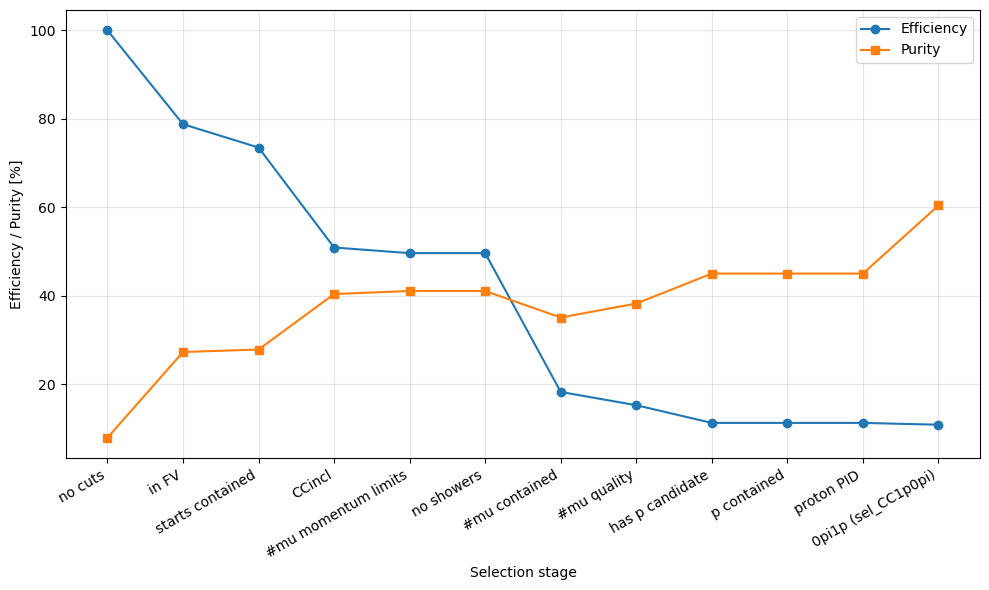

In [185]:
stages = cutflow_df["stage"].tolist()
x = np.arange(len(stages))

eff = cutflow_df["eff_%"].to_numpy()
pur = cutflow_df["pur_%"].to_numpy()

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(x, eff, marker="o", label="Efficiency", color="tab:blue")
ax1.plot(x, pur, marker="s", label="Purity",    color="tab:orange")

ax1.set_xticks(x)
ax1.set_xticklabels(stages, rotation=30, ha="right")
ax1.set_ylabel("Efficiency / Purity [%]")
ax1.set_xlabel("Selection stage")
ax1.grid(alpha=0.3)
ax1.legend()

plt.tight_layout()
plt.show()
